In [ ]:
# ============================================================================
# CELL 1 — setup, config, shared helpers
# ============================================================================
from pathlib import Path
import pickle, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200); pd.set_option("display.width", 240)

NOTEBOOK_DIR = Path.cwd()
PREFIX       = "COUPLED__"

LABEL_START  = pd.Timestamp("1989-01-31")
LABEL_END    = pd.Timestamp("2024-12-31")
DISPLAY_START= LABEL_START
ALLOC_END    = pd.Timestamp("2024-10-31")

MODEL_PANEL  = NOTEBOOK_DIR / "model_panel_start_1970_01_31.parquet"
BASE_PANEL   = NOTEBOOK_DIR / "base_panel_monthly_trunc_2024_11.parquet"
TEACHER_PKL  = NOTEBOOK_DIR / "teacher_run_full.pkl"

HEADLINE_COST = 0.0010
COST_GRID     = [0.0005, 0.0010, 0.0025]
MAX_GROSS, REBAL_FREQ, GRID_STEP = 1.0, 1, 0.05
GAMMA_MV, GAMMA_MINVAR, GAMMA_JM = 3.0, 20.0, 5.0
COV_HL, MV_MEAN_HL = 12.0, 60.0
TRAIN_M, VALID_M, BLOCK_M, TOP_K_MACRO = 132, 60, 6, 5
GAMMA_SWEEP = [0.25, 0.5, 1.0, 2.0, 3.0, 5.0]
TP_SWEEP    = [0.0, 0.0005, 0.001, 0.0025, 0.005, 0.0075, 0.01]
TP_SWEEP_FIXED_GAMMA = GAMMA_JM
GAMMA_SWEEP_FIXED_TP = 0.0025
RANDOM_STATE, EPS, ANN = 42, 1e-12, 12.0

LABEL_CLASSES = ["calm", "normal", "stressed"]
REGIME_INT    = {"calm": 0, "normal": 1, "stressed": 2}
REGIME_COLORS = {"calm": "#2e9e3f", "normal": "#1565c0", "stressed": "#d32f2f"}
LINE_COLORS   = {"calm": "#2e9e3f", "normal": "#1565c0", "stressed": "#d32f2f"}

plt.rcParams.update({"figure.dpi":110,"savefig.dpi":200,"savefig.bbox":"tight","font.size":12,
    "axes.titlesize":13,"axes.labelsize":12,"xtick.labelsize":10,"ytick.labelsize":10,
    "legend.fontsize":10,"axes.grid":True,"grid.alpha":0.3})

def ann_sr(x):
    x=np.asarray(pd.Series(x).dropna(),float)
    if len(x)<3: return np.nan
    s=x.std(ddof=0); return float(np.sqrt(ANN)*x.mean()/s) if s>1e-12 else np.nan
def ann_ret(x): return float(ANN*np.nanmean(np.asarray(pd.Series(x).dropna(),float)))
def ann_vol(x):
    x=np.asarray(pd.Series(x).dropna(),float); return float(np.sqrt(ANN)*x.std(ddof=0))
def max_dd(w):
    w=np.asarray(w,float); return float((w/np.maximum.accumulate(w)-1).min())
def cvar1(r):
    r=np.sort(np.asarray(pd.Series(r).dropna(),float)); k=max(1,int(np.ceil(0.01*len(r))))
    return float(r[:k].mean()) if len(r) else np.nan
def rle(s):
    s=list(s); out=[]
    if not s: return out
    c,n=s[0],1
    for v in s[1:]:
        if v==c: n+=1
        else: out.append((c,n)); c,n=v,1
    out.append((c,n)); return out
def avg_dur(s): r=rle(s); return float(np.mean([n for _,n in r])) if r else np.nan
def n_sw(s): s=list(s); return int(sum(1 for i in range(1,len(s)) if s[i]!=s[i-1]))

def regime_spans(dates, regimes):
    d=pd.DataFrame({"date":pd.to_datetime(dates),"r":list(regimes)}).dropna().reset_index(drop=True)
    if not len(d): return []
    out=[]; s=p=d.loc[0,"date"]; cur=d.loc[0,"r"]
    for i in range(1,len(d)):
        dt,r=d.loc[i,"date"],d.loc[i,"r"]
        if r!=cur: out.append((s,p,cur)); s=dt; cur=r
        p=dt
    out.append((s,p,cur)); return out
def shade(ax,dates,regimes,alpha=0.28):
    for s,e,r in regime_spans(dates,regimes):
        ax.axvspan(s,e+pd.offsets.MonthEnd(1),color=REGIME_COLORS.get(r,"white"),alpha=alpha,lw=0,zorder=0)
def regime_legend(): return [Patch(facecolor=REGIME_COLORS[c],alpha=0.6,label=c) for c in LABEL_CLASSES]
def yfmt_pct(ax): ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{x:.0%}"))
def year_axis(ax,base=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(base=base)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

def disp(df): return df[(df["date"]>=LABEL_START)&(df["date"]<=LABEL_END)].copy()
def win(df):  return df[(df["date"]>=LABEL_START)&(df["date"]<=LABEL_END)].copy()

def save_fig(fig,name):
    for ext in ("png","pdf"): fig.savefig(NOTEBOOK_DIR/f"{PREFIX}{name}.{ext}")
    print(f"[saved] {PREFIX}{name}.png / .pdf"); plt.show(); plt.close(fig)
def save_tbl(df,name,ff="%.4f"):
    df.to_csv(NOTEBOOK_DIR/f"{PREFIX}{name}.csv",index=False)
    with open(NOTEBOOK_DIR/f"{PREFIX}{name}.tex","w") as f: f.write(df.to_latex(index=False,float_format=ff))
    print(f"[saved] {PREFIX}{name}.csv / .tex"); display(df)

print("CELL 1 OK | headline cost =", int(HEADLINE_COST*1e4), "bps | gross cap =", MAX_GROSS,
      "| rebal =", REBAL_FREQ, "mo | LABEL WINDOW", LABEL_START.date(), "->", LABEL_END.date())

CELL 1 OK | headline cost = 10 bps | gross cap = 1.0 | rebal = 1 mo | LABEL WINDOW 1989-01-31 -> 2024-12-31


In [2]:
# ============================================================================
# CELL 2 — load pickle + returns, standardize objects
# ============================================================================
panel_raw = pd.read_parquet(MODEL_PANEL).copy()
panel_raw["date"]=pd.to_datetime(panel_raw["date"])
panel_raw=panel_raw.sort_values("date").reset_index(drop=True)
panel_raw=panel_raw.iloc[:, [0]+list(range(49,panel_raw.shape[1]))]
for c in panel_raw.columns:
    if c!="date": panel_raw[c]=pd.to_numeric(panel_raw[c],errors="coerce")

RET=panel_raw[["date","sprtrn_sp500","agg_ret","rf"]].copy()
RET["eqx"]=RET["sprtrn_sp500"]-RET["rf"]; RET["bdx"]=RET["agg_ret"]-RET["rf"]
RET=RET.dropna(subset=["eqx","bdx"]).reset_index(drop=True)

with open(TEACHER_PKL,"rb") as f: RUN=pickle.load(f)

LBL=RUN["selected_labels"].copy(); LBL["date"]=pd.to_datetime(LBL["date"])
LBL=LBL.sort_values("date").reset_index(drop=True)
if "w_t" in LBL.columns: LBL=LBL.rename(columns={"w_t":"kappa"})
LBL["regime_int"]=LBL["regime"].map(REGIME_INT)

MEMBER_ORDER=list(RUN["member_label_dfs"].keys()); MEM={}
for k in MEMBER_ORDER:
    d=RUN["member_label_dfs"][k].copy(); d["date"]=pd.to_datetime(d["date"])
    d=d.sort_values("date").reset_index(drop=True)
    if "w_t" in d.columns: d=d.rename(columns={"w_t":"kappa"})
    MEM[k]=d

FEATP=RUN["feature_panel"].copy(); FEATP["date"]=pd.to_datetime(FEATP["date"])
EQ_FEATS=["eq_sortino_1","eq_sortino_2","eq_sortino_4","eq_sortino_l","eq_dd_lvl","eq_dd_diff","eq_ma_cross","eq_trend"]
BD_FEATS=[c.replace("eq_","bd_") for c in EQ_FEATS]
BASE_MACROS=["rho_eq_bd_12m","eq_trend","bd_trend","eq_dd_lvl","bd_dd_lvl"]

LABDF=(LBL[["date","regime","regime_int","kappa","p_calm","p_normal","p_stressed","n_members"]]
       .merge(RET[["date","eqx","bdx"]],on="date",how="left").dropna(subset=["eqx","bdx"]).reset_index(drop=True))
LABDF["eq_idx"]=(1+LABDF["eqx"]).cumprod(); LABDF["bd_idx"]=(1+LABDF["bdx"]).cumprod()

print("="*70)
print("DATE VERIFICATION (checked against project files, not assumed)")
print("  independent equity label : 1988-02 -> 2024-11   (teacher_regime_summary.csv)")
print("  independent bond  label  : 1989-01 -> 2024-11")
print(f"  COUPLED labels (pickle)  : {LABDF.date.min().date()} -> {LABDF.date.max().date()}  ({len(LABDF)} months)")
print(f"  --> teacher FIGURES clipped to display from {DISPLAY_START.date()} (parallel to independent)")
print(f"  --> teacher STAT TABLES use full coupled sample ({len(LABDF)} mo, matches paper Table 2)")
oosi=TRAIN_M+VALID_M
print(f"  --> student/alloc OOS    : {LABDF.date.iloc[oosi].date()} -> {ALLOC_END.date()} (132 train + 60 valid; end capped)")
print("regime shares (full sample):",{c:round(float((LABDF.regime==c).mean()),3) for c in LABEL_CLASSES})
print("CELL 2 OK")
print("="*70)

DATE VERIFICATION (checked against project files, not assumed)
  independent equity label : 1988-02 -> 2024-11   (teacher_regime_summary.csv)
  independent bond  label  : 1989-01 -> 2024-11
  COUPLED labels (pickle)  : 1981-12-31 -> 2024-11-30  (516 months)
  --> teacher FIGURES clipped to display from 1989-01-31 (parallel to independent)
  --> teacher STAT TABLES use full coupled sample (516 mo, matches paper Table 2)
  --> student/alloc OOS    : 1997-12-31 -> 2024-10-31 (132 train + 60 valid; end capped)
regime shares (full sample): {'calm': 0.211, 'normal': 0.696, 'stressed': 0.093}
CELL 2 OK


[saved] COUPLED__labels.png / .pdf


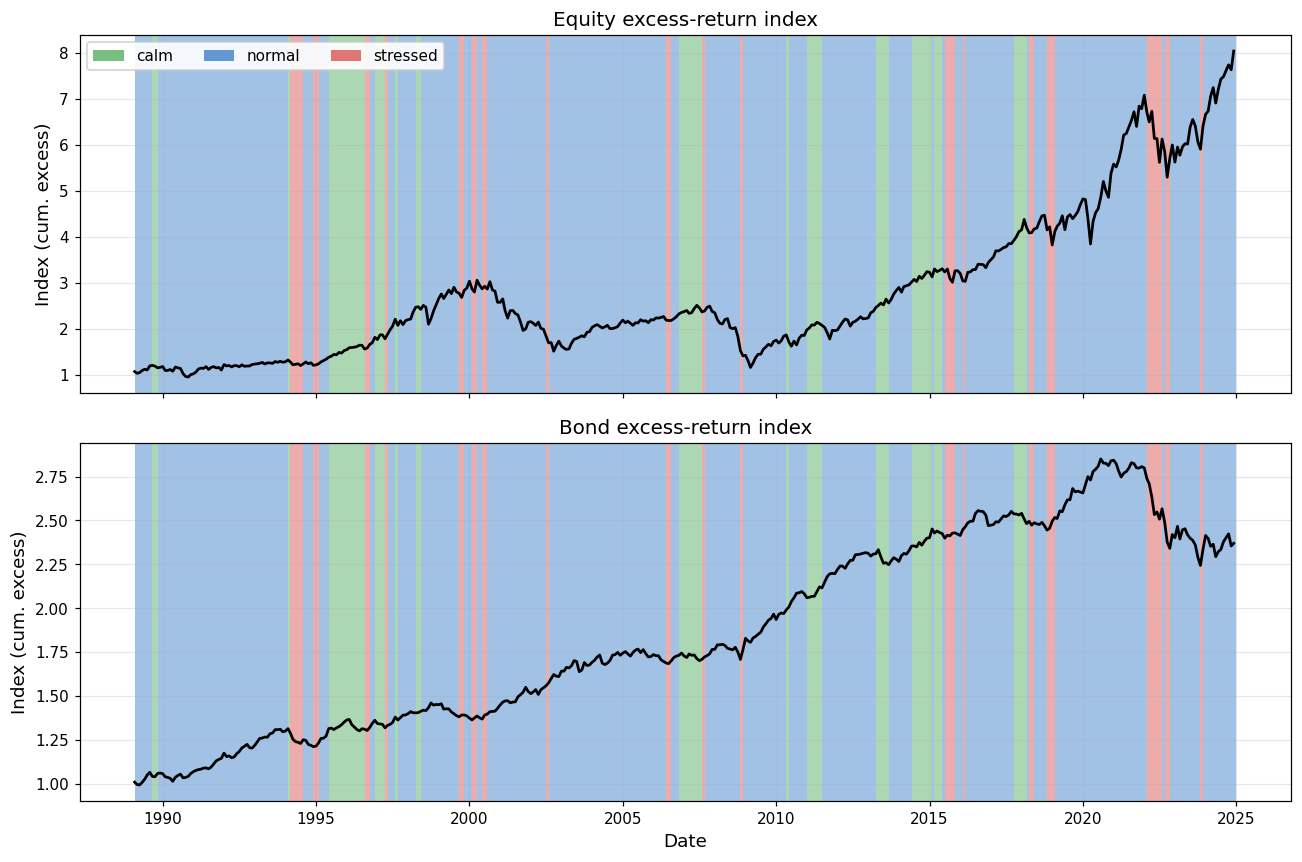

[saved] COUPLED__labels_sharpe.png / .pdf


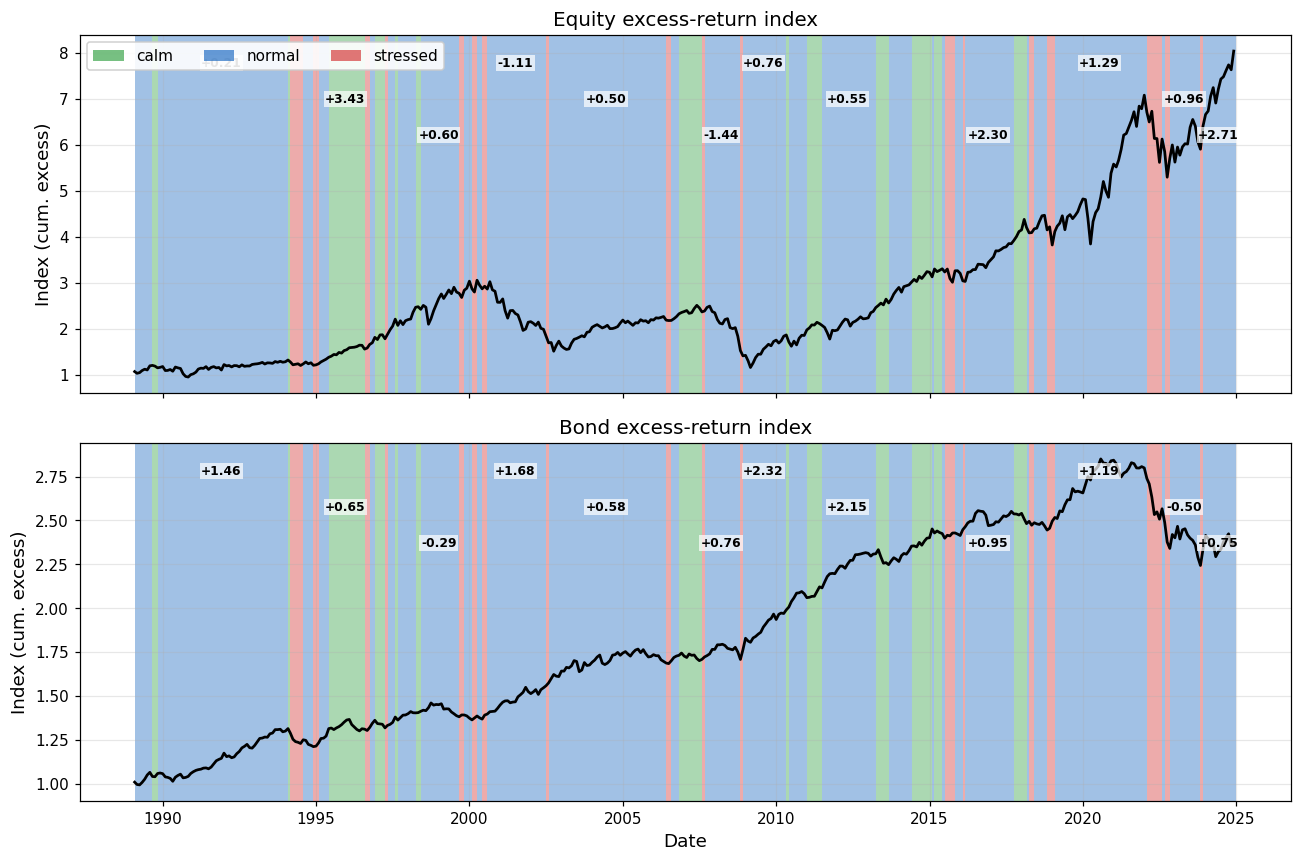

In [ ]:
# ============================================================================
# CELL 3 — FIGURE: COUPLED__labels + COUPLED__labels_sharpe
#   Window LABEL_START->LABEL_END
# ============================================================================
D = disp(LABDF).copy().sort_values("date").reset_index(drop=True)
D["eq_idx"] = (1.0 + D["eqx"]).cumprod()
D["bd_idx"] = (1.0 + D["bdx"]).cumprod()

PUNCHY={"calm":"#2e9e3f","normal":"#1565c0","stressed":"#d32f2f"}
def shade_punchy(ax,dates,regimes,alpha=0.40):
    for s,e,r in regime_spans(dates,regimes):
        ax.axvspan(s,e+pd.offsets.MonthEnd(1),color=PUNCHY.get(r,"white"),alpha=alpha,lw=0,zorder=0)
def punchy_legend():
    return [Patch(facecolor=PUNCHY[c],alpha=0.65,label=c) for c in LABEL_CLASSES]

def sr_insets(ax,df,retc,min_mo=9):
    ylo,yhi=ax.get_ylim(); slots=[0.92,0.82,0.72]; i=0
    for s,e,rg in regime_spans(df["date"],df["regime"]):
        if (e-s).days/30.4<min_mo: continue
        sr=ann_sr(df.loc[(df.date>=s)&(df.date<=e),retc])
        if not np.isfinite(sr): continue
        ax.text(s+(e-s)/2, ylo+slots[i%3]*(yhi-ylo), f"{sr:+.2f}", ha="center",va="center",
                fontsize=8,fontweight="bold",bbox=dict(fc="white",ec="none",alpha=0.7,pad=1)); i+=1

def make_labels_fig(with_sharpe):
    fig,axes=plt.subplots(2,1,figsize=(12,8),sharex=True)
    for ax,(ic,rc,t) in zip(axes,[("eq_idx","eqx","Equity excess-return index"),
                                  ("bd_idx","bdx","Bond excess-return index")]):
        shade_punchy(ax,D["date"],D["regime"]); ax.plot(D["date"],D[ic],color="black",lw=1.8,zorder=3)
        ax.set_title(t); ax.set_ylabel("Index (cum. excess)"); ax.margins(y=0.05)
        if with_sharpe: sr_insets(ax,D,rc)
    axes[0].legend(handles=punchy_legend(),loc="upper left",ncol=3,framealpha=0.9)
    year_axis(axes[1]); axes[1].set_xlabel("Date")
    fig.tight_layout(); return fig

save_fig(make_labels_fig(with_sharpe=False),"labels")
save_fig(make_labels_fig(with_sharpe=True),"labels_sharpe")

[saved] COUPLED__vote_kappa.png / .pdf


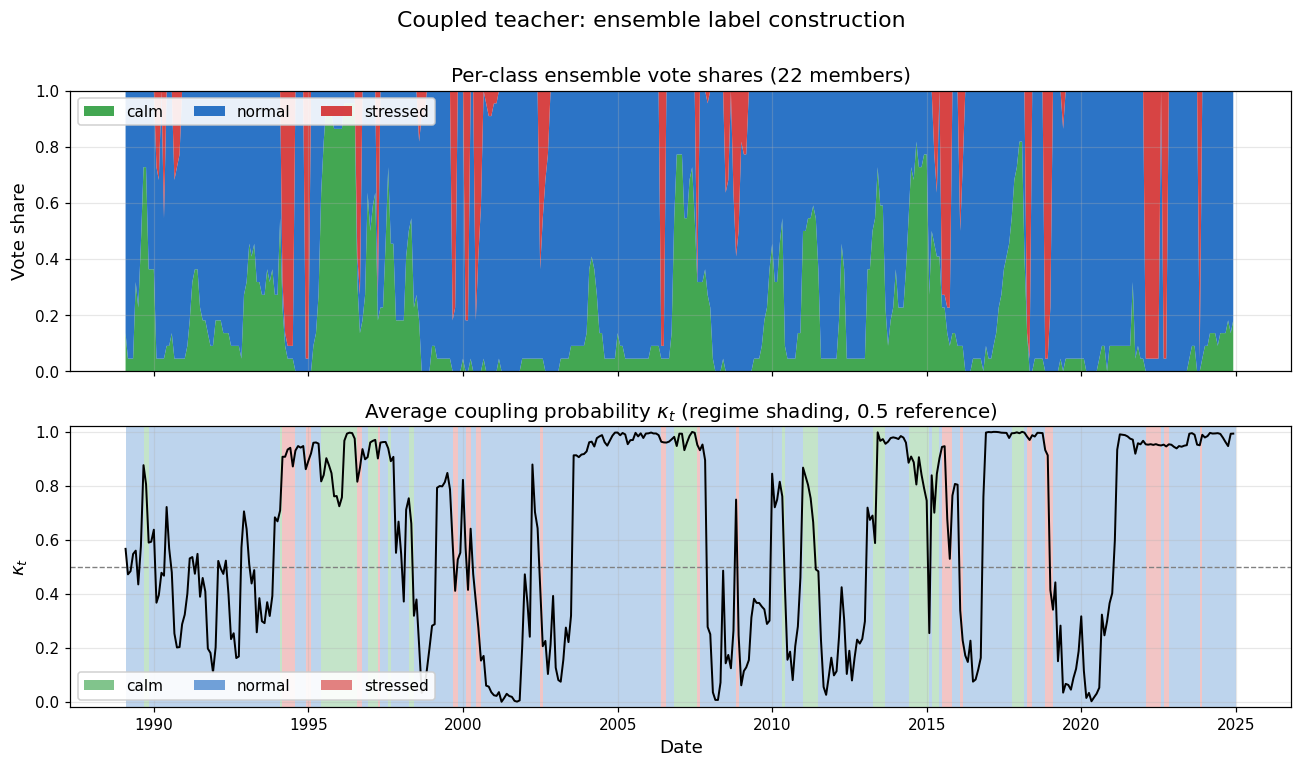

In [4]:
# ============================================================================
# CELL 4 — FIGURE: COUPLED__vote_kappa  (vote shares + kappa; paper Fig 2)
# ============================================================================
D=disp(LABDF)
fig,axes=plt.subplots(2,1,figsize=(12,7),sharex=True)
ax=axes[0]
ax.stackplot(D["date"],D["p_calm"],D["p_normal"],D["p_stressed"],
             colors=[REGIME_COLORS[c] for c in LABEL_CLASSES],labels=LABEL_CLASSES,alpha=0.9)
ax.set_ylim(0,1); ax.set_ylabel("Vote share"); ax.set_title("Per-class ensemble vote shares (22 members)")
ax.legend(loc="upper left",ncol=3,framealpha=0.9)
ax=axes[1]; shade(ax,D["date"],D["regime"])
ax.plot(D["date"],D["kappa"],color="black",lw=1.3,zorder=3); ax.axhline(0.5,color="grey",ls="--",lw=0.9)
ax.set_ylim(-0.02,1.02); ax.set_ylabel(r"$\kappa_t$")
ax.set_title(r"Average coupling probability $\kappa_t$ (regime shading, 0.5 reference)")
ax.legend(handles=regime_legend(),loc="lower left",ncol=3,framealpha=0.9)
year_axis(ax); ax.set_xlabel("Date")
fig.suptitle("Coupled teacher: ensemble label construction",y=0.995)
fig.tight_layout(); save_fig(fig,"vote_kappa")

In [5]:
# ============================================================================
# CELL 5 — TABLE: COUPLED__teacher_regime3  (three-regime summary; Table D.17)
# ============================================================================
L = win(LABDF).reset_index(drop=True)
durs=rle(L["regime"].tolist()); rows=[]
for c in LABEL_CLASSES:
    sub=L[L.regime==c]; spells=[n for v,n in durs if v==c]
    rows.append({"Regime":c,"Share":f"{len(sub)/len(L):.1%}",
        "Eq ret":f"{ann_ret(sub.eqx):+.1%}","Eq vol":f"{ann_vol(sub.eqx):.1%}","Eq Sharpe":f"{ann_sr(sub.eqx):+.2f}",
        "Bd ret":f"{ann_ret(sub.bdx):+.1%}","Bd vol":f"{ann_vol(sub.bdx):.1%}","Bd Sharpe":f"{ann_sr(sub.bdx):+.2f}",
        "Avg dur":round(float(np.mean(spells)),1) if spells else np.nan,"Spells":len(spells)})
save_tbl(pd.DataFrame(rows),"teacher_regime3",ff="%.2f")

[saved] COUPLED__teacher_regime3.csv / .tex


,Regime,Share,Eq ret,Eq vol,Eq Sharpe,Bd ret,Bd vol,Bd Sharpe,Avg dur,Spells
0,calm,14.2%,+21.0%,8.1%,+2.60,+0.8%,3.5%,+0.22,4.7,13
1,normal,76.6%,+10.1%,14.9%,+0.68,+4.1%,3.9%,+1.06,11.8,28
2,stressed,9.3%,-40.9%,13.7%,-2.99,-8.4%,5.0%,-1.69,2.2,18


In [6]:
# ============================================================================
# CELL 6 — TABLE: COUPLED__teacher_byasset  (per-leg fav/unfav; Table D.16)
# ============================================================================
L = win(LABDF).reset_index(drop=True)
rows=[]
for lab,fav,rc in [("Equity",(L.regime=="calm"),"eqx"),("Bond",(L.regime!="stressed"),"bdx")]:
    binseq=np.where(fav,"F","U")
    for st,mask,tag in [("Favourable",fav,"F"),("Unfavourable",~fav,"U")]:
        sub=L[mask]; sd=[n for v,n in rle(binseq) if v==tag]
        rows.append({"Label":lab,"State":st,"Share":f"{len(sub)/len(L):.1%}",
            "Ann return":f"{ann_ret(sub[rc]):+.1%}","Ann vol":f"{ann_vol(sub[rc]):.1%}",
            "Sharpe":f"{ann_sr(sub[rc]):+.2f}","State dur":round(float(np.mean(sd)),1) if sd else np.nan,
            "Switches":n_sw(binseq)})
save_tbl(pd.DataFrame(rows),"teacher_byasset",ff="%.2f")

[saved] COUPLED__teacher_byasset.csv / .tex


,Label,State,Share,Ann return,Ann vol,Sharpe,State dur,Switches
0,Equity,Favourable,14.2%,+21.0%,8.1%,+2.60,4.7,26
1,Equity,Unfavourable,85.8%,+4.6%,15.5%,+0.30,26.4,26
2,Bond,Favourable,90.7%,+3.6%,3.9%,+0.93,20.6,36
3,Bond,Unfavourable,9.3%,-8.4%,5.0%,-1.69,2.2,36


In [7]:
# ============================================================================
# CELL 7 — TABLE: COUPLED__teacher_transition  (transition % + E[dur]; D.14)
# ============================================================================
L = win(LABDF).reset_index(drop=True)
seq=list(L["regime"]); M=pd.DataFrame(0.0,index=LABEL_CLASSES,columns=LABEL_CLASSES)
for a,b in zip(seq[:-1],seq[1:]): M.loc[a,b]+=1
P=M.div(M.sum(1).replace(0,np.nan),axis=0)
out=(P*100).round(1)
out["E[dur]"]=[round(1/(1-P.loc[c,c]),1) if P.loc[c,c]<1 else np.inf for c in LABEL_CLASSES]
out=out.reset_index().rename(columns={"index":"From\\To"})
save_tbl(out,"teacher_transition",ff="%.1f")

[saved] COUPLED__teacher_transition.csv / .tex


,From\To,calm,normal,stressed,E[dur]
0,calm,78.7,14.8,6.6,4.7
1,normal,4.0,91.8,4.3,12.2
2,stressed,0.0,45.0,55.0,2.2


In [8]:
# ============================================================================
# CELL 8 — TABLE: COUPLED__teacher_crisis  (crisis-window mix; Table 3 / C.11)
# ============================================================================
LW = win(LABDF)
CRISIS={"1990 recession":("1990-07","1991-03"),"1994 bond shock":("1994-01","1994-12"),
        "Dot-com bust":("2000-09","2003-04"),"Global financial crisis":("2007-11","2009-04"),
        "Euro sovereign 2011":("2011-05","2011-12"),"Covid crash":("2020-02","2020-04"),
        "Inflation 2022":("2022-01","2022-12")}
rows=[]
for w,(a,b) in CRISIS.items():
    sub=LW[(LW.date>=pd.Timestamp(a))&(LW.date<=pd.Timestamp(b)+pd.offsets.MonthEnd(0))]
    if not len(sub): continue
    rows.append({"Window":w,"Months":len(sub),
        "Calm":f"{(sub.regime=='calm').mean():.0%}","Normal":f"{(sub.regime=='normal').mean():.0%}",
        "Stressed":f"{(sub.regime=='stressed').mean():.0%}",
        "Eq Sharpe":f"{ann_sr(sub.eqx):+.2f}","Bd Sharpe":f"{ann_sr(sub.bdx):+.2f}"})
save_tbl(pd.DataFrame(rows),"teacher_crisis",ff="%.2f")

[saved] COUPLED__teacher_crisis.csv / .tex


,Window,Months,Calm,Normal,Stressed,Eq Sharpe,Bd Sharpe
0,1990 recession,9,0%,100%,0%,+0.05,+1.41
1,1994 bond shock,12,8%,33%,58%,-0.48,-1.61
2,Dot-com bust,32,0%,97%,3%,-1.07,+1.97
3,Global financial crisis,18,0%,94%,6%,-1.58,+0.74
4,Euro sovereign 2011,8,12%,88%,0%,-0.61,+3.69
5,Covid crash,3,0%,100%,0%,-0.88,+2.76
6,Inflation 2022,12,0%,33%,67%,-0.93,-1.90


In [9]:
# ============================================================================
# CELL 8b — TABLE: COUPLED__teacher_crisis_detail
#           Per-leg per-window detail.
# ============================================================================
LW = win(LABDF)
CRISIS = {"1990 recession": ("1990-07", "1991-03"), "1994 bond shock": ("1994-01", "1994-12"),
          "Dot-com bust": ("2000-09", "2003-04"), "Global financial crisis": ("2007-11", "2009-04"),
          "Euro sovereign 2011": ("2011-05", "2011-12"), "Covid crash": ("2020-02", "2020-04"),
          "Inflation 2022": ("2022-01", "2022-12")}
rows = []
for leg, lab in [("eqx", "Equity"), ("bdx", "Bond")]:
    for w, (a, b) in CRISIS.items():
        sub = LW[(LW.date >= pd.Timestamp(a)) & (LW.date <= pd.Timestamp(b) + pd.offsets.MonthEnd(0))]
        if not len(sub):
            continue
        r = sub[leg].dropna(); wealth = (1 + r).cumprod().values
        rows.append({"Label": lab, "Window": w, "Months": len(sub),
                     "Stressed sh.": f"{(sub.regime == 'stressed').mean():.0%}",
                     "Ann. ret.": f"{ann_ret(r):+.1%}", "Ann. vol.": f"{ann_vol(r):.1%}",
                     "Sharpe": f"{ann_sr(r):+.2f}", "Worst": f"{r.min():.1%}",
                     "Max. DD": f"{max_dd(wealth):.1%}"})
save_tbl(pd.DataFrame(rows), "teacher_crisis_detail", ff="%.2f")

[saved] COUPLED__teacher_crisis_detail.csv / .tex


,Label,Window,Months,Stressed sh.,Ann. ret.,Ann. vol.,Sharpe,Worst,Max. DD
0,Equity,1990 recession,9,0%,+0.8%,17.4%,+0.05,-10.1%,-16.4%
1,Equity,1994 bond shock,12,58%,-4.9%,10.1%,-0.48,-4.8%,-9.0%
2,Equity,Dot-com bust,32,3%,-20.0%,18.6%,-1.07,-11.1%,-46.9%
3,Equity,Global financial crisis,18,6%,-36.4%,23.1%,-1.58,-17.0%,-51.3%
4,Equity,Euro sovereign 2011,8,0%,-10.6%,17.5%,-0.61,-7.2%,-15.9%
5,Equity,Covid crash,3,0%,-33.9%,38.4%,-0.88,-12.6%,-12.6%
6,Equity,Inflation 2022,12,67%,-20.4%,21.9%,-0.93,-9.5%,-21.3%
7,Bond,1990 recession,9,0%,+4.5%,3.2%,+1.41,-2.0%,-2.0%
8,Bond,1994 bond shock,12,58%,-6.7%,4.2%,-1.61,-2.7%,-7.8%
9,Bond,Dot-com bust,32,3%,+6.5%,3.3%,+1.97,-1.8%,-2.6%


In [10]:
# ============================================================================
# CELL 9 — TABLE: COUPLED__teacher_members  (22 members; Table D.18)
# ============================================================================
def member_sep(d):
    m=d.merge(RET[["date","eqx"]],on="date",how="left")
    srs=[ann_sr(m.loc[m.regime==c,"eqx"]) for c in LABEL_CLASSES]; srs=[s for s in srs if np.isfinite(s)]
    return (max(srs)-min(srs)) if len(srs)>=2 else np.nan
rows=[]
for k in MEMBER_ORDER:
    d=win(MEM[k]); fam,norm=k.rsplit("_",1); sh={c:float((d.regime==c).mean()) for c in LABEL_CLASSES}
    rows.append({"Family":fam,"Norm":norm,"Calm":round(sh["calm"],2),"Normal":round(sh["normal"],2),
        "Stress.":round(sh["stressed"],2),"Switches":n_sw(d.regime),"Avg dur":round(avg_dur(d.regime),1),
        "Sep":round(member_sep(d),2),
        "lambda":int(d["lambda_E"].mode().iloc[0]) if "lambda_E" in d else np.nan,
        "eta":int(d["eta"].mode().iloc[0]) if "eta" in d else np.nan})
save_tbl(pd.DataFrame(rows).sort_values("Sep",ascending=False).reset_index(drop=True),"teacher_members",ff="%.2f")

[saved] COUPLED__teacher_members.csv / .tex


,Family,Norm,Calm,Normal,Stress.,Switches,Avg dur,Sep,lambda,eta
0,sortino,L2,0.03,0.84,0.13,59,7.2,7.07,2,8
1,all,L1,0.20,0.70,0.10,85,5.0,6.24,2,1
2,sortino_trend,L2,0.06,0.83,0.11,55,7.7,5.96,2,4
3,sortino,L1,0.19,0.69,0.11,77,5.5,5.89,2,2
4,mom,L2,0.05,0.83,0.13,55,7.7,5.83,2,4
5,core,L1,0.13,0.77,0.10,52,8.1,5.70,2,1
6,sortino_dd,L1,0.18,0.71,0.10,62,6.8,5.69,2,1
7,sortino_dd,L2,0.08,0.81,0.12,53,8.0,5.67,2,1
8,sortino_short,L1,0.20,0.71,0.09,71,6.0,5.60,2,2
9,sortino_trend,L1,0.28,0.60,0.11,77,5.5,5.29,3,2


In [11]:
# ============================================================================
# CELL 10 — TABLE: COUPLED__teacher_feature_separation  (Table D.19)
# ============================================================================
def rolling_z(s,win_=120,wp=0.01):
    x=s.to_numpy(float); z=np.full_like(x,np.nan)
    for t in range(len(x)):
        b=x[max(0,t-win_+1):t+1]; b=b[~np.isnan(b)]
        if len(b)<12: continue
        ql,qh=np.nanquantile(b,wp),np.nanquantile(b,1-wp); b=np.clip(b,ql,qh)
        sd=b.std(); z[t]=((min(max(x[t],ql),qh))-b.mean())/sd if sd>1e-12 else 0.0
    return z
FEATZ=FEATP[["date"]].copy()
for c in EQ_FEATS+BD_FEATS:
    if c in FEATP.columns: FEATZ[c]=rolling_z(FEATP[c])
fz=FEATZ.merge(LBL[["date","regime"]],on="date",how="inner")
fz=win(fz)
rows=[]
for c in EQ_FEATS+BD_FEATS:
    if c not in fz.columns: continue
    g=fz.groupby("regime")[c].mean(); v={r:g.get(r,np.nan) for r in LABEL_CLASSES}
    rows.append({"Feature":c,"Sep":round(np.nanmax(list(v.values()))-np.nanmin(list(v.values())),2),
        "Calm":round(v["calm"],2),"Normal":round(v["normal"],2),"Stressed":round(v["stressed"],2)})
save_tbl(pd.DataFrame(rows).sort_values("Sep",ascending=False).reset_index(drop=True),
         "teacher_feature_separation",ff="%.2f")

[saved] COUPLED__teacher_feature_separation.csv / .tex


,Feature,Sep,Calm,Normal,Stressed
0,eq_sortino_4,2.62,1.72,-0.11,-0.90
1,eq_sortino_2,2.54,1.72,-0.11,-0.82
2,eq_ma_cross,2.30,0.89,-0.02,-1.41
3,eq_sortino_1,2.17,1.56,-0.09,-0.61
4,eq_dd_diff,2.08,-1.05,0.02,1.03
5,eq_trend,2.02,0.82,-0.07,-1.20
6,eq_sortino_l,1.99,1.60,-0.07,-0.39
7,bd_trend,1.62,-0.09,0.09,-1.52
8,bd_sortino_l,1.43,-0.06,0.13,-1.30
9,eq_dd_lvl,1.39,-1.18,0.19,0.22


[saved] COUPLED__feats_eq.png / .pdf


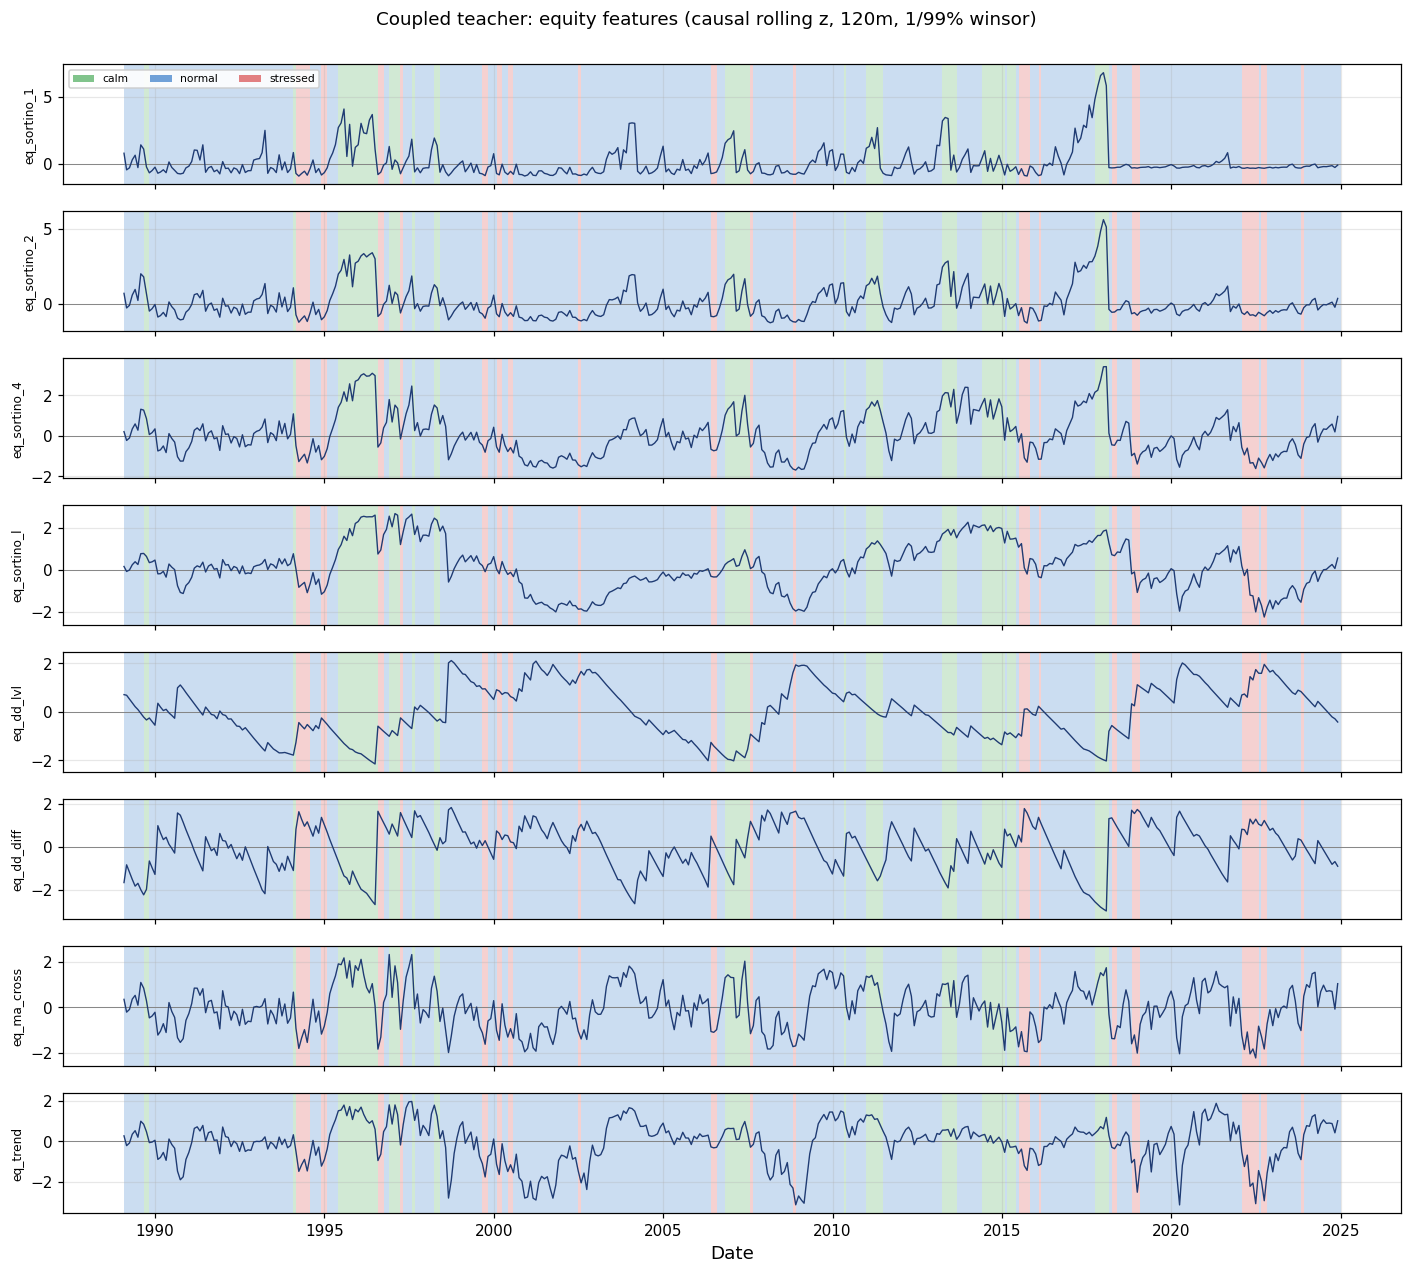

In [12]:
# ============================================================================
# CELL 11 — FIGURE: COUPLED__feats_eq  (equity features rolling-z; Fig D.19)
# ============================================================================
def feats_fig(cols,tag,title):
    present=[c for c in cols if c in FEATZ.columns]
    FZ=disp(FEATZ); LB=disp(LBL)
    fig,axes=plt.subplots(len(present),1,figsize=(13,1.45*len(present)),sharex=True)
    if len(present)==1: axes=[axes]
    for ax,c in zip(axes,present):
        shade(ax,LB["date"],LB["regime"],alpha=0.22)
        ax.plot(FZ["date"],FZ[c],color="#1f3b73",lw=0.9,zorder=3); ax.axhline(0,color="grey",lw=0.6)
        ax.set_ylabel(c,fontsize=8); ax.margins(y=0.08)
    axes[0].legend(handles=regime_legend(),loc="upper left",ncol=3,fontsize=7,framealpha=0.9)
    year_axis(axes[-1]); axes[-1].set_xlabel("Date")
    fig.suptitle(title,y=0.997,fontsize=12); fig.tight_layout(); save_fig(fig,tag)
feats_fig(EQ_FEATS,"feats_eq","Coupled teacher: equity features (causal rolling z, 120m, 1/99% winsor)")

[saved] COUPLED__feats_bd.png / .pdf


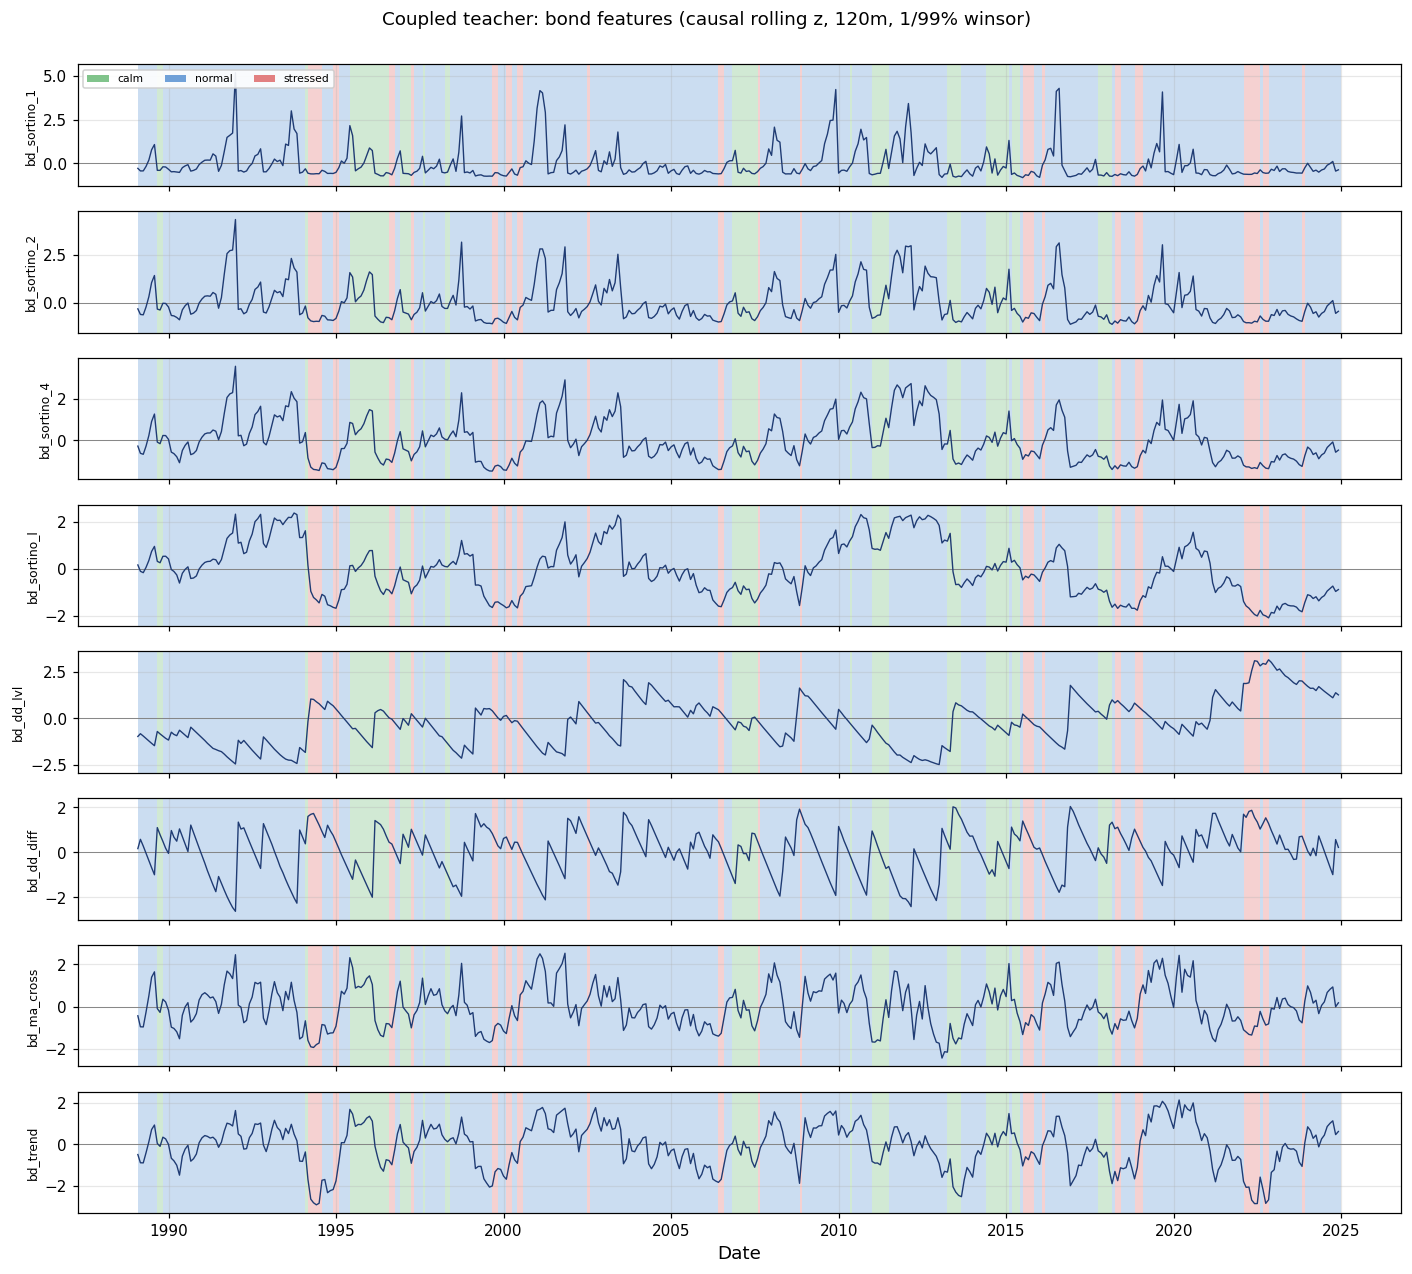

In [13]:
# ============================================================================
# CELL 12 — FIGURE: COUPLED__feats_bd  (bond features rolling-z; Fig D.20)
# ============================================================================
feats_fig(BD_FEATS,"feats_bd","Coupled teacher: bond features (causal rolling z, 120m, 1/99% winsor)")

[saved] COUPLED__member_raster.png / .pdf


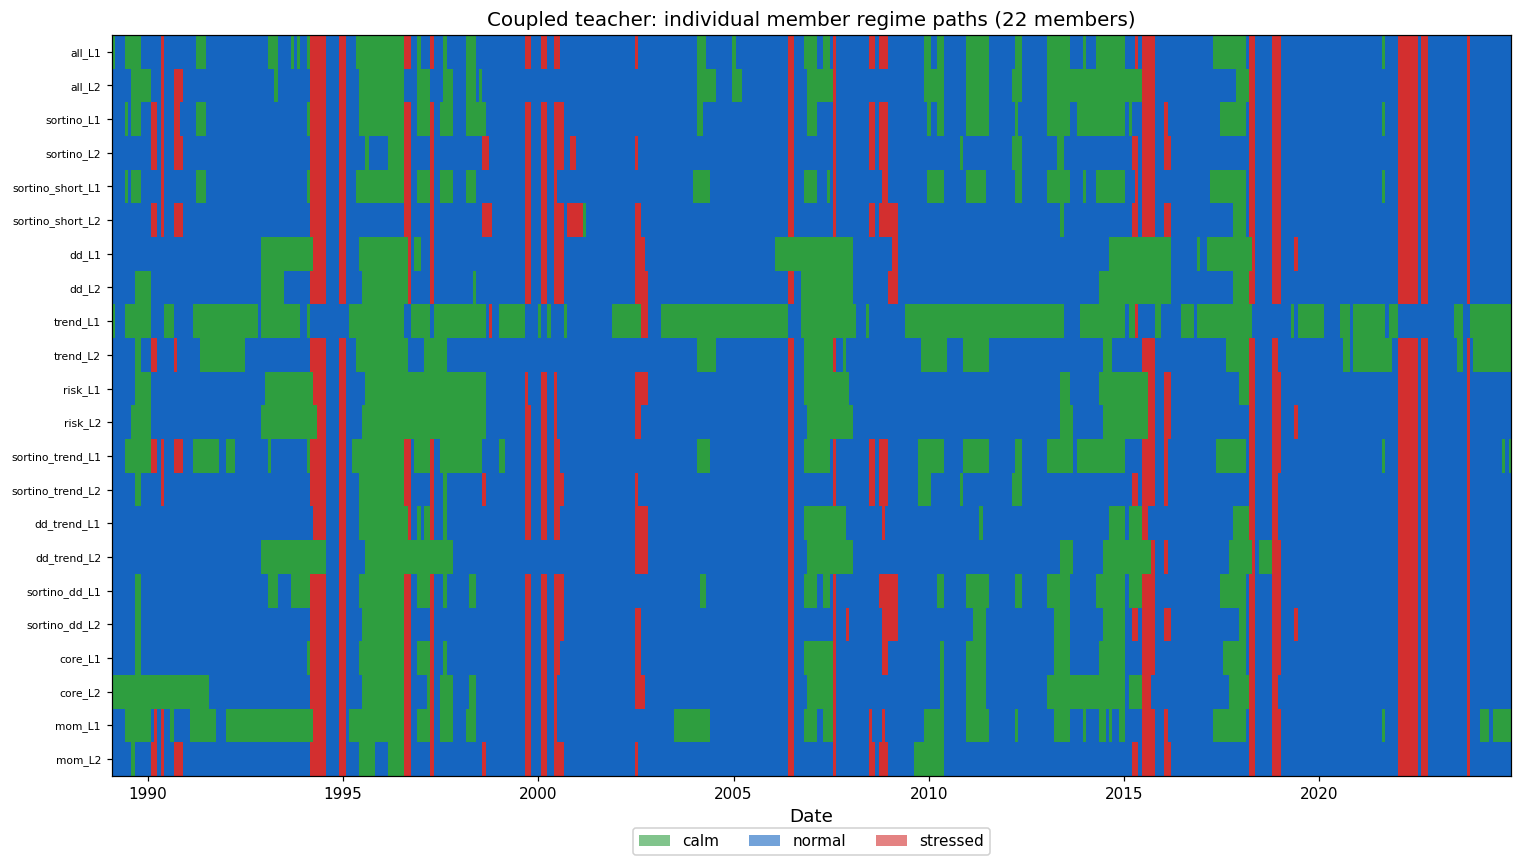

In [14]:
# ============================================================================
# CELL 13 — FIGURE: COUPLED__member_raster  (22 member paths; Fig D.26)
# ============================================================================
all_dates=sorted(set().union(*[set(MEM[k]["date"]) for k in MEMBER_ORDER]))
all_dates=[d for d in all_dates if (d>=LABEL_START and d<=LABEL_END)]   # ALIGNED window
didx={d:i for i,d in enumerate(all_dates)}
R=np.full((len(MEMBER_ORDER),len(all_dates)),np.nan)
for r,k in enumerate(MEMBER_ORDER):
    for _,row in MEM[k].iterrows():
        if pd.notna(row["regime"]) and row["date"] in didx: R[r,didx[row["date"]]]=REGIME_INT[row["regime"]]
fig,ax=plt.subplots(figsize=(14,8))
ax.imshow(R,aspect="auto",cmap=ListedColormap([REGIME_COLORS[c] for c in LABEL_CLASSES]),
          interpolation="nearest",vmin=0,vmax=2,
          extent=[mdates.date2num(all_dates[0]),mdates.date2num(all_dates[-1]),len(MEMBER_ORDER),0])
ax.set_yticks(np.arange(len(MEMBER_ORDER))+0.5); ax.set_yticklabels(MEMBER_ORDER,fontsize=7)
ax.xaxis_date(); year_axis(ax); ax.grid(False); ax.set_xlabel("Date")
ax.legend(handles=regime_legend(),loc="upper center",bbox_to_anchor=(0.5,-0.06),ncol=3,framealpha=0.9)
ax.set_title("Coupled teacher: individual member regime paths (22 members)")
fig.tight_layout(); save_fig(fig,"member_raster")

[saved] COUPLED__majority_vote_scopes.png / .pdf


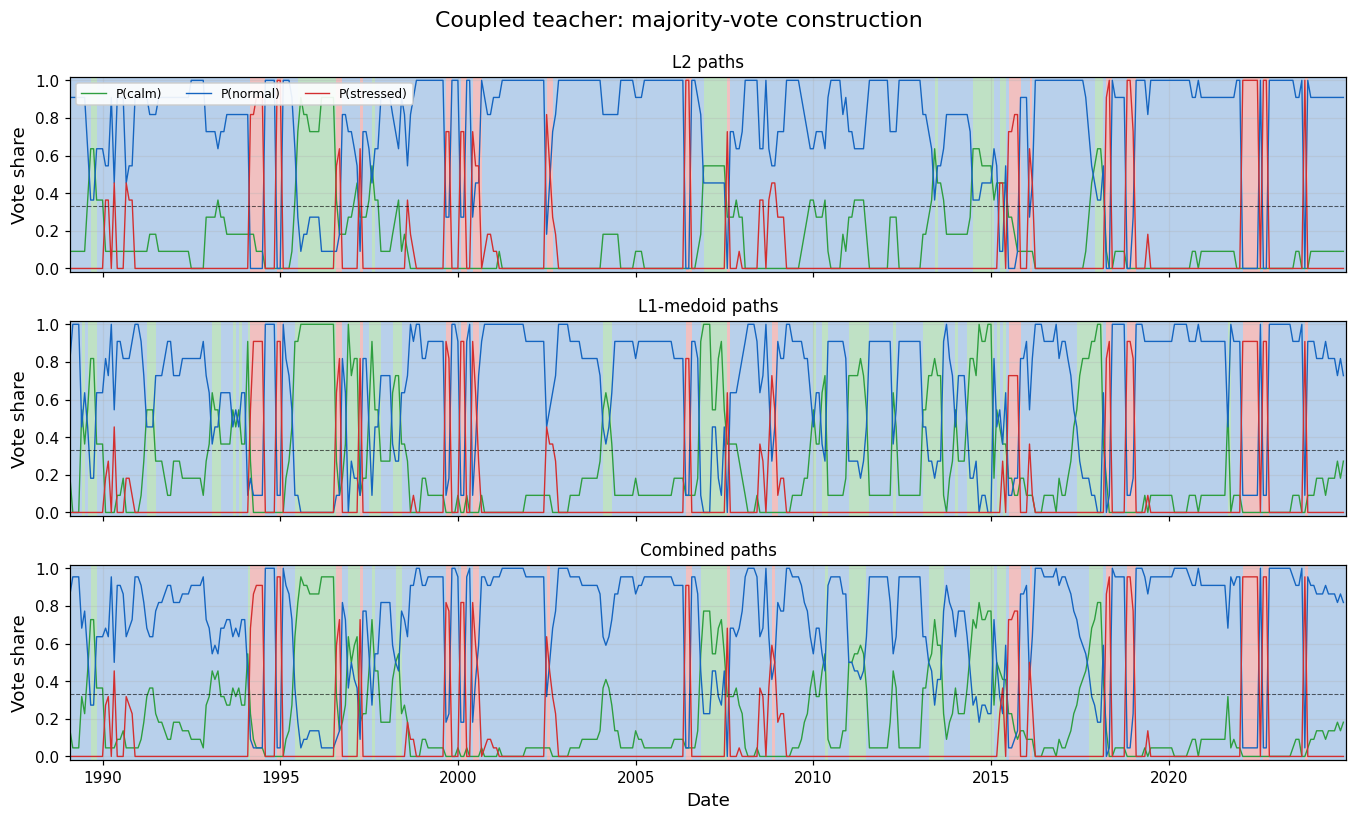

In [ ]:
# ============================================================================
# CELL 13b — FIGURE: COUPLED__majority_vote_scopes  (Figure-4)
#   3 panels (L2 / L1 / combined). Three thin lines = calm/normal/stressed vote
#   shares. Background shades the majority regime. Dashed 1/3 reference.
#   Window: both-edged disp() (LABEL_START->LABEL_END);
# ============================================================================
L2_MEMBERS = [k for k in MEMBER_ORDER if k.rsplit("_", 1)[1].upper() == "L2"]
L1_MEMBERS = [k for k in MEMBER_ORDER if k.rsplit("_", 1)[1].upper() == "L1"]
SCOPES = [("L2 paths", L2_MEMBERS),
          ("L1-medoid paths", L1_MEMBERS),
          ("Combined paths", MEMBER_ORDER)]

def scope_shares(keys):
    counts = {}
    for k in keys:
        d = disp(MEM[k])
        for dt, rg in zip(d["date"], d["regime"]):
            if pd.notna(rg):
                c = counts.setdefault(dt, {"calm": 0, "normal": 0, "stressed": 0})
                c[rg] += 1
    rows = []
    for dt in sorted(counts):
        c = counts[dt]; n = sum(c.values())
        rows.append({"date": dt, "maj": max(LABEL_CLASSES, key=lambda x: c[x]),
                     **{cls: c[cls] / n for cls in LABEL_CLASSES}})
    return pd.DataFrame(rows)

fig, axes = plt.subplots(3, 1, figsize=(12.5, 7.6), sharex=True)
for ax, (title, keys) in zip(axes, SCOPES):
    sv = scope_shares(keys)
    shade(ax, sv["date"], sv["maj"], alpha=0.30)
    for cls in LABEL_CLASSES:
        ax.plot(sv["date"], sv[cls], color=LINE_COLORS[cls], lw=0.9, label=f"P({cls})")
    ax.axhline(1/3, color="black", ls="--", lw=0.7, alpha=0.6)
    ax.set_ylim(-0.02, 1.02); ax.set_ylabel("Vote share")
    ax.set_title(title, fontsize=11); ax.margins(x=0)
axes[0].legend(loc="upper left", ncol=3, framealpha=0.9, fontsize=8)
year_axis(axes[-1]); axes[-1].set_xlabel("Date")
fig.suptitle("Coupled teacher: majority-vote construction", y=0.98)
fig.tight_layout()
save_fig(fig, "majority_vote_scopes")

In [ ]:
# ============================================================================
# CELL 14 — lambda x eta sweep via fit_member, monthly rolling-forward,
#           one full pass per (lambda, eta) over production grids, L1 & L2
# ============================================================================
import time
LABEL_CLASSES=["calm","normal","stressed"]
JOINT=np.array([(0,0),(1,0),(1,1)],dtype=np.int8); NS=JOINT.shape[0]
WARMUP_MONTHS=132; REFIT_CADENCE=1; N_INITS_BATCH=10; MAX_EM_ITERS=10; EM_TOL=1e-6
RANDOM_STATE=42; EPS=1e-12; STD_WINDOW=120; WINSOR_P=0.01; W_CLIP=(0.0,1.0)
VALIDATION_MONTHS=60; STRESSED_TARGET_SHARE=0.18; W_LOGIT_C=1.0
_AGREE=np.array([1.0 if iE==iB else 0.0 for iE,iB in JOINT]); _DISAGREE=1.0-_AGREE

def _build_transition_cost(lE,lB):
    L=np.zeros((NS,NS))
    for i,(iE,iB) in enumerate(JOINT):
        for j,(jE,jB) in enumerate(JOINT): L[i,j]=lE*(iE!=jE)+lB*(iB!=jB)
    return L
def _coupling_for_w(w,eta): return eta*(w*_DISAGREE+(1.0-w)*_AGREE)
def _emission_costs_full(Ze,Zb,me,mb,w,eta,norm="L1"):
    dist=(lambda Z,m:np.linalg.norm(Z-m,axis=1)) if norm=="L2" else (lambda Z,m:np.sum(np.abs(Z-m),axis=1))
    de=np.stack([dist(Ze,me[0]),dist(Ze,me[1])],1); db=np.stack([dist(Zb,mb[0]),dist(Zb,mb[1])],1)
    e=np.empty((Ze.shape[0],NS))
    for j,(jE,jB) in enumerate(JOINT): e[:,j]=de[:,jE]+db[:,jB]
    return e+eta*(w[:,None]*_DISAGREE[None,:]+(1.0-w[:,None])*_AGREE[None,:])
def _emission_for_one_obs(ze,zb,me,mb,w,eta,norm="L1"):
    dd=(lambda z,m:float(np.linalg.norm(z-m))) if norm=="L2" else (lambda z,m:float(np.sum(np.abs(z-m))))
    de=np.array([dd(ze,me[0]),dd(ze,me[1])]); db=np.array([dd(zb,mb[0]),dd(zb,mb[1])])
    e=np.empty(NS)
    for j,(jE,jB) in enumerate(JOINT): e[j]=de[jE]+db[jB]
    return e+_coupling_for_w(w,eta)
def _viterbi(e,L):
    T=e.shape[0]; V=np.empty((T,NS)); bp=np.zeros((T,NS),np.int8); V[0]=e[0]
    for t in range(1,T):
        sc=V[t-1][:,None]+L; bp[t]=np.argmin(sc,0); V[t]=e[t]+sc[bp[t],np.arange(NS)]
    p=np.empty(T,np.int8); p[-1]=int(np.argmin(V[-1]))
    for t in range(T-2,-1,-1): p[t]=bp[t+1,p[t+1]]
    return p,float(V[-1].min())
def _greedy_online_step(ze,zb,w,A_prev,me,mb,L,eta,norm="L1"):
    e=_emission_for_one_obs(ze,zb,me,mb,w,eta,norm); A=(A_prev[:,None]+L).min(0)+e
    return int(np.argmin(A)),A
def _center(Z,mask,norm):
    pts=Z[mask] if np.any(mask) else Z
    return pts.mean(0) if norm=="L2" else np.median(pts,0)
def _fit_centroids(Ze,Zb,se,sb,norm="L1"):
    return (np.stack([_center(Ze,se==k,norm) for k in (0,1)]),
            np.stack([_center(Zb,sb==k,norm) for k in (0,1)]))
def _fit_w_logit(Xmc,se,sb):
    y=(se==sb).astype(int)
    if y.sum()==0 or y.sum()==len(y): return np.clip(np.full(len(y),float(y.mean())),*W_CLIP),None
    clf=LogisticRegression(penalty="l2",C=W_LOGIT_C,solver="lbfgs",max_iter=400,
                           class_weight="balanced",random_state=RANDOM_STATE).fit(Xmc,y)
    return np.clip(clf.predict_proba(Xmc)[:,1],*W_CLIP),clf
def _fit_batch_jm(Ze,Zb,Xmc,lE,lB,eta,n_init=1,max_iter=MAX_EM_ITERS,tol=EM_TOL,
                  random_state=RANDOM_STATE,warm_start=None,norm="L1"):
    rng=np.random.default_rng(random_state); T=Ze.shape[0]; L=_build_transition_cost(lE,lB); best=None
    for it in range(n_init):
        if it==0 and warm_start is not None:
            we,wb=warm_start
            if len(we)>=T: se,sb=we[-T:].copy(),wb[-T:].copy()
            else:
                pad=T-len(we); se=np.concatenate([we,np.repeat(we[-1],pad)]).astype(np.int8)
                sb=np.concatenate([wb,np.repeat(wb[-1],pad)]).astype(np.int8)
        else:
            se=rng.integers(0,2,T).astype(np.int8); sb=rng.integers(0,2,T).astype(np.int8)
        prev=np.inf; clf=None; w=None
        for _ in range(max_iter):
            me,mb=_fit_centroids(Ze,Zb,se,sb,norm); w,clf=_fit_w_logit(Xmc,se,sb)
            e=_emission_costs_full(Ze,Zb,me,mb,w,eta,norm); p,obj=_viterbi(e,L)
            se,sb=JOINT[p,0].copy(),JOINT[p,1].copy()
            if abs(prev-obj)<tol: break
            prev=obj
        if best is None or obj<best["obj"]:
            best={"s_eq":se.copy(),"s_bd":sb.copy(),"mu_eq":me.copy(),"mu_bd":mb.copy(),
                  "w_t":w.copy(),"clf":clf,"obj":float(obj),"Lambda":L,"eta":float(eta),
                  "lambda_E":float(lE),"lambda_B":float(lB)}
    return best
def _canonicalize_by_risk(fit,eqw,bdw):
    se=np.asarray(fit["s_eq"]); sb=np.asarray(fit["s_bd"])
    if (np.mean(eqw[se==0]) if np.any(se==0) else np.inf)<(np.mean(eqw[se==1]) if np.any(se==1) else np.inf):
        fit["s_eq"]=(1-se).astype(np.int8); fit["mu_eq"]=fit["mu_eq"][[1,0]].copy()
    if (np.mean(bdw[sb==0]) if np.any(sb==0) else np.inf)<(np.mean(bdw[sb==1]) if np.any(sb==1) else np.inf):
        fit["s_bd"]=(1-sb).astype(np.int8); fit["mu_bd"]=fit["mu_bd"][[1,0]].copy()
    return fit
def _joint_idx_to_label(j):
    iE,iB=JOINT[j]; return "calm" if (iE==0 and iB==0) else ("stressed" if (iE==1 and iB==1) else "normal")
def _rolling_z(arr2d,win,winsor_p=WINSOR_P):
    X=np.asarray(arr2d,float); T,K=X.shape; Z=np.empty_like(X)
    for t in range(T):
        block=X[max(0,t-win+1):t+1]
        if winsor_p and block.shape[0]>=10:
            ql=np.nanquantile(block,winsor_p,0); qh=np.nanquantile(block,1-winsor_p,0)
            block=np.clip(block,ql,qh); xt=np.clip(X[t],ql,qh)
        else: xt=X[t]
        mu=np.nanmean(block,0); sd=np.nanstd(block,0); Z[t]=(xt-mu)/np.where(sd>1e-12,sd,1.0)
    return Z
def _winsor_bounds(block,winsor_p=WINSOR_P):
    if not winsor_p or block.shape[0]<10: return None,None
    return np.nanquantile(block,winsor_p,0),np.nanquantile(block,1-winsor_p,0)
def _cap_stressed(out_df,trend_series,target=STRESSED_TARGET_SHARE,win=STD_WINDOW):
    df=out_df.merge(trend_series,on="date",how="left").reset_index(drop=True)
    tr=df["eq_ma_cross"].to_numpy(float); reg=df["regime"].to_numpy(object).copy()
    for t in range(len(df)):
        if reg[t]!="stressed": continue
        block=tr[max(0,t-win+1):t+1]; block=block[~np.isnan(block)]
        if len(block)>=12 and not np.isnan(tr[t]) and tr[t]>np.quantile(block,target): reg[t]="normal"
    out_df=out_df.copy(); out_df["regime"]=reg; return out_df

def fit_member_fixed(feature_panel,eq_cols,bd_cols,macro_cols,name,lam,eta,norm):
    dedup=lambda s:list(dict.fromkeys(s)); eq_cols=dedup(eq_cols); bd_cols=dedup(bd_cols); macro_cols=dedup(macro_cols)
    needed=dedup(["date","equity_excess","bond_excess"]+eq_cols+bd_cols+macro_cols)
    df=feature_panel.loc[feature_panel[needed].notna().all(axis=1),needed].copy().sort_values("date").reset_index(drop=True)
    n=len(df); Wm=WARMUP_MONTHS
    date_arr=df["date"].values
    eqX=df[eq_cols].to_numpy(float); bdX=df[bd_cols].to_numpy(float); mcX=df[macro_cols].to_numpy(float)
    eq_ex=df["equity_excess"].to_numpy(float); bd_ex=df["bond_excess"].to_numpy(float)
    out=[]; theta=None; A_prev=None; msr=REFIT_CADENCE
    for t in range(Wm,n):
        if msr>=REFIT_CADENCE-1:
            Z_eq=_rolling_z(eqX[:t+1],STD_WINDOW); Z_bd=_rolling_z(bdX[:t+1],STD_WINDOW); X_mc=_rolling_z(mcX[:t+1],STD_WINDOW)
            eqw=eq_ex[:t+1]; bdw=bd_ex[:t+1]
            warm=(theta["s_eq_full"],theta["s_bd_full"]) if theta is not None else None
            best=_fit_batch_jm(Z_eq,Z_bd,X_mc,lam,lam,eta,n_init=1,warm_start=warm,norm=norm)
            best=_canonicalize_by_risk(best,eqw,bdw)
            wb=_winsor_bounds
            theta={"mu_eq":best["mu_eq"],"mu_bd":best["mu_bd"],"Lambda":best["Lambda"],"eta":best["eta"],
                   "clf":best["clf"],"s_eq_full":best["s_eq"].copy(),"s_bd_full":best["s_bd"].copy(),
                   "lambda_E":best["lambda_E"],"lambda_B":best["lambda_B"],
                   **(lambda eb,bb,mb:{ "eq_lo":wb(eb)[0],"eq_hi":wb(eb)[1],"bd_lo":wb(bb)[0],"bd_hi":wb(bb)[1],
                       "mc_lo":wb(mb)[0],"mc_hi":wb(mb)[1],
                       "eq_mu":np.nanmean(np.clip(eb,*wb(eb)) if wb(eb)[0] is not None else eb,0),
                       "eq_sd":np.nanstd(np.clip(eb,*wb(eb)) if wb(eb)[0] is not None else eb,0),
                       "bd_mu":np.nanmean(np.clip(bb,*wb(bb)) if wb(bb)[0] is not None else bb,0),
                       "bd_sd":np.nanstd(np.clip(bb,*wb(bb)) if wb(bb)[0] is not None else bb,0),
                       "mc_mu":np.nanmean(np.clip(mb,*wb(mb)) if wb(mb)[0] is not None else mb,0),
                       "mc_sd":np.nanstd(np.clip(mb,*wb(mb)) if wb(mb)[0] is not None else mb,0),
                   })(eqX[max(0,t-STD_WINDOW+1):t+1],bdX[max(0,t-STD_WINDOW+1):t+1],mcX[max(0,t-STD_WINDOW+1):t+1])}
            e_full=_emission_costs_full(Z_eq,Z_bd,theta["mu_eq"],theta["mu_bd"],best["w_t"],theta["eta"],norm)
            Tf=e_full.shape[0]; Va=np.empty((Tf,NS)); Va[0]=e_full[0]
            for ti in range(1,Tf): Va[ti]=e_full[ti]+(Va[ti-1][:,None]+theta["Lambda"]).min(0)
            A_prev=Va[-1].copy(); live=_joint_idx_to_label(int(np.argmin(A_prev))); msr=0
        else:
            def _z(v,mu,sd,lo=None,hi=None):
                if lo is not None: v=np.clip(v,lo,hi)
                return (v-mu)/np.where(sd>1e-12,sd,1.0)
            ze=_z(eqX[t],theta["eq_mu"],theta["eq_sd"],theta["eq_lo"],theta["eq_hi"])
            zb=_z(bdX[t],theta["bd_mu"],theta["bd_sd"],theta["bd_lo"],theta["bd_hi"])
            xm=_z(mcX[t],theta["mc_mu"],theta["mc_sd"],theta["mc_lo"],theta["mc_hi"])
            w=float(np.clip(theta["clf"].predict_proba(xm.reshape(1,-1))[0,1],*W_CLIP)) if theta["clf"] is not None else 0.5
            ji,A_prev=_greedy_online_step(ze,zb,w,A_prev,theta["mu_eq"],theta["mu_bd"],theta["Lambda"],theta["eta"],norm)
            live=_joint_idx_to_label(ji); msr+=1
        out.append({"date":date_arr[t],"regime":live})
    res=pd.DataFrame(out)
    if "eq_ma_cross" in feature_panel.columns:
        res=_cap_stressed(res,feature_panel[["date","eq_ma_cross"]])
    return res

ALL_SFX=["sortino_1","sortino_2","sortino_4","sortino_l","dd_lvl","dd_diff","ma_cross"]
EQC=[f"eq_{s}" for s in ALL_SFX]; BDC=[f"bd_{s}" for s in ALL_SFX]
MCOLS=[c for c in BASE_MACROS if c in FEATP.columns]
LAMBDA_GRID=[2.0,3.0,4.0,6.0]
ETA_GRID=[1.0,2.0,4.0,8.0]
RET_IDX=RET[["date","eqx","bdx"]].copy()
RET_IDX["eq_idx"]=(1+RET_IDX["eqx"]).cumprod(); RET_IDX["bd_idx"]=(1+RET_IDX["bdx"]).cumprod()

LAM_RESULTS={}; sumrows=[]; t0=time.time()
for norm in ["L2","L1"]:
    for lam in LAMBDA_GRID:
        for eta in ETA_GRID:
            ts=time.time()
            m=fit_member_fixed(FEATP,EQC,BDC,MCOLS,f"all_{norm}_l{lam}_e{eta}",lam,eta,norm)
            df=m.merge(RET_IDX[["date","eq_idx","bd_idx"]],on="date",how="left")
            LAM_RESULTS[(norm,lam,eta)]=df; lab=df["regime"].values
            sumrows.append({"norm":norm,"lambda":lam,"eta":eta,
                "calm":round(float((lab=="calm").mean()),3),"normal":round(float((lab=="normal").mean()),3),
                "stressed":round(float((lab=="stressed").mean()),3),"switches":n_sw(lab),"avg_dur":round(avg_dur(lab),1)})
            print(f"  [{norm} λ={lam:>3} η={eta:>3}] {len(df)} mo | calm {sumrows[-1]['calm']:.0%} "
                  f"norm {sumrows[-1]['normal']:.0%} str {sumrows[-1]['stressed']:.0%} | "
                  f"sw {sumrows[-1]['switches']} dur {sumrows[-1]['avg_dur']:.1f} | {time.time()-ts:.0f}s")
LAM_SUMMARY=pd.DataFrame(sumrows)
print(f"CELL 14 OK — monthly rolling-forward (λ×η sweep, L1&L2), {len(LAM_RESULTS)} passes in {time.time()-t0:.0f}s")
display(LAM_SUMMARY)

  [L2 λ=2.0 η=1.0] 516 mo | calm 8% norm 77% str 16% | sw 74 dur 6.9 | 577s
  [L2 λ=2.0 η=2.0] 516 mo | calm 22% norm 71% str 7% | sw 50 dur 10.1 | 341s
  [L2 λ=2.0 η=4.0] 516 mo | calm 16% norm 77% str 7% | sw 48 dur 10.5 | 337s
  [L2 λ=2.0 η=8.0] 516 mo | calm 17% norm 69% str 14% | sw 106 dur 4.8 | 337s
  [L2 λ=3.0 η=1.0] 516 mo | calm 7% norm 77% str 16% | sw 70 dur 7.3 | 309s
  [L2 λ=3.0 η=2.0] 516 mo | calm 10% norm 78% str 12% | sw 64 dur 7.9 | 323s
  [L2 λ=3.0 η=4.0] 516 mo | calm 14% norm 74% str 12% | sw 126 dur 4.1 | 314s
  [L2 λ=3.0 η=8.0] 516 mo | calm 17% norm 72% str 11% | sw 59 dur 8.6 | 309s
  [L2 λ=4.0 η=1.0] 516 mo | calm 6% norm 77% str 16% | sw 71 dur 7.2 | 311s
  [L2 λ=4.0 η=2.0] 516 mo | calm 11% norm 79% str 10% | sw 54 dur 9.4 | 312s
  [L2 λ=4.0 η=4.0] 516 mo | calm 9% norm 75% str 16% | sw 70 dur 7.3 | 316s
  [L2 λ=4.0 η=8.0] 516 mo | calm 16% norm 81% str 4% | sw 32 dur 15.6 | 313s
  [L2 λ=6.0 η=1.0] 516 mo | calm 82% norm 13% str 5% | sw 155 dur 3.3 | 312s
 

,norm,lambda,eta,calm,normal,stressed,switches,avg_dur
0,L2,2.0,1.0,0.078,0.767,0.155,74,6.9
1,L2,2.0,2.0,0.221,0.707,0.072,50,10.1
2,L2,2.0,4.0,0.165,0.766,0.070,48,10.5
3,L2,2.0,8.0,0.169,0.688,0.143,106,4.8
4,L2,3.0,1.0,0.072,0.769,0.159,70,7.3
5,L2,3.0,2.0,0.097,0.781,0.122,64,7.9
6,L2,3.0,4.0,0.138,0.744,0.118,126,4.1
7,L2,3.0,8.0,0.174,0.715,0.110,59,8.6
8,L2,4.0,1.0,0.064,0.773,0.163,71,7.2
9,L2,4.0,2.0,0.109,0.791,0.101,54,9.4


In [108]:
# ============================================================================
# CELL 14b — PERSIST the expensive lambda x eta sweep.
# ============================================================================
import pickle
_lam_blob = {
    "LAM_RESULTS": LAM_RESULTS,
    "LAM_SUMMARY": LAM_SUMMARY,
    "LAMBDA_GRID": LAMBDA_GRID, "ETA_GRID": ETA_GRID,
    "DISPLAY_START": DISPLAY_START,
}
with open(NOTEBOOK_DIR / f"{PREFIX}lambda_eta_sweep_fitted.pkl", "wb") as f:
    pickle.dump(_lam_blob, f)

_flat = pd.concat(
    [df.assign(norm=k[0], **{"lambda": k[1], "eta": k[2]}) for k, df in LAM_RESULTS.items()],
    ignore_index=True
)[["norm","lambda","eta","date","regime","eq_idx","bd_idx"]]
_flat.to_csv(NOTEBOOK_DIR / f"{PREFIX}lambda_eta_sweep_paths.csv", index=False)
print(f"[saved] {PREFIX}lambda_eta_sweep_fitted.pkl  ({len(LAM_RESULTS)} configs)")
print(f"[saved] {PREFIX}lambda_eta_sweep_paths.csv   ({len(_flat)} rows)")

[saved] COUPLED__lambda_eta_sweep_fitted.pkl  (32 configs)
[saved] COUPLED__lambda_eta_sweep_paths.csv   (16512 rows)


[saved] COUPLED__lambda_sweep_eq_l2.png / .pdf


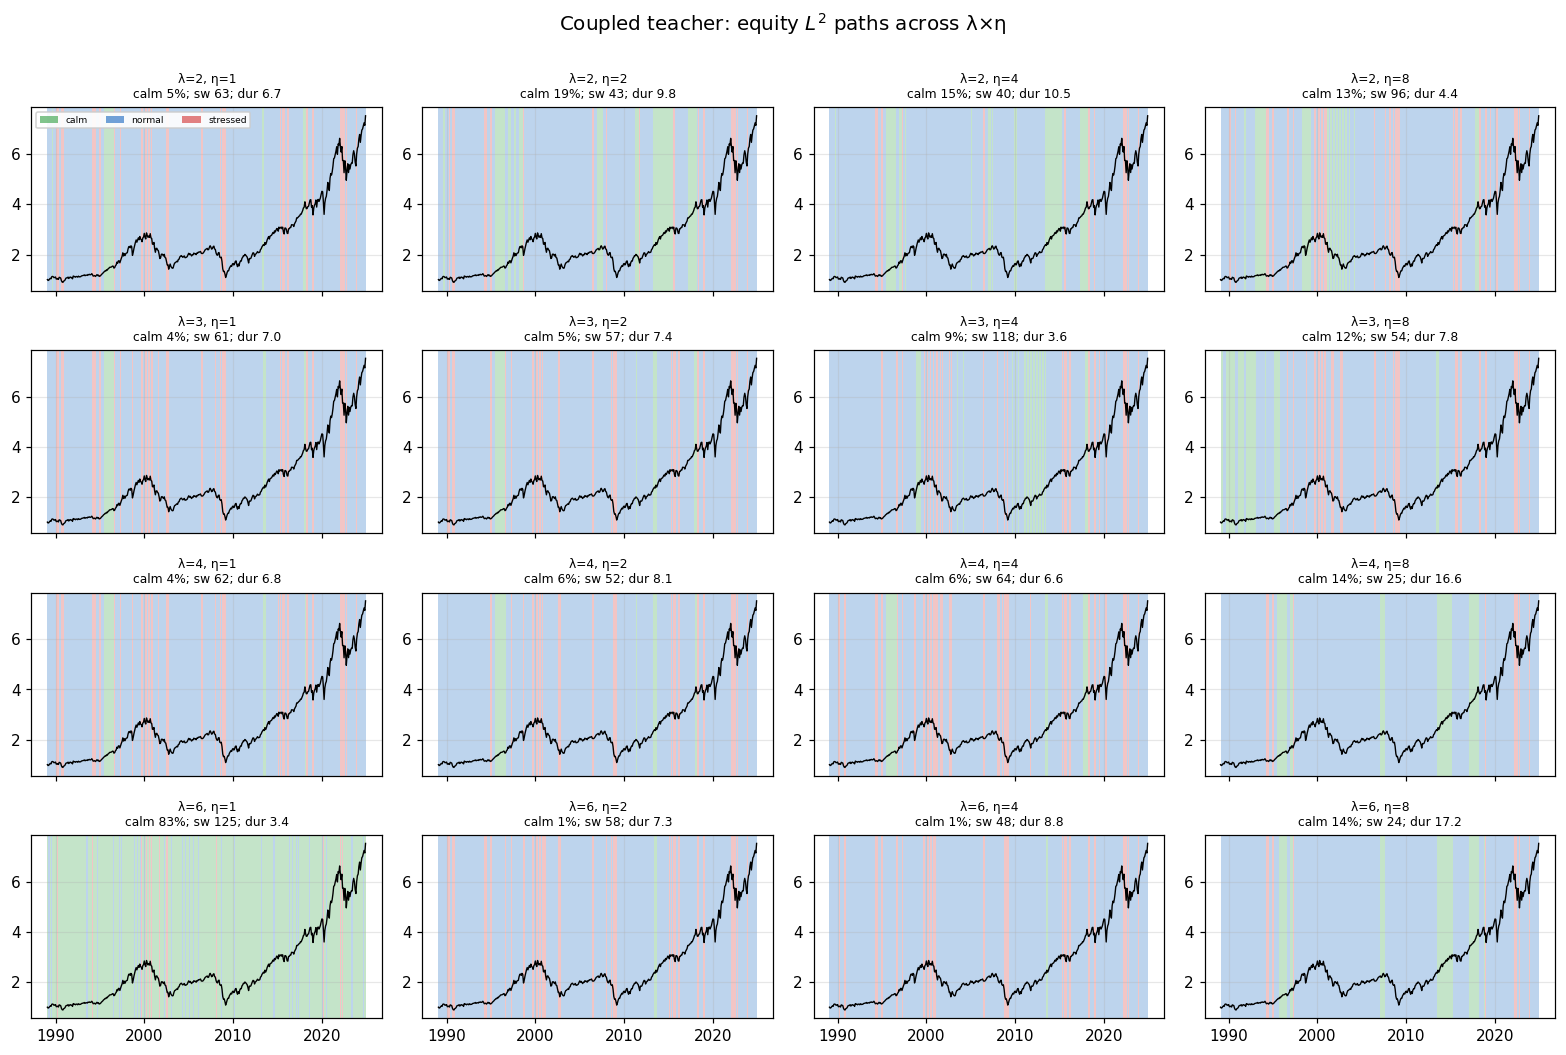

In [16]:
# ============================================================================
# CELL 15 — FIGURE: COUPLED__lambda_sweep_eq_l2  (4x4 lambda x eta grid)
# ============================================================================
import pickle
with open(NOTEBOOK_DIR / f"{PREFIX}lambda_eta_sweep_fitted.pkl", "rb") as f:
    LAM_RESULTS = pickle.load(f)["LAM_RESULTS"]
LAMBDA_GRID=sorted({k[1] for k in LAM_RESULTS}); ETA_GRID=sorted({k[2] for k in LAM_RESULTS})
_rows=[]
for (norm,lam,eta),df in LAM_RESULTS.items():
    lab=win(df)["regime"].values
    _rows.append({"norm":norm,"lambda":lam,"eta":eta,
        "calm":round(float((lab=="calm").mean()),3),"normal":round(float((lab=="normal").mean()),3),
        "stressed":round(float((lab=="stressed").mean()),3),"switches":n_sw(lab),"avg_dur":round(avg_dur(lab),1)})
LAM_SUMMARY=pd.DataFrame(_rows)
def lam_eta_grid_fig(norm,leg,tag,title):
    idxc="eq_idx" if leg=="eq" else "bd_idx"
    nr,nc=len(LAMBDA_GRID),len(ETA_GRID)
    fig,axes=plt.subplots(nr,nc,figsize=(3.6*nc,2.4*nr),sharex=True)
    for ri,lam in enumerate(LAMBDA_GRID):
        for ci,eta in enumerate(ETA_GRID):
            ax=axes[ri,ci]; df=disp(LAM_RESULTS[(norm,lam,eta)])
            if len(df): df[idxc]=df[idxc]/df[idxc].iloc[0]
            shade(ax,df["date"],df["regime"]); ax.plot(df["date"],df[idxc],color="black",lw=0.9,zorder=3)
            s=LAM_SUMMARY[(LAM_SUMMARY.norm==norm)&(LAM_SUMMARY["lambda"]==lam)&(LAM_SUMMARY.eta==eta)].iloc[0]
            ax.set_title(f"\u03bb={lam:g}, \u03b7={eta:g}\ncalm {s.calm:.0%}; sw {int(s.switches)}; dur {s.avg_dur:.1f}",fontsize=8)
            ax.margins(y=0.05); year_axis(ax,base=10)
    axes[0,0].legend(handles=regime_legend(),loc="upper left",ncol=3,fontsize=6,framealpha=0.9)
    fig.suptitle(title,y=0.997,fontsize=13); fig.tight_layout(); save_fig(fig,tag)
lam_eta_grid_fig("L2","eq","lambda_sweep_eq_l2","Coupled teacher: equity $L^2$ paths across \u03bb\u00d7\u03b7")

[saved] COUPLED__lambda_sweep_eq_l1.png / .pdf


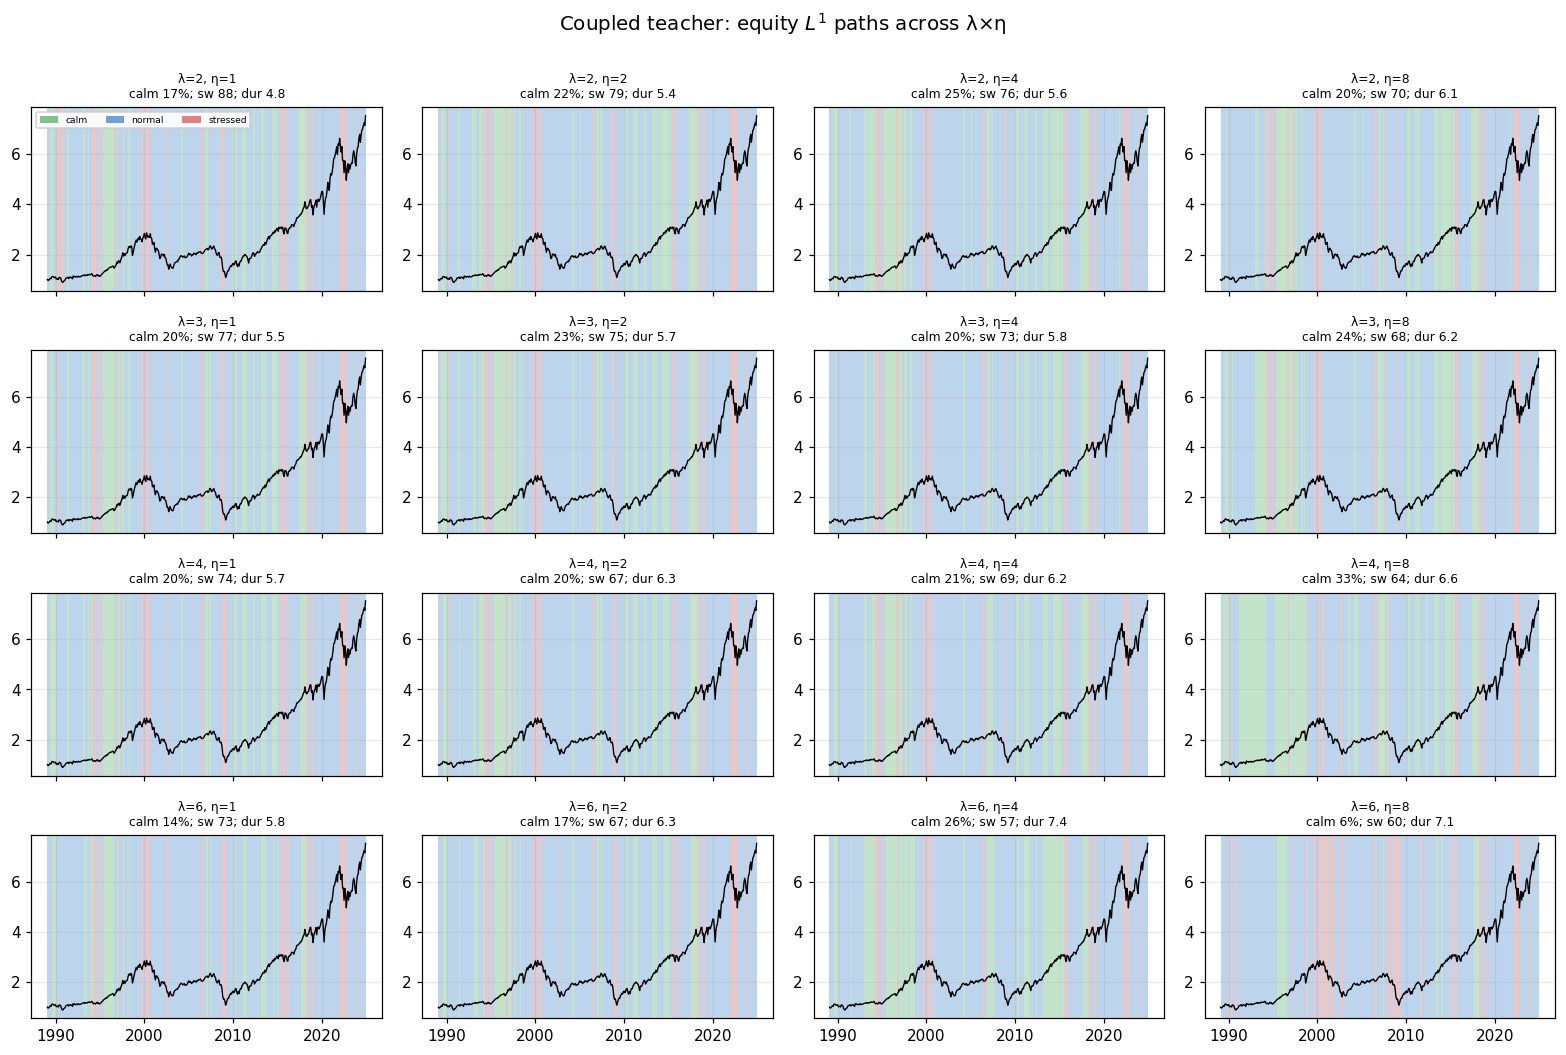

In [17]:
# ============================================================================
# CELL 16 — FIGURE: COUPLED__lambda_sweep_eq_l1  (equity L1 paths across lambda x eta)
# ============================================================================
lam_eta_grid_fig("L1","eq","lambda_sweep_eq_l1","Coupled teacher: equity $L^1$ paths across λ×η")

[saved] COUPLED__lambda_sweep_bd_l2.png / .pdf


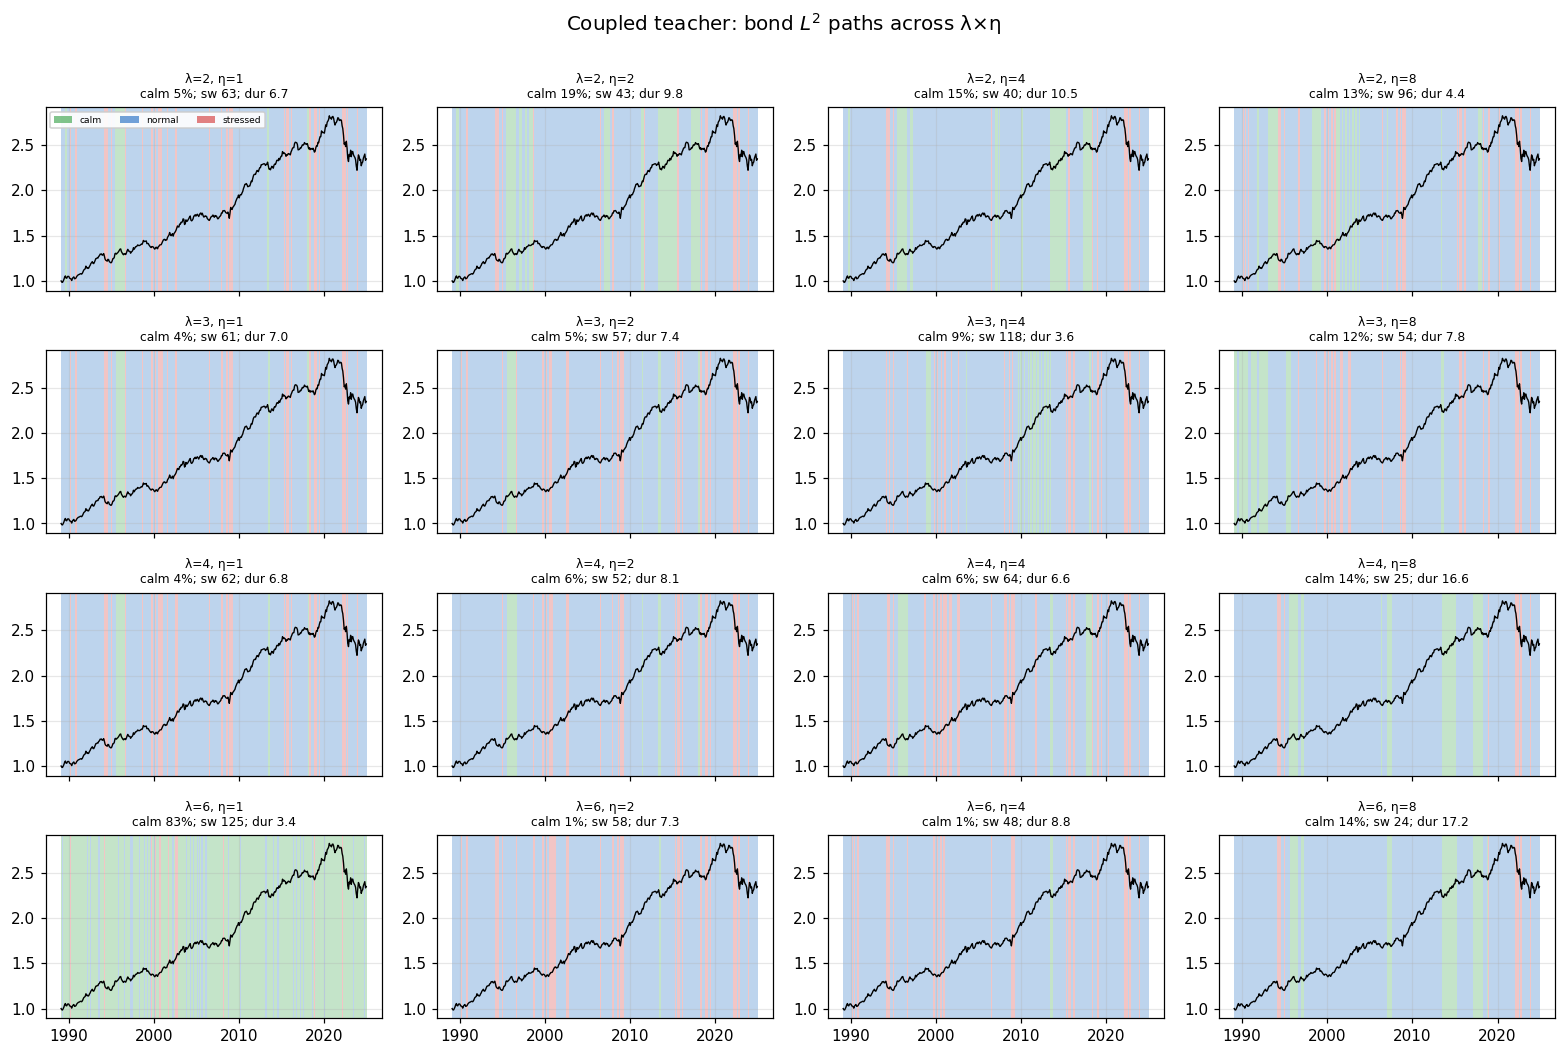

In [18]:
# ============================================================================
# CELL 17 — FIGURE: COUPLED__lambda_sweep_bd_l2  (bond L2 paths across lambda x eta)
# ============================================================================
lam_eta_grid_fig("L2","bd","lambda_sweep_bd_l2","Coupled teacher: bond $L^2$ paths across λ×η")

[saved] COUPLED__lambda_sweep_bd_l1.png / .pdf


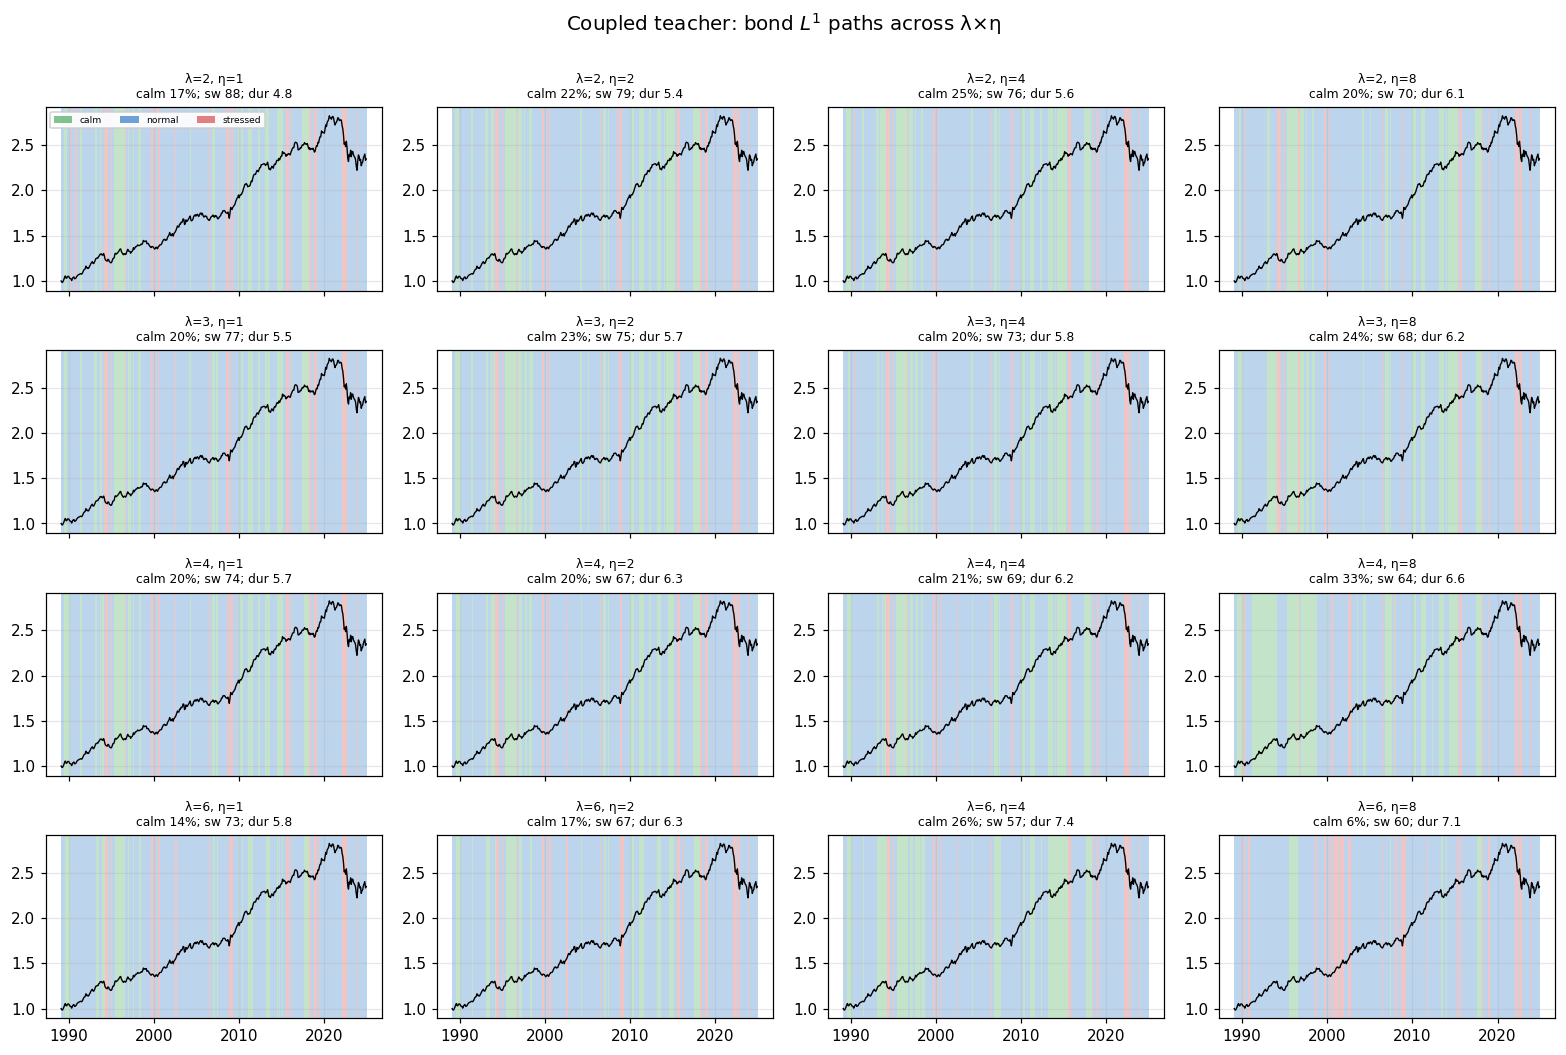

In [19]:
# ============================================================================
# CELL 18 — FIGURE: COUPLED__lambda_sweep_bd_l1  (bond L1 paths across lambda x eta)
# ============================================================================
lam_eta_grid_fig("L1","bd","lambda_sweep_bd_l1","Coupled teacher: bond $L^1$ paths across λ×η")

[saved] COUPLED__lambda_diag.png / .pdf


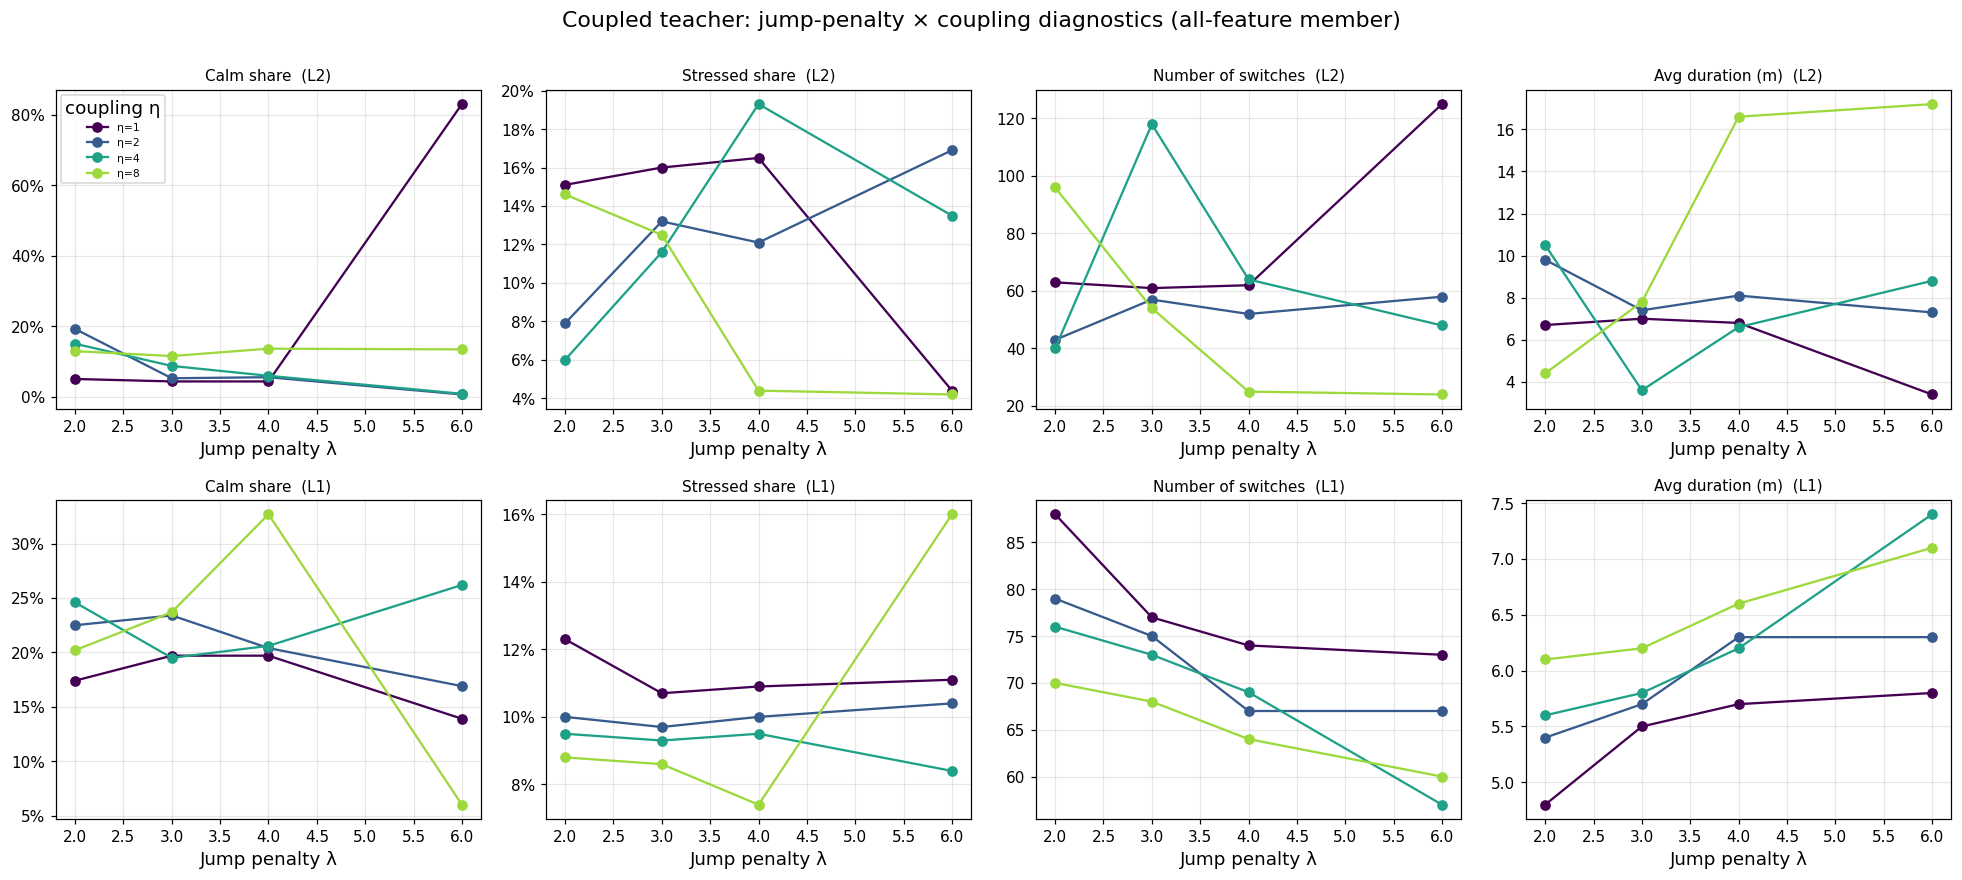

In [ ]:
# ============================================================================
# CELL 19 — FIGURE: COUPLED__lambda_diag  (joint-label diagnostics: shares/switches/duration vs lambda, eta lines, L2/L1 rows)
# ============================================================================
fig,axes=plt.subplots(2,4,figsize=(18,8))
# top row: L2 ; bottom row: L1 ;
panel_metrics=[("calm","Calm share"),("stressed","Stressed share"),
               ("switches","Number of switches"),("avg_dur","Avg duration (m)")]
eta_colors=plt.cm.viridis(np.linspace(0,0.85,len(ETA_GRID)))
for row,norm in enumerate(["L2","L1"]):
    for col,(m,t) in enumerate(panel_metrics):
        ax=axes[row,col]
        for ec,eta in zip(eta_colors,ETA_GRID):
            s=LAM_SUMMARY[(LAM_SUMMARY.norm==norm)&(LAM_SUMMARY.eta==eta)].sort_values("lambda")
            ax.plot(s["lambda"],s[m],"-o",color=ec,label=f"η={eta:g}")
        ax.set_xlabel("Jump penalty λ"); ax.set_title(f"{t}  ({norm})",fontsize=10)
        if m in ("calm","stressed"): yfmt_pct(ax)
        if row==0 and col==0: ax.legend(fontsize=7,title="coupling η")
fig.suptitle("Coupled teacher: jump-penalty × coupling diagnostics (all-feature member)",y=0.998)
fig.tight_layout(); save_fig(fig,"lambda_diag")

[saved] COUPLED__lambda_diag_eq.png / .pdf


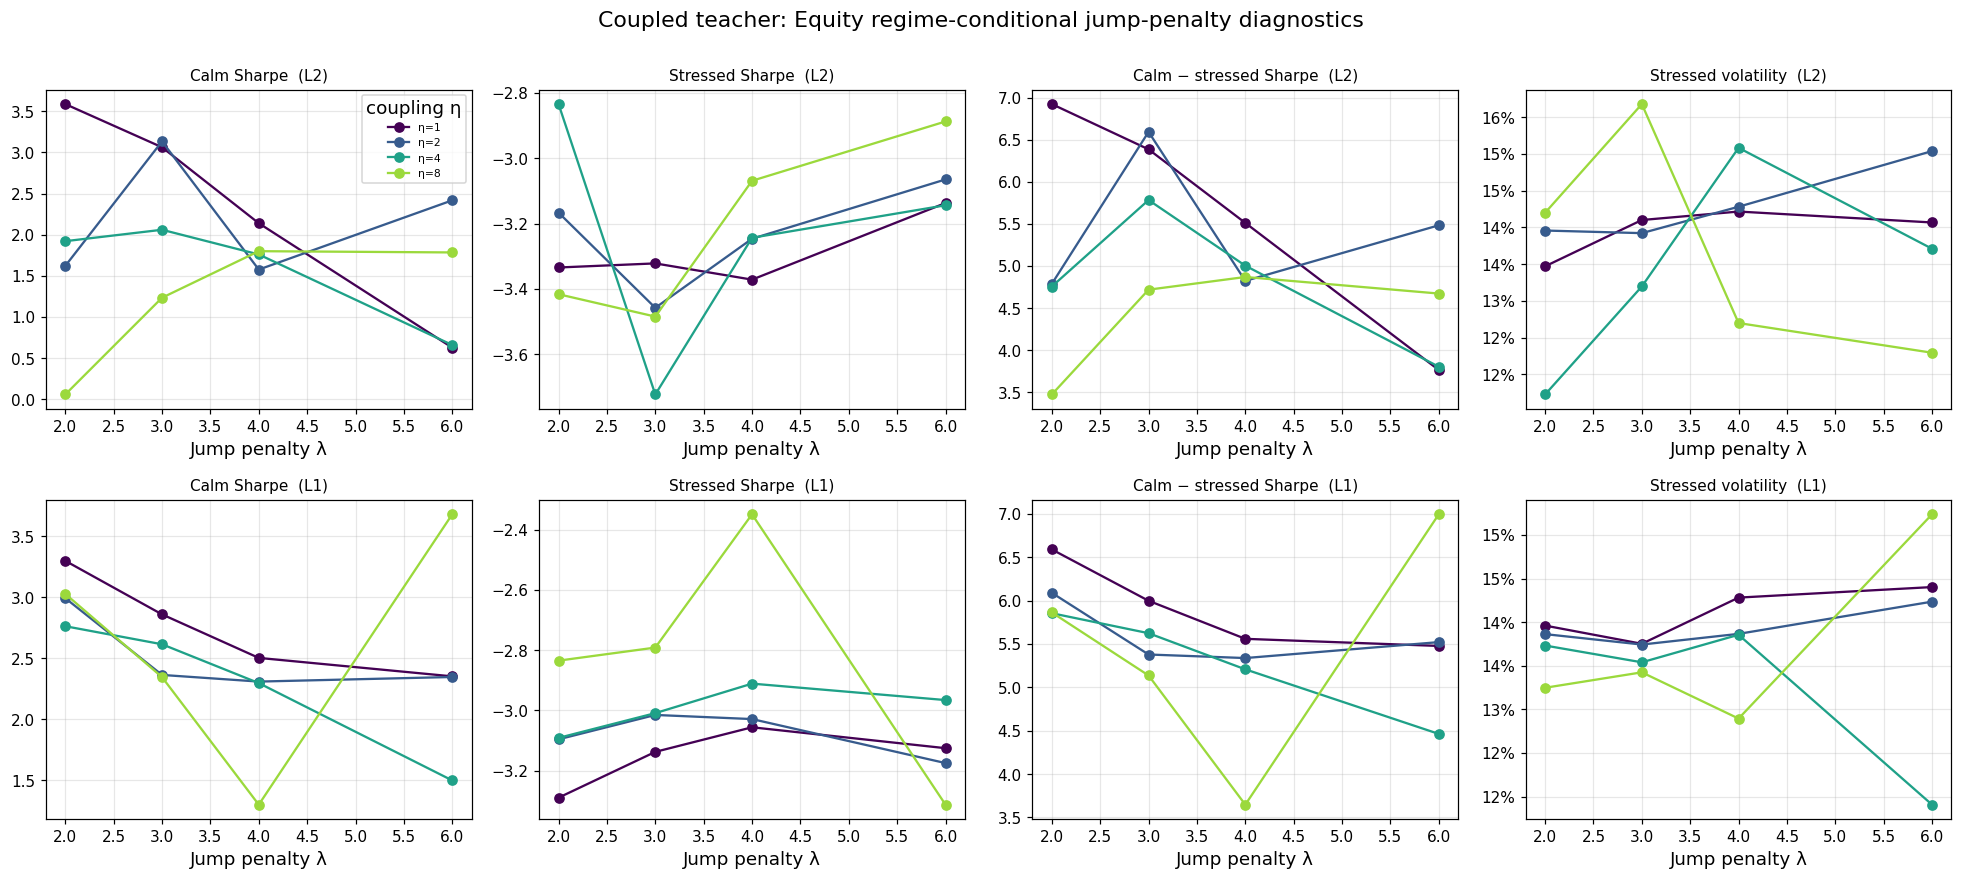

[saved] COUPLED__lambda_diag_bd.png / .pdf


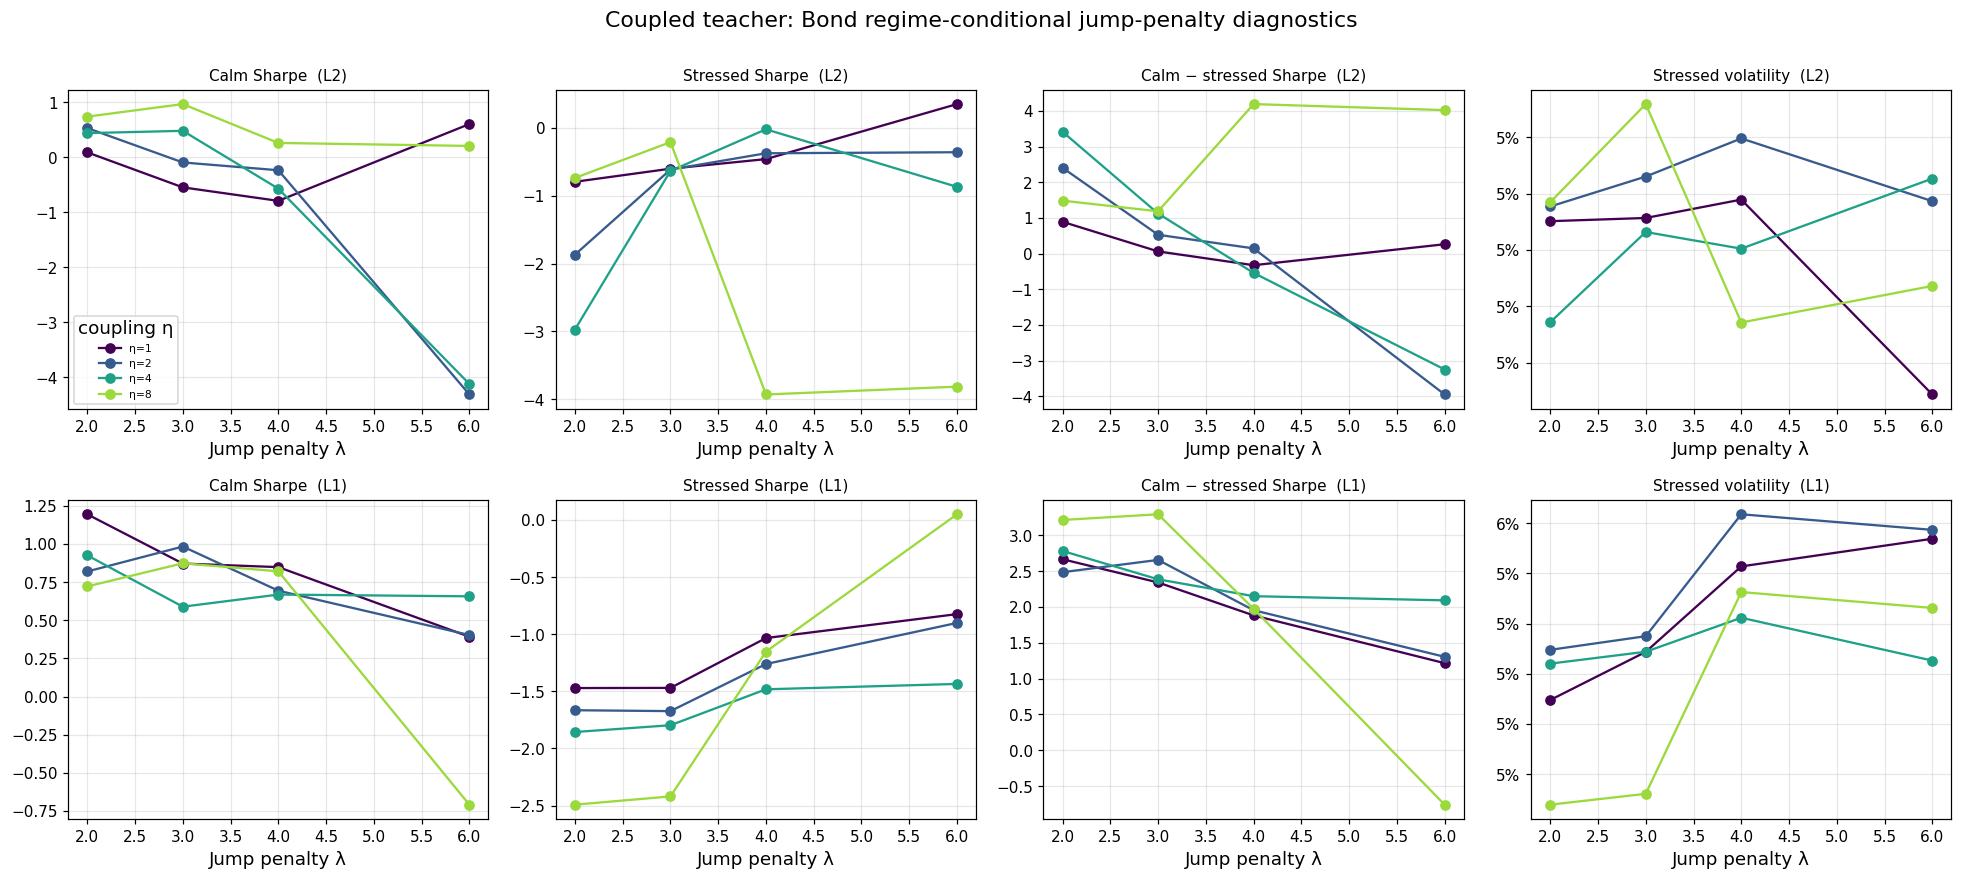

In [21]:
# ============================================================================
# CELL 19b — FIGURE: COUPLED__lambda_diag_eq / COUPLED__lambda_diag_bd
#            Per-leg regime-conditional jump-penalty diagnostics (calm/normal/
#            stressed). Separate equity & bond figures. eta = lines, lambda = x
# ============================================================================
def leg_lambda_econ(leg):
    recs = []
    for (norm, lam, eta), df in LAM_RESULTS.items():
        m = df[["date", "regime"]].merge(RET[["date", leg]], on="date", how="left")
        m = win(m).dropna(subset=[leg])
        d = {"norm": norm, "lambda": lam, "eta": eta}
        for c in LABEL_CLASSES:
            r = m.loc[m.regime == c, leg]
            d[f"sr_{c}"] = ann_sr(r); d[f"vol_{c}"] = ann_vol(r)
        d["sr_spread"] = d["sr_calm"] - d["sr_stressed"]
        recs.append(d)
    return pd.DataFrame(recs)

for leg, tag, title in [("eqx", "eq", "Equity"), ("bdx", "bd", "Bond")]:
    E = leg_lambda_econ(leg)
    panel = [("sr_calm", "Calm Sharpe"), ("sr_stressed", "Stressed Sharpe"),
             ("sr_spread", "Calm \u2212 stressed Sharpe"), ("vol_stressed", "Stressed volatility")]
    eta_colors = plt.cm.viridis(np.linspace(0, 0.85, len(ETA_GRID)))
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    for row, norm in enumerate(["L2", "L1"]):
        for col, (mcol, t) in enumerate(panel):
            ax = axes[row, col]
            for ec, eta in zip(eta_colors, ETA_GRID):
                s = E[(E.norm == norm) & (E.eta == eta)].sort_values("lambda")
                ax.plot(s["lambda"], s[mcol], "-o", color=ec, label=f"\u03b7={eta:g}")
            ax.set_xlabel("Jump penalty \u03bb"); ax.set_title(f"{t}  ({norm})", fontsize=10)
            if mcol == "vol_stressed": yfmt_pct(ax)
            if row == 0 and col == 0: ax.legend(fontsize=7, title="coupling \u03b7")
    fig.suptitle(f"Coupled teacher: {title} regime-conditional jump-penalty diagnostics", y=0.998)
    fig.tight_layout(); save_fig(fig, f"lambda_diag_{tag}")

In [ ]:
# ============================================================================
# CELL 20 — student walk-forward
#   Coupled 3-state target. RF averaged over seeds {101,111,121}; logit fit once
#   (lbfgs deterministic). Outputs probs/preds/regime/returns + importances.
#   OOS 1996-02 ->.  Labels clipped to LABEL_START (1989-01) via win()
# ============================================================================
import warnings; warnings.filterwarnings("ignore")

cls_to_int={c:i for i,c in enumerate(LABEL_CLASSES)}; nK=3
TRAIN_MONTHS,VALID_MONTHS,BLOCK=132,60,6
MACRO_LAG=1
SEEDS=[101,111,121]
OOS_START = pd.Timestamp("1996-02-01")
ALLOC_END = pd.Timestamp("2024-10-31")

b=panel_raw[["date","sprtrn_sp500","agg_ret","rf"]].copy()
for c in ["sprtrn_sp500","agg_ret","rf"]: b[c]=pd.to_numeric(b[c],errors="coerce").astype(float)
b["eqx"]=b["sprtrn_sp500"]-b["rf"]; b["bdx"]=b["agg_ret"]-b["rf"]
fwd=b[["date"]].copy()
fwd["eq_tot_next"]=b["sprtrn_sp500"].shift(-1); fwd["bd_tot_next"]=b["agg_ret"].shift(-1); fwd["rf_tot_next"]=b["rf"].shift(-1)
_pr=panel_raw.copy()
for c in _pr.columns:
    if c!="date": _pr[c]=pd.to_numeric(_pr[c],errors="coerce")
_EXCL={"sprtrn_sp500","agg_ret","rf","vwretd","bond_10y_ret","mktrf","smb","hml","rv_20d","rv_60d","VIXCLSx","S&P 500"}
def _is_cand(col):
    if col=="date" or col in _EXCL: return False
    lc=col.lower(); return not ("fwd" in lc or "label" in lc)
_RAW=[c for c in _pr.columns if _is_cand(c)]
macro=pd.concat([_pr["date"]]+[_pr[c].shift(MACRO_LAG).rename(c) for c in _RAW],axis=1)
MACRO_CAND=[c for c in _RAW if macro[c].notna().any()]
print(f"[pool] macro candidates after leakage screen: {len(MACRO_CAND)}")

elig=(win(LBL)[["date","regime"]].dropna().merge(b[["date","eqx","bdx"]],on="date",how="inner")
      .merge(macro[["date"]+MACRO_CAND],on="date",how="inner").merge(fwd,on="date",how="inner")
      .sort_values("date").reset_index(drop=True))
elig["target_next_regime"]=elig["regime"].shift(-1)
elig=elig.dropna(subset=["target_next_regime","eqx","bdx","eq_tot_next","bd_tot_next","rf_tot_next"]).reset_index(drop=True)
elig=elig[elig["date"]<=ALLOC_END].reset_index(drop=True)
for c in LABEL_CLASSES: elig[f"cur_{c}"]=(elig["regime"]==c).astype(float)
_rl=np.ones(len(elig))
for i in range(1,len(elig)): _rl[i]=_rl[i-1]+1 if elig["regime"].iloc[i]==elig["regime"].iloc[i-1] else 1.0
elig["regime_runlen"]=_rl
CONTEXT_COLS=[f"cur_{c}" for c in LABEL_CLASSES]+["regime_runlen"]

start_idx=int(np.searchsorted(elig["date"].values,np.datetime64(OOS_START)))
print(f"[panel] eligible months: {len(elig)} ({elig.date.min().date()} -> {elig.date.max().date()})")
print(f"[anchor] OOS starts at idx {start_idx} = {elig['date'].iloc[start_idx].date()} "
      f"| TOP_K_MACRO={TOP_K_MACRO} + {len(CONTEXT_COLS)} context | seeds={SEEDS}")
# verify: first walk-forward window that reaches the full 132-month training width
_full=next((s for s in range(start_idx,len(elig),BLOCK) if s-VALID_MONTHS-TRAIN_MONTHS>=0),None)
if _full is not None:
    print(f"[full-train] first full-132 OOS month = {elig['date'].iloc[_full].date()} "
          f"(expanding train before this; 132/60/6 fixed after)")

def causal_topk(Dtrain,cand,K):
    feats=Dtrain[cand]; score=None
    for c in LABEL_CLASSES:
        ind=pd.Series((Dtrain["target_next_regime"].values==c).astype(float),index=Dtrain.index)
        cc=feats.corrwith(ind).abs(); score=cc if score is None else np.maximum(score,cc)
    score=score.fillna(0.0).sort_values(ascending=False); return score.head(K).index.tolist(),score

RF_GRID=[{"n_estimators":300,"max_depth":4,"min_samples_leaf":5},
         {"n_estimators":400,"max_depth":6,"min_samples_leaf":3}]
LOGIT_GRID=[0.03,0.1,0.3,1.0]
def _bal_acc(yt,yp):
    rec=[((yp==c)&(yt==c)).sum()/max((yt==c).sum(),1) for c in range(nK) if (yt==c).any()]
    return float(np.mean(rec)) if rec else 0.0
def _densify(pr,uniq):
    full=np.zeros((len(pr),nK))
    for di,c in enumerate(uniq): full[:,int(c)]=pr[:,di]
    return full
def fit_per_model(X_tr,y_tr,X_va,y_va):
    uniq=sorted(np.unique(y_tr).tolist())
    if len(uniq)<2:
        const=np.zeros(nK); const[uniq[0]]=1.0; _c=lambda X:np.tile(const,(len(X),1))
        return {"RF":{"f":_c,"imp":None,"param":"const"},"Logit":{"f":_c,"imp":None,"param":"const"}}
    dense={c:i for i,c in enumerate(uniq)}; y_d=np.array([dense[c] for c in y_tr])
    scaler=StandardScaler().fit(X_tr); Xtr_s,Xva_s=scaler.transform(X_tr),scaler.transform(X_va)
    best=None
    for p in RF_GRID:
        models=[RandomForestClassifier(random_state=sd,class_weight="balanced_subsample",n_jobs=1,**p).fit(X_tr,y_d) for sd in SEEDS]
        Pva=np.mean([m.predict_proba(X_va) for m in models],axis=0)
        a=_bal_acc(y_va,_densify(Pva,uniq).argmax(1))
        if best is None or a>best[0]: best=(a,p,models)
    _,brp,rf_models=best
    def rf_predict(X,models=rf_models,u=uniq):
        return _densify(np.mean([m.predict_proba(X) for m in models],axis=0),u)
    rf_imp=np.mean([m.feature_importances_ for m in rf_models],axis=0)
    bl,bla,blc=None,-np.inf,None
    for C in LOGIT_GRID:
        m=LogisticRegression(C=C,class_weight="balanced",max_iter=2000,solver="lbfgs").fit(Xtr_s,y_d)
        a=_bal_acc(y_va,_densify(m.predict_proba(Xva_s),uniq).argmax(1))
        if a>bla: bla,bl,blc=a,m,C
    def lg_predict(X,m=bl,s=scaler,u=uniq):
        return _densify(m.predict_proba(s.transform(X)),u)
    return {"RF":{"f":rf_predict,"imp":rf_imp,"param":f"d={brp['max_depth']},leaf={brp['min_samples_leaf']},n={brp['n_estimators']}"},
            "Logit":{"f":lg_predict,"imp":np.abs(bl.coef_).mean(0),"param":f"C={blc}"}}

hist_all=b[["date","eqx","bdx"]].merge(win(LBL)[["date","regime"]],on="date",how="left")

rows=[]; imp_acc={"RF":{},"Logit":{}}; sel_param={"RF":[],"Logit":[]}
_sel_freq={f:0 for f in MACRO_CAND}; _nw=0; _min_train=10**9
for s in range(start_idx,len(elig),BLOCK):
    lo=max(0,s-VALID_MONTHS-TRAIN_MONTHS)
    tr=elig.iloc[lo:s-VALID_MONTHS]; va=elig.iloc[s-VALID_MONTHS:s]; te=elig.iloc[s:s+BLOCK]
    if not (len(tr) and len(va) and len(te)): continue
    _min_train=min(_min_train,len(tr))
    sel_macro,_=causal_topk(elig.iloc[:s],MACRO_CAND,TOP_K_MACRO)
    for f in sel_macro: _sel_freq[f]+=1
    _nw+=1; fc=sel_macro+CONTEXT_COLS
    med=tr[fc].median().fillna(0.0)
    Xtr=tr[fc].fillna(med).values.astype(float); Xva=va[fc].fillna(med).values.astype(float); Xte=te[fc].fillna(med).values.astype(float)
    ytr=np.array([cls_to_int[c] for c in tr["target_next_regime"]]); yva=np.array([cls_to_int[c] for c in va["target_next_regime"]])
    pm=fit_per_model(Xtr,ytr,Xva,yva); P={k:pm[k]["f"](Xte) for k in ("RF","Logit")}
    for mk in ("RF","Logit"):
        sel_param[mk].append(pm[mk]["param"])
        if pm[mk]["imp"] is not None:
            for fn,iv in zip(fc,pm[mk]["imp"]): imp_acc[mk].setdefault(fn,[]).append(float(iv))
    for j,(_,r) in enumerate(te.iterrows()):
        row={"date":r["date"],"regime":r["regime"],"target_next_regime":r["target_next_regime"],
             "eq_tot_next":float(r["eq_tot_next"]),"bd_tot_next":float(r["bd_tot_next"]),"rf_tot_next":float(r["rf_tot_next"])}
        for mk in ("RF","Logit"):
            Pm=P[mk][j]; row[f"pred_{mk}"]=LABEL_CLASSES[int(Pm.argmax())]
            for i,c in enumerate(LABEL_CLASSES): row[f"p_{mk}_{c}"]=float(Pm[i])
        rows.append(row)
W=pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
_nw=max(_nw,1)
macro_selection_frequency=(pd.DataFrame({"feature":list(_sel_freq.keys()),
    "selected_frac_of_windows":[v/_nw for v in _sel_freq.values()]})
    .sort_values("selected_frac_of_windows",ascending=False).reset_index(drop=True))
yt=W["target_next_regime"].values
print("CELL 20 OK — student OOS:",W.date.min().date(),"->",W.date.max().date(),f"({len(W)} months)")
print(f"  first-window train size = {_min_train} (clipped from {TRAIN_MONTHS}; stabilises at {TRAIN_MONTHS})")
print("  next-regime acc : RF %.3f | Logit %.3f | Naive %.3f"%(
      (W.pred_RF.values==yt).mean(),(W.pred_Logit.values==yt).mean(),(W.regime.values==yt).mean()))

[pool] macro candidates after leakage screen: 207
[panel] eligible months: 430 (1989-01-31 -> 2024-10-31)
[anchor] OOS starts at idx 85 = 1996-02-29 | TOP_K_MACRO=5 + 4 context | seeds=[101, 111, 121]
[full-train] first full-132 OOS month = 2005-02-28 (expanding train before this; 132/60/6 fixed after)
CELL 20 OK — student OOS: 1996-02-29 -> 2024-10-31 (345 months)
  first-window train size = 25 (clipped from 132; stabilises at 132)
  next-regime acc : RF 0.736 | Logit 0.678 | Naive 0.855


In [23]:
# ============================================================================
# CELL 20b — PERSIST student walk-forward outputs.
# ============================================================================
import pickle
with open(NOTEBOOK_DIR / f"{PREFIX}student_fitted.pkl", "wb") as f:
    pickle.dump({"W": W, "imp_acc": imp_acc, "sel_param": sel_param,
                 "elig_cols": list(elig.columns)}, f)
W.to_csv(NOTEBOOK_DIR / f"{PREFIX}student_walkforward.csv", index=False)
print(f"[saved] {PREFIX}student_fitted.pkl  +  {PREFIX}student_walkforward.csv  ({len(W)} months)")

[saved] COUPLED__student_fitted.pkl  +  COUPLED__student_walkforward.csv  (345 months)


In [24]:
# ============================================================================
# CELL 21 — TABLE: COUPLED__forecast_quality  (Table 4 coupled panel)
# ============================================================================
yt=W["target_next_regime"].values; trm=W["regime"].values!=yt; ss=yt=="stressed"; rows=[]
for mk in ("RF","Logit"):
    yp=W[f"pred_{mk}"].values
    rows.append({"Model":("Random forest" if mk=="RF" else "Logistic regression"),
        "Next-regime acc":round((yp==yt).mean(),3),
        "Transition acc":round((yp[trm]==yt[trm]).mean(),3) if trm.any() else np.nan,
        "Stressed recall":round((yp[ss]=="stressed").mean(),3) if ss.any() else np.nan})
rows.append({"Model":"Naive (persistence)","Next-regime acc":round((W.regime.values==yt).mean(),3),
             "Transition acc":0.0,"Stressed recall":np.nan})
save_tbl(pd.DataFrame(rows),"forecast_quality",ff="%.3f")

[saved] COUPLED__forecast_quality.csv / .tex


,Model,Next-regime acc,Transition acc,Stressed recall
0,Random forest,0.736,0.32,0.424
1,Logistic regression,0.678,0.16,0.606
2,Naive (persistence),0.855,0.00,NaN


In [25]:
# ============================================================================
# CELL 22 — TABLE: COUPLED__accuracy_brier  (Table 5)
# ============================================================================
yt=W["target_next_regime"].values; yi=np.array([cls_to_int[c] for c in yt]); rows=[]
for mk in ("Logit","RF"):
    P=W[[f"p_{mk}_{c}" for c in LABEL_CLASSES]].values; yp=P.argmax(1)
    acc=(yp==yi).mean(); ba=_bal_acc(yi,yp); Y=np.eye(nK)[yi]
    brier=float(((P-Y)**2).sum(1).mean()); ll=float(-np.mean(np.log(np.clip(P[np.arange(len(yi)),yi],1e-12,1))))
    aucs=[]
    for c in range(nK):
        yb=(yi==c).astype(int); sc=P[:,c]; pos,neg=sc[yb==1],sc[yb==0]
        if len(pos) and len(neg):
            aucs.append(float(((pos[:,None]>neg[None,:]).sum()+0.5*(pos[:,None]==neg[None,:]).sum())/(len(pos)*len(neg))))
    rows.append({"Model":("Logistic regression" if mk=="Logit" else "Random forest"),
        "Accuracy":round(acc,3),"Balanced acc.":round(ba,3),"AUC (macro OVR)":round(float(np.mean(aucs)),3),
        "Brier":round(brier,3),"Log loss":round(ll,3)})
save_tbl(pd.DataFrame(rows),"accuracy_brier",ff="%.3f")

[saved] COUPLED__accuracy_brier.csv / .tex


,Model,Accuracy,Balanced acc.,AUC (macro OVR),Brier,Log loss
0,Logistic regression,0.678,0.546,0.649,0.515,1.188
1,Random forest,0.736,0.479,0.648,0.398,0.938


[saved] COUPLED__pred_probabilities.png / .pdf


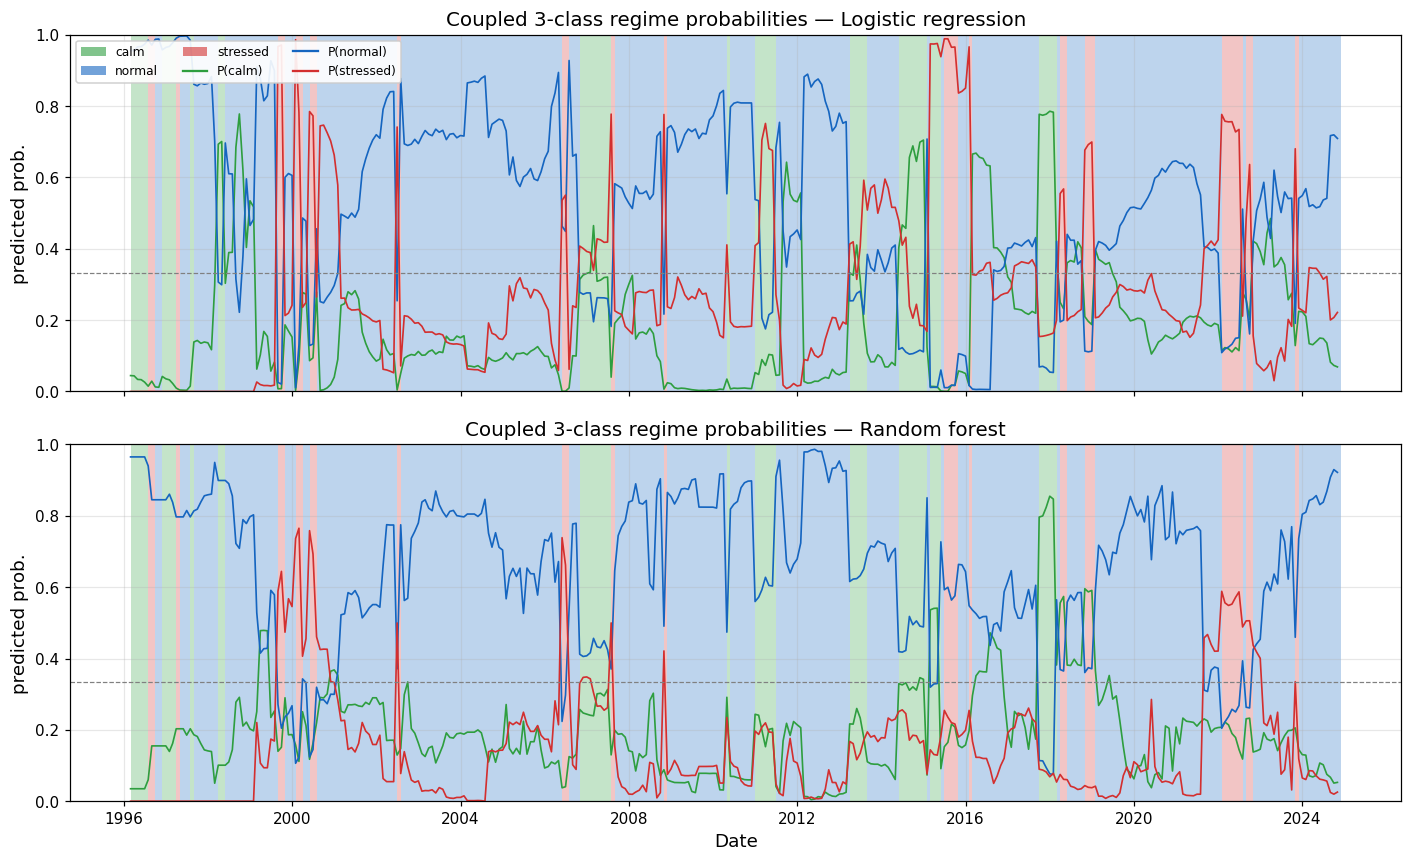

In [26]:
# ============================================================================
# CELL 23 — FIGURE: COUPLED__pred_probabilities  (Fig 4)
# ============================================================================
fig,axes=plt.subplots(2,1,figsize=(13,8),sharex=True)
for ax,mk in zip(axes,["Logit","RF"]):
    shade(ax,W["date"],W["regime"])
    for c in LABEL_CLASSES: ax.plot(W["date"],W[f"p_{mk}_{c}"],lw=1.1,color=LINE_COLORS[c],label=f"P({c})")
    ax.axhline(1/3,color="grey",ls="--",lw=0.8); ax.set_ylim(0,1); ax.set_ylabel("predicted prob.")
    ax.set_title(f"Coupled 3-class regime probabilities — {'Logistic regression' if mk=='Logit' else 'Random forest'}")
h2=[plt.Line2D([0],[0],color=LINE_COLORS[c],lw=1.5,label=f"P({c})") for c in LABEL_CLASSES]
axes[0].legend(handles=regime_legend()+h2,loc="upper left",ncol=3,fontsize=8,framealpha=0.9)
year_axis(axes[1],base=4); axes[1].set_xlabel("Date")
fig.tight_layout(); save_fig(fig,"pred_probabilities")

[saved] COUPLED__feature_block_importance.png / .pdf


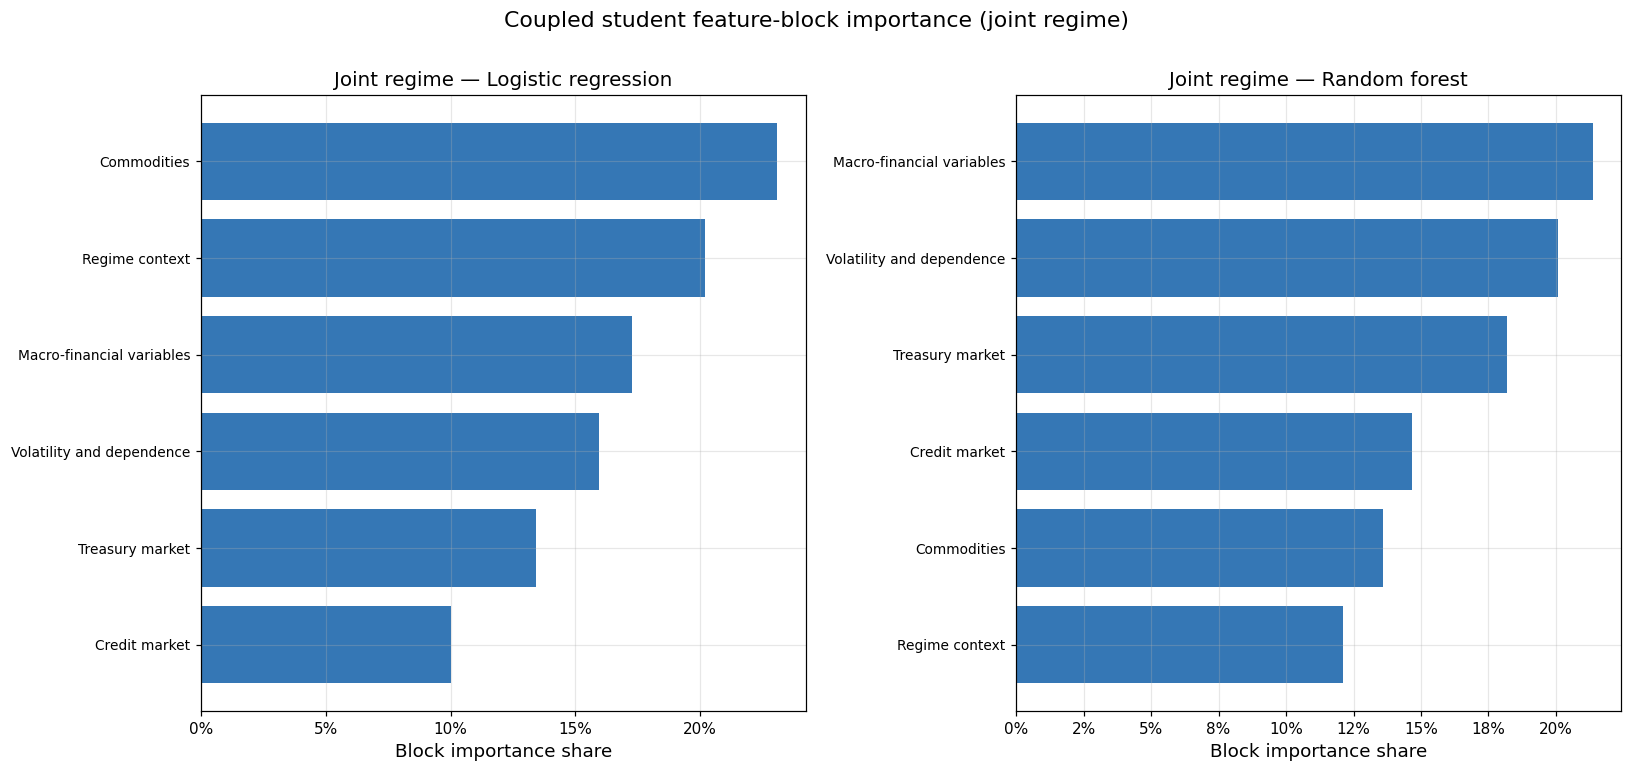

In [27]:
# ============================================================================
# CELL 24 — FIGURE: COUPLED__feature_block_importance  (sorted; Fig 6)
# ============================================================================
def block_of(col):
    c=col.lower()
    if col.startswith("cur_") or col=="regime_runlen": return "Regime context"
    if any(k in c for k in ["vix","rv_","_vol_","rho","corr","lambda","drawdown"]): return "Volatility and dependence"
    if any(k in c for k in ["baa","aaa","credit","spread","hy_","_ig"]): return "Credit market"
    if any(k in c for k in ["gold","silver","oil","brent","wheat","soybean","cmdty","commodity"]): return "Commodities"
    if any(k in c for k in ["nfci","anfci"]): return "Financial conditions"
    if any(k in c for k in ["dgs","raw_y","derived_y","slope","curve","term_spread","gs10","gs1","gs3","gs5","gs7","tb3ms","fedfunds","t10y","t5y","belly","bond_10y"]): return "Treasury market"
    if any(k in c for k in ["hml","smb","mktrf","ff_","factor","vwretd","s&p","growth"]): return "Equity cross-section"
    if any(k in c for k in ["ind12","industry","style","smlo","smme","smhi"]): return "Industry and style portfolios"
    return "Macro-financial variables"
def block_imp(mk):
    agg={}
    for fn,vals in imp_acc[mk].items(): agg.setdefault(block_of(fn),[]).extend(vals)
    s=pd.Series({k:np.mean(v) for k,v in agg.items()}); return (s/s.sum()).sort_values(ascending=False)
fig,axes=plt.subplots(1,2,figsize=(15,7))
for ax,mk in zip(axes,["Logit","RF"]):
    s=block_imp(mk).iloc[::-1]; ax.barh(range(len(s)),s.values,color="#3577b5")
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index,fontsize=9)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{x:.0%}")); ax.set_xlabel("Block importance share")
    ax.set_title(f"Joint regime — {'Logistic regression' if mk=='Logit' else 'Random forest'}")
fig.suptitle("Coupled student feature-block importance (joint regime)",y=1.0)
fig.tight_layout(); save_fig(fig,"feature_block_importance")

[saved] COUPLED__individual_predictor_importance.png / .pdf


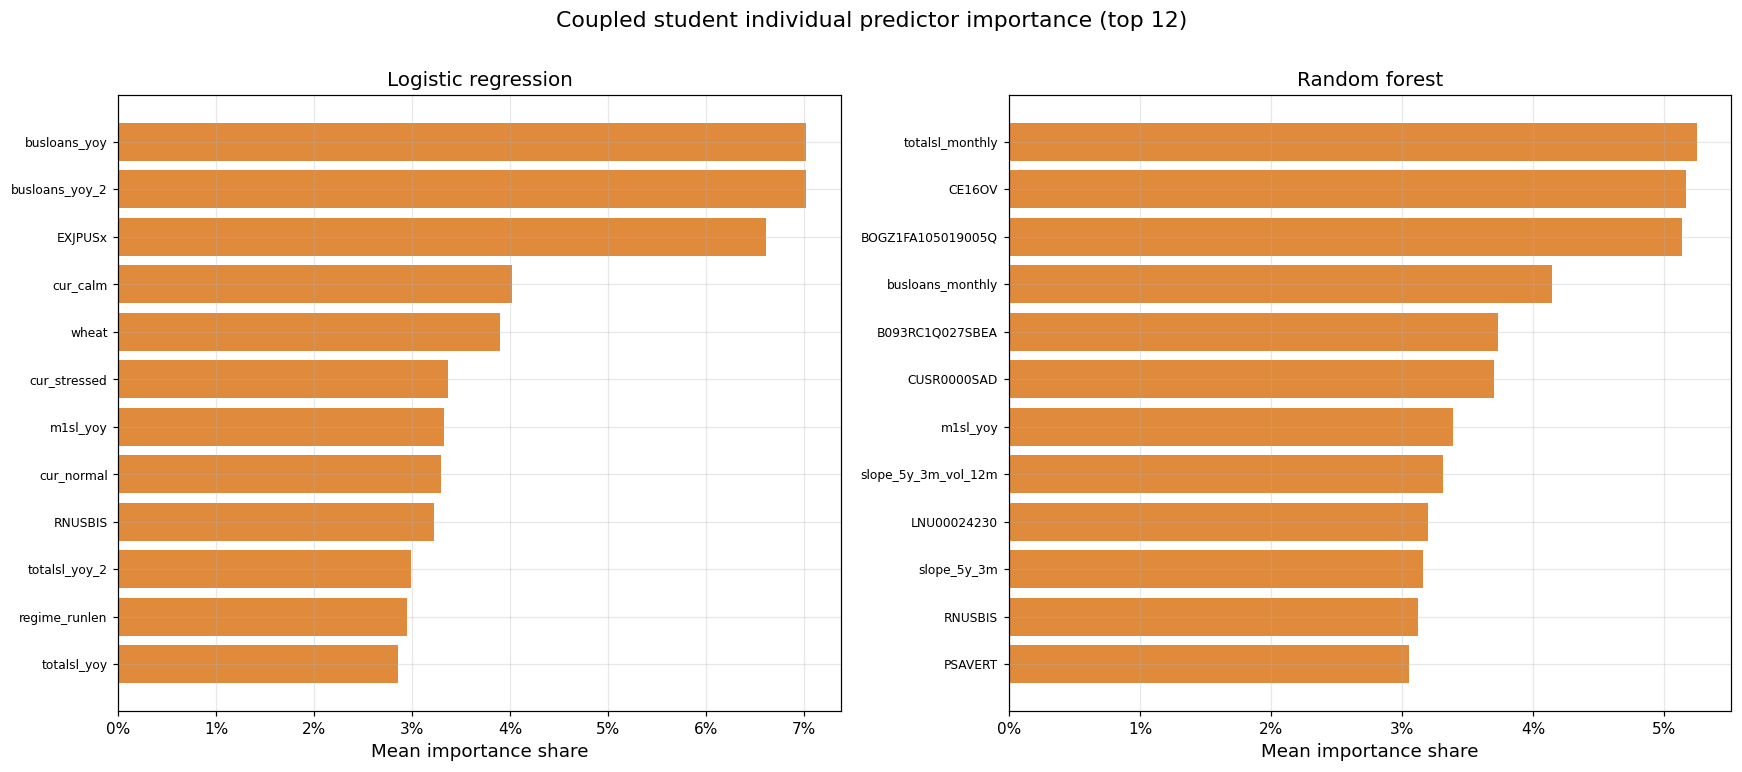

In [28]:
# ============================================================================
# CELL 25 — FIGURE: COUPLED__individual_predictor_importance  (top-12; Fig F.27)
# ============================================================================
fig,axes=plt.subplots(1,2,figsize=(16,7))
for ax,mk in zip(axes,["Logit","RF"]):
    s=pd.Series({fn:np.mean(v) for fn,v in imp_acc[mk].items()})
    s=(s/s.sum()).sort_values(ascending=False).head(12).iloc[::-1]
    ax.barh(range(len(s)),s.values,color="#e08a3c"); ax.set_yticks(range(len(s)))
    ax.set_yticklabels([f.replace("derived_","").replace("_wrds","") for f in s.index],fontsize=8)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f"{x:.0%}")); ax.set_xlabel("Mean importance share")
    ax.set_title(f"{'Logistic regression' if mk=='Logit' else 'Random forest'}")
fig.suptitle("Coupled student individual predictor importance (top 12)",y=1.0)
fig.tight_layout(); save_fig(fig,"individual_predictor_importance")

In [29]:
# ============================================================================
# CELL 26 — TABLE: COUPLED__selected_model_frequency  (Table F.21 analogue)
# ============================================================================
rows=[]
for mk in ("Logit","RF"):
    vc=pd.Series(sel_param[mk]).value_counts()
    rows.append({"Model":("Logistic regression" if mk=="Logit" else "Random forest"),
        "Most frequent setting":vc.index[0],"Selection share":f"{vc.iloc[0]/len(sel_param[mk]):.1%}",
        "OOS windows":len(sel_param[mk])})
save_tbl(pd.DataFrame(rows),"selected_model_frequency")

[saved] COUPLED__selected_model_frequency.csv / .tex


,Model,Most frequent setting,Selection share,OOS windows
0,Logistic regression,C=0.03,74.1%,58
1,Random forest,"d=4,leaf=5,n=300",77.6%,58


In [30]:
# ============================================================================
# CELL 27 — COUPLED allocation
# ============================================================================

MOMENT_SHRINKAGE_K = 36.0
WEIGHT_STEP        = 0.02
MAX_EQUITY_WEIGHT  = 1.0; MAX_BOND_WEIGHT = 1.0; MAX_TOTAL_RISKY = 1.0
GAMMA_GRID  = [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0]
TAU_GRID    = [0.0, 1.0, 3.0, 5.0]
TCOST_GRID  = [0.0005, 0.0010, 0.0025, 0.0050]
SMOOTH_GRID = [0, 3, 6]
ALLOC_BUDGET = "cash_allowed"

HEADLINE_COST = 0.0010
WC = {"eq": "#1f77b4", "bd": "#ff7f0e", "cash": "#cfcfcf"}

def make_weight_grid(budget):
    g = np.round(np.arange(0.0, 1.0 + 0.5*WEIGHT_STEP, WEIGHT_STEP), 4); rows=[]
    for we in g:
        for wb in g:
            tot=we+wb
            keep=(abs(tot-1.0)<=0.5*WEIGHT_STEP+1e-10) if budget=="fully_invested" else (tot<=MAX_TOTAL_RISKY+EPS)
            if keep and we<=MAX_EQUITY_WEIGHT+EPS and wb<=MAX_BOND_WEIGHT+EPS: rows.append((float(we),float(wb)))
    return np.asarray(rows,float)
WGRID = make_weight_grid(ALLOC_BUDGET); _We,_Wb = WGRID[:,0], WGRID[:,1]

Ws  = W.sort_values("date").reset_index(drop=True); Wa = Ws
nK  = len(LABEL_CLASSES)
EQX = (Ws["eq_tot_next"]-Ws["rf_tot_next"]).to_numpy(float)
BDX = (Ws["bd_tot_next"]-Ws["rf_tot_next"]).to_numpy(float)
DTS = Ws["date"].to_numpy("datetime64[ns]"); NOBS=len(Ws)

HM = hist_all.dropna(subset=["eqx","bdx","regime"]).sort_values("date").reset_index(drop=True)
_hd=HM["date"].to_numpy("datetime64[ns]"); _he=HM["eqx"].to_numpy(float)
_hb=HM["bdx"].to_numpy(float); _hr=HM["regime"].to_numpy(object)

_pre=HM[HM["date"]<Ws["date"].min()]
PMU_E,PMU_B=float(_pre.eqx.mean()),float(_pre.bdx.mean())
PVAR_E=max(float(_pre.eqx.var(ddof=1)),1e-6); PVAR_B=max(float(_pre.bdx.var(ddof=1)),1e-6)
PRHO=float(np.clip(_pre.eqx.corr(_pre.bdx),-0.95,0.95)) if len(_pre)>=3 else 0.0

_NE=np.zeros((NOBS,nK)); _MRE=np.zeros((NOBS,nK)); _VRE=np.zeros((NOBS,nK))
_MRB=np.zeros((NOBS,nK)); _VRB=np.zeros((NOBS,nK))
_RHOEMP=np.zeros(NOBS); _NRHO=np.zeros(NOBS)
for i in range(NOBS):
    m=_hd<=DTS[i]; e=_he[m]; bb=_hb[m]; rg=_hr[m]
    nrho=e.size; _NRHO[i]=nrho
    rho=float(np.corrcoef(e,bb)[0,1]) if nrho>=3 else PRHO
    _RHOEMP[i]=rho if np.isfinite(rho) else PRHO
    for k,c in enumerate(LABEL_CLASSES):
        rs_e=e[rg==c]; rs_b=bb[rg==c]; nn=rs_e.size; _NE[i,k]=nn
        _MRE[i,k]=float(rs_e.mean())      if nn>0  else PMU_E
        _VRE[i,k]=float(rs_e.var(ddof=1)) if nn>=2 else PVAR_E
        _MRB[i,k]=float(rs_b.mean())      if nn>0  else PMU_B
        _VRB[i,k]=float(rs_b.var(ddof=1)) if nn>=2 else PVAR_B

def _shrunk_states(K):
    w=_NE/(_NE+K)
    smu_e=w*_MRE+(1-w)*PMU_E; svr_e=np.maximum(w*_VRE+(1-w)*PVAR_E,EPS)
    smu_b=w*_MRB+(1-w)*PMU_B; svr_b=np.maximum(w*_VRB+(1-w)*PVAR_B,EPS)
    wr=_NRHO/(_NRHO+K); rho=np.clip(wr*_RHOEMP+(1-wr)*PRHO,-0.999,0.999)
    return smu_e,svr_e,smu_b,svr_b,rho

def _smooth_probs(model,h):
    P=Ws[[f"p_{model}_{c}" for c in LABEL_CLASSES]].to_numpy(float)
    if h and h>0: P=pd.DataFrame(P).ewm(halflife=float(h),adjust=False,min_periods=1).mean().to_numpy()
    s=P.sum(1,keepdims=True); s[s==0]=np.nan; return np.nan_to_num(P/s,nan=1.0/nK)

def moment_inputs(model,h,K=MOMENT_SHRINKAGE_K):
    smu_e,svr_e,smu_b,svr_b,rho=_shrunk_states(K); P=_smooth_probs(model,h)
    mu_e=(P*smu_e).sum(1); mu_b=(P*smu_b).sum(1)
    var_e=np.maximum((P*(svr_e+smu_e**2)).sum(1)-mu_e**2,1e-6)
    var_b=np.maximum((P*(svr_b+smu_b**2)).sum(1)-mu_b**2,1e-6)
    sd_e,sd_b=np.sqrt(var_e),np.sqrt(var_b)
    return mu_e,mu_b,sd_e**2,rho*sd_e*sd_b,sd_b**2

def alloc_path(model,gamma,tau,cost,halflife,K=MOMENT_SHRINKAGE_K):
    mu_e,mu_b,c00,c01,c11=moment_inputs(model,halflife,K)
    pe=pb=(0.60 if ALLOC_BUDGET=="fully_invested" else 0.0); rec=[]
    for i in range(NOBS):
        ret=_We*mu_e[i]+_Wb*mu_b[i]
        risk=c00[i]*_We**2+2*c01[i]*_We*_Wb+c11[i]*_Wb**2
        turn=np.abs(_We-pe)+np.abs(_Wb-pb)
        j=int(np.nanargmax(ret-gamma*risk-tau*cost*turn))
        we,wb=_We[j],_Wb[j]; st=abs(we-pe)+abs(wb-pb)
        ex=we*EQX[i]+wb*BDX[i]-cost*st
        rec.append((Ws["date"].iloc[i],we,wb,1.0-we-wb,st,ex)); pe,pb=we,wb
    d=pd.DataFrame(rec,columns=["date","w_eq","w_bd","w_cash","turnover","ex"])
    d["wealth"]=(1.0+d["ex"]).cumprod(); return d

def _ann_return(r): r=pd.Series(r).dropna().astype(float); return float(12.0*r.mean()) if len(r) else np.nan
def _ann_vol(r): r=pd.Series(r).dropna().astype(float); return float(np.sqrt(12.0)*r.std(ddof=1)) if len(r)>=2 else np.nan
def _ann_sharpe(r):
    r=pd.Series(r).dropna().astype(float)
    if len(r)<2: return np.nan
    sd=r.std(ddof=1); return float(np.sqrt(12.0)*r.mean()/sd) if sd>EPS else np.nan
def _max_dd(d): w=d["wealth"].to_numpy(float); return float((w/np.maximum.accumulate(w)-1).min()) if len(w) else np.nan
def _cvar(r,a=0.01): r=pd.Series(r).dropna().astype(float); q=r.quantile(a); t=r[r<=q]; return float(t.mean()) if len(t) else np.nan
def metrics(d):
    r=d["ex"]
    return dict(ann_excess=_ann_return(r),vol=_ann_vol(r),sharpe=_ann_sharpe(r),max_dd=_max_dd(d),
                cvar1=_cvar(r),final=100.0*float((1.0+r).cumprod().iloc[-1]) if len(r) else np.nan,
                turnover=12.0*float(d["turnover"].mean()) if len(d) else np.nan)

def bench_6040(cost):
    g=0.60*EQX+0.40*BDX; tn=np.zeros(NOBS)
    if NOBS: tn[0]=1.0
    for i in range(1,NOBS):
        gr=0.60*(1+EQX[i-1])+0.40*(1+BDX[i-1])
        if np.isfinite(gr) and abs(gr)>EPS:
            de=0.60*(1+EQX[i-1])/gr; db=0.40*(1+BDX[i-1])/gr; tn[i]=abs(0.60-de)+abs(0.40-db)
    d=pd.DataFrame({"date":Ws["date"],"w_eq":0.60,"w_bd":0.40,"w_cash":0.0,"turnover":tn,"ex":g-cost*tn})
    d["wealth"]=(1.0+d["ex"]).cumprod(); return d

GRID_KEYS=[]; sims={}
for model in ("Logit","RF"):
    for hl in SMOOTH_GRID:
        for g in GAMMA_GRID:
            for t in TAU_GRID:
                for c in TCOST_GRID:
                    k=(model,g,t,c,hl); sims[k]=alloc_path(model,g,t,c,hl); GRID_KEYS.append(k)

def _name(k): return f"{k[0]}__g{k[1]:g}__tau{k[2]:g}__c{int(round(k[3]*1e4))}bps__phl{int(k[4])}"
summary=pd.DataFrame([{"strategy":_name(k),"model":k[0],"gamma":k[1],"tau":k[2],"tcost":k[3],
                       "halflife":k[4],**metrics(sims[k])} for k in GRID_KEYS]
                    ).sort_values("sharpe",ascending=False).reset_index(drop=True)
sims["60_40"]=bench_6040(HEADLINE_COST); mb=metrics(sims["60_40"])

pool=summary[np.isclose(summary["tcost"],HEADLINE_COST)].copy()
HR_DD_FLOOR  = -0.35
DD_FLOOR     = -0.15
SHARPE_FLOOR = 0.85*float(pool["sharpe"].max())
def _pick(df,mask,by,asc=False,exclude=()):
    s=df[mask & ~df["strategy"].isin(exclude)]
    if not len(s): s=df[~df["strategy"].isin(exclude)]
    if not len(s): s=df
    return s.sort_values(by,ascending=asc).iloc[0]["strategy"]
_hr=_pick(pool, pool["max_dd"]>=HR_DD_FLOOR,  "ann_excess", asc=False)
_de=_pick(pool, pool["max_dd"]>=DD_FLOOR,     "sharpe",     asc=False, exclude={_hr})
_lt=_pick(pool, pool["sharpe"]>=SHARPE_FLOOR, "turnover",   asc=True,  exclude={_hr,_de})
ROLES={"High-return":_hr, "Defensive":_de, "Low-turnover":_lt}
DYN=list(dict.fromkeys(ROLES.values()))
_key_by_name={_name(k):k for k in GRID_KEYS}
for nm in DYN: sims[nm]=sims[_key_by_name[nm]]
def role_model(name): return name.split("__")[0]

print("CELL 27 OK")
print(f"  OOS {Ws.date.min().date()} -> {Ws.date.max().date()} ({NOBS} mo) | step {WEIGHT_STEP} | budget {ALLOC_BUDGET} | headline {int(HEADLINE_COST*1e4)} bps")
print(f"  objective  w'mu - gamma*w'Sigma*w - tau*c*||dw||_1   |   {len(GRID_KEYS)} dynamic strategies")
print(f"  60/40 (costed): ann {mb['ann_excess']:+.2%}, Sharpe {mb['sharpe']:.3f}, maxDD {mb['max_dd']:.1%}, turn {mb['turnover']:.1%}")
for r,nm in ROLES.items():
    m=metrics(sims[nm]); print(f"  {r:13s}: {nm}  | ann {m['ann_excess']:+.2%}, Sharpe {m['sharpe']:.3f}, maxDD {m['max_dd']:.1%}, turn {m['turnover']:.1%}")

CELL 27 OK
  OOS 1996-02-29 -> 2024-10-31 (345 mo) | step 0.02 | budget cash_allowed | headline 10 bps
  objective  w'mu - gamma*w'Sigma*w - tau*c*||dw||_1   |   768 dynamic strategies
  60/40 (costed): ann +4.92%, Sharpe 0.511, maxDD -36.2%, turn 23.2%
  High-return  : Logit__g0.25__tau0__c10bps__phl0  | ann +5.28%, Sharpe 0.478, maxDD -34.8%, turn 307.3%
  Defensive    : RF__g5__tau3__c10bps__phl0  | ann +3.15%, Sharpe 0.727, maxDD -14.3%, turn 8.9%
  Low-turnover : RF__g12__tau3__c10bps__phl3  | ann +1.69%, Sharpe 0.635, maxDD -10.5%, turn 3.1%


In [ ]:
# ============================================================================
# CELL 27b — TABLE: COUPLED__shrinkage_sweep  (Shrinkage K sweep)
# ============================================================================
REF_MODEL = "Logit"
REF_GAMMA = float(globals().get("GAMMA_JM", 5.0))
REF_TAU   = 1.0
REF_HL    = 0

SHRINK_K_GRID=[0,12,24,30,36,42,48,60,96]
rows=[]
for K in SHRINK_K_GRID:
    m=metrics(alloc_path(REF_MODEL,REF_GAMMA,REF_TAU,HEADLINE_COST,REF_HL,K=K))
    rows.append({"Shrinkage K":K,"Ann. return":f"{m['ann_excess']:+.2%}","Ann. vol.":f"{m['vol']:.2%}",
                 "Sharpe":round(m['sharpe'],3),"Ann. turnover":f"{m['turnover']:.1%}",
                 "Headline":"<--" if K==int(MOMENT_SHRINKAGE_K) else ""})
save_tbl(pd.DataFrame(rows),"shrinkage_sweep",ff="%.3f")

[saved] COUPLED__shrinkage_sweep.csv / .tex


,Shrinkage K,Ann. return,Ann. vol.,Sharpe,Ann. turnover,Headline
0,0,+1.83%,5.32%,0.344,105.9%,
1,12,+2.55%,5.14%,0.497,95.1%,
2,24,+2.77%,4.95%,0.560,66.8%,
3,30,+2.77%,4.81%,0.576,57.1%,
4,36,+2.91%,4.74%,0.615,49.9%,<--
5,42,+2.93%,4.66%,0.629,44.2%,
6,48,+2.94%,4.63%,0.635,39.7%,
7,60,+2.96%,4.48%,0.661,30.7%,
8,96,+2.86%,4.38%,0.654,21.7%,


In [32]:
# ============================================================================
# CELL 27c — sweep helper
# ============================================================================
FIG_T0 = globals().get("LABEL_START", Ws["date"].min())
FIG_T1 = globals().get("LABEL_END",   Ws["date"].max())
def _align(ax): ax.set_xlim(FIG_T0, FIG_T1)
from matplotlib.patches import Patch

WC = {"eq":"#3182bd","bd":"#31a354","cash":"#bdbdbd"}
_SX0, _SX1 = Ws["date"].min(), Ws["date"].max()

STRATS_SWEEP=[{"role":r,"short":r.lower().replace("-","_"),
               "model":_key_by_name[ROLES[r]][0],"gamma":_key_by_name[ROLES[r]][1],
               "tau":_key_by_name[ROLES[r]][2],"cost":_key_by_name[ROLES[r]][3],
               "h":_key_by_name[ROLES[r]][4],"K":MOMENT_SHRINKAGE_K}
              for r in ("High-return","Defensive","Low-turnover")]
bench=sims["60_40"]

def _panel_fig(fig_paths,caption,label_fn):
    n=len(fig_paths); ncol=3 if n>4 else 2; nrow=int(np.ceil(n/ncol))
    fig=plt.figure(figsize=(13.5,3.2+2.4*nrow)); gs=fig.add_gridspec(nrow+1,ncol,height_ratios=[1.35]+[1.0]*nrow)
    axT=fig.add_subplot(gs[0,:])
    axT.plot(bench["date"],100*bench["wealth"],color="black",ls="--",lw=1.1,label="60/40 benchmark")
    cmap=plt.cm.viridis(np.linspace(0.15,0.85,n))
    for col,(v,d,m) in zip(cmap,fig_paths): axT.plot(d["date"],100*d["wealth"],color=col,lw=1.1,label=label_fn(v))
    axT.set_title(caption,loc="left",fontsize=12); axT.set_ylabel("Wealth index"); axT.grid(axis="y",alpha=0.25)
    axT.legend(loc="upper left",ncol=min(n+1,5),fontsize=8,frameon=True); axT.set_xlim(_SX0,_SX1)
    for k,(v,d,m) in enumerate(fig_paths):
        ax=fig.add_subplot(gs[1+k//ncol,k%ncol])
        ax.stackplot(d["date"],d["w_eq"].clip(0,1),d["w_bd"].clip(0,1),d["w_cash"].clip(0,1),
                     colors=[WC["eq"],WC["bd"],WC["cash"]],alpha=0.88,linewidth=0)
        ax.set_ylim(0,1.02); ax.set_xlim(_SX0,_SX1)
        ax.set_title(f"{label_fn(v)}\nSharpe {m['sharpe']:.2f}; turnover {m['turnover']:.0%}",fontsize=8.5)
        ax.grid(axis="y",alpha=0.20)
        if k%ncol==0: ax.set_ylabel("Weight")
    for k in range(n,nrow*ncol): fig.add_subplot(gs[1+k//ncol,k%ncol]).axis("off")
    handles=[Patch(facecolor=WC["eq"],label="Equity"),Patch(facecolor=WC["bd"],label="Bond"),Patch(facecolor=WC["cash"],label="Cash")]
    fig.legend(handles=handles,loc="lower center",ncol=3,frameon=False,fontsize=9)
    fig.tight_layout(rect=[0,0.05,1,1]); return fig

def sweep_strategy(spec,param,grid,label,suffix,caption,shown_values=None):
    paths=[]; rows=[]
    for v in grid:
        kw=dict(model=spec["model"],gamma=spec["gamma"],tau=spec["tau"],cost=spec["cost"],halflife=spec["h"],K=spec["K"])
        kw["halflife" if param=="h" else param]=v
        d=alloc_path(**kw); m=metrics(d); paths.append((v,d,m))
        rows.append({label:v,"Ann. return":f"{m['ann_excess']:+.1%}","Ann. vol.":f"{m['vol']:.1%}",
            "Sharpe":f"{m['sharpe']:.2f}","Max. drawdown":f"{m['max_dd']:.1%}","Monthly CVaR 1%":f"{m['cvar1']:.1%}",
            "Final wealth":f"{m['final']:.2f}","Ann. turnover":f"{m['turnover']:.1%}"})
    save_tbl(pd.DataFrame(rows),f"allocation_sweep_{suffix}_{spec['short']}")
    fig_paths=paths if shown_values is None else [p for p in paths if any(abs(p[0]-sv)<1e-12 for sv in shown_values)]
    save_fig(_panel_fig(fig_paths,caption,lambda v:f"{label} {v:g}"),f"allocation_sweep_{suffix}_{spec['short']}")

def sweep_tau(spec,caption):
    c=spec["cost"]; paths=[]; rows=[]
    for tm in TAU_GRID:
        d=alloc_path(spec["model"],spec["gamma"],tm,c,spec["h"],K=spec["K"]); m=metrics(d); lam=tm*c
        paths.append((lam,d,m))
        rows.append({"Turnover penalty":lam,"Ann. return":f"{m['ann_excess']:+.1%}","Ann. vol.":f"{m['vol']:.1%}",
            "Sharpe":f"{m['sharpe']:.2f}","Max. drawdown":f"{m['max_dd']:.1%}","Monthly CVaR 1%":f"{m['cvar1']:.1%}",
            "Final wealth":f"{m['final']:.2f}","Ann. turnover":f"{m['turnover']:.1%}"})
    save_tbl(pd.DataFrame(rows),f"allocation_sweep_turnover_penalty_{spec['short']}")
    save_fig(_panel_fig(paths,caption,lambda v:f"Turnover penalty {v:g}"),f"allocation_sweep_turnover_penalty_{spec['short']}")
print("CELL 27c OK")

CELL 27c OK


[saved] COUPLED__allocation_sweep_risk_aversion_high_return.csv / .tex


,Risk aversion,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.25,+5.3%,11.0%,0.48,-34.8%,-10.6%,381.18,307.3%
1,0.50,+5.2%,10.2%,0.51,-27.6%,-9.6%,385.38,311.9%
2,1.00,+4.5%,9.4%,0.48,-25.9%,-9.2%,324.57,287.9%
3,2.00,+4.1%,7.8%,0.52,-19.2%,-8.5%,295.92,229.0%
4,3.00,+3.6%,6.6%,0.55,-17.6%,-7.0%,264.83,189.4%
5,5.00,+3.1%,5.0%,0.63,-14.8%,-4.4%,237.63,133.7%


[saved] COUPLED__allocation_sweep_risk_aversion_high_return.png / .pdf


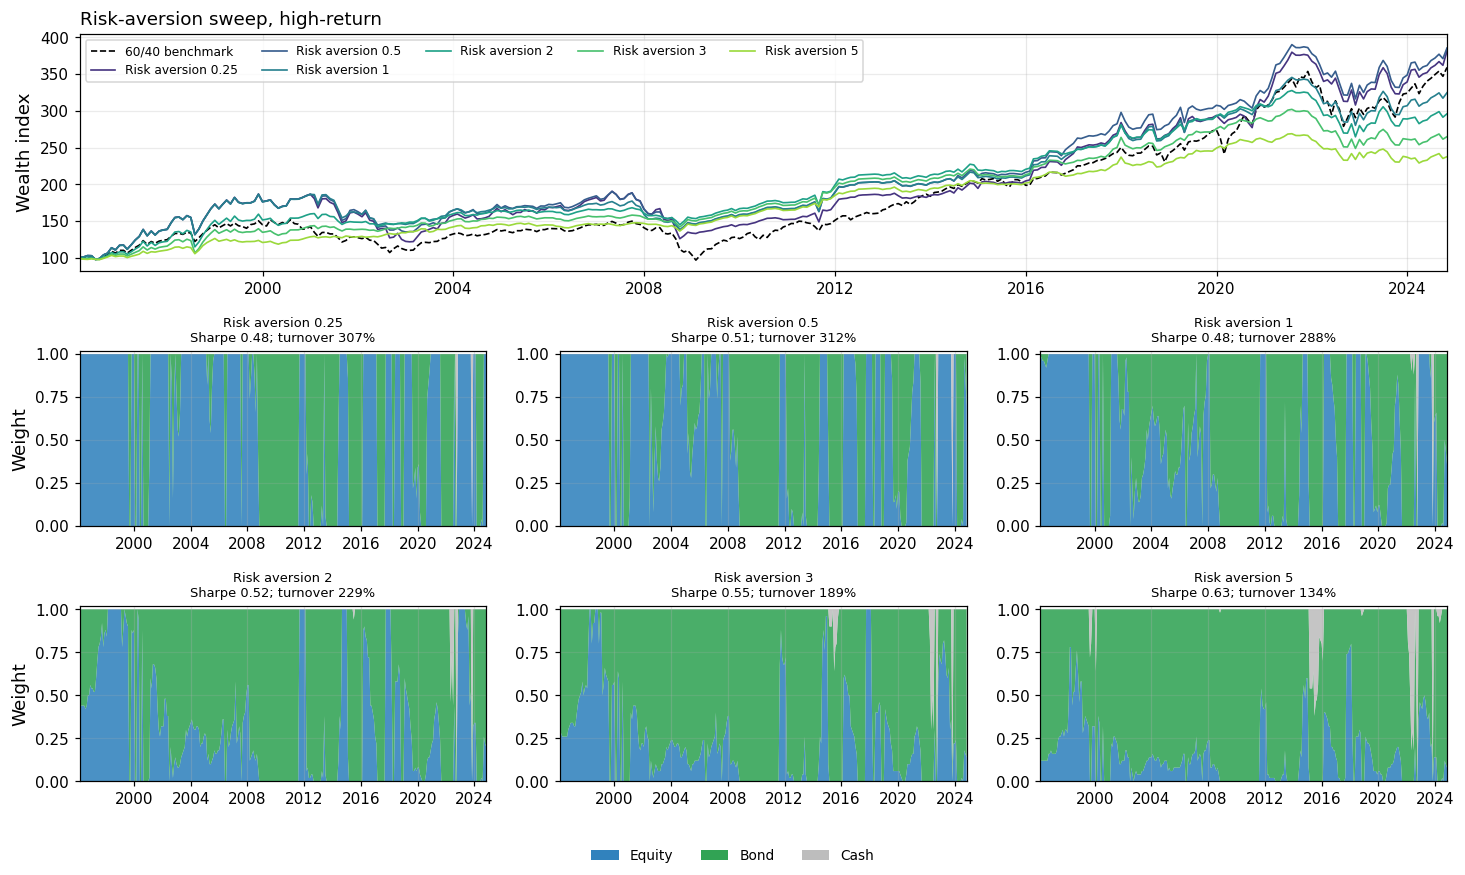

[saved] COUPLED__allocation_sweep_risk_aversion_defensive.csv / .tex


,Risk aversion,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.25,+7.1%,14.8%,0.48,-62.2%,-14.0%,552.60,10.4%
1,0.50,+7.1%,14.8%,0.48,-62.2%,-14.0%,552.10,10.4%
2,1.00,+6.7%,13.4%,0.50,-54.6%,-12.9%,527.80,14.2%
3,2.00,+4.8%,8.2%,0.59,-26.4%,-8.7%,360.87,13.6%
4,3.00,+3.8%,5.8%,0.66,-15.4%,-5.9%,284.85,10.9%
5,5.00,+3.1%,4.3%,0.73,-14.3%,-4.0%,240.25,8.9%


[saved] COUPLED__allocation_sweep_risk_aversion_defensive.png / .pdf


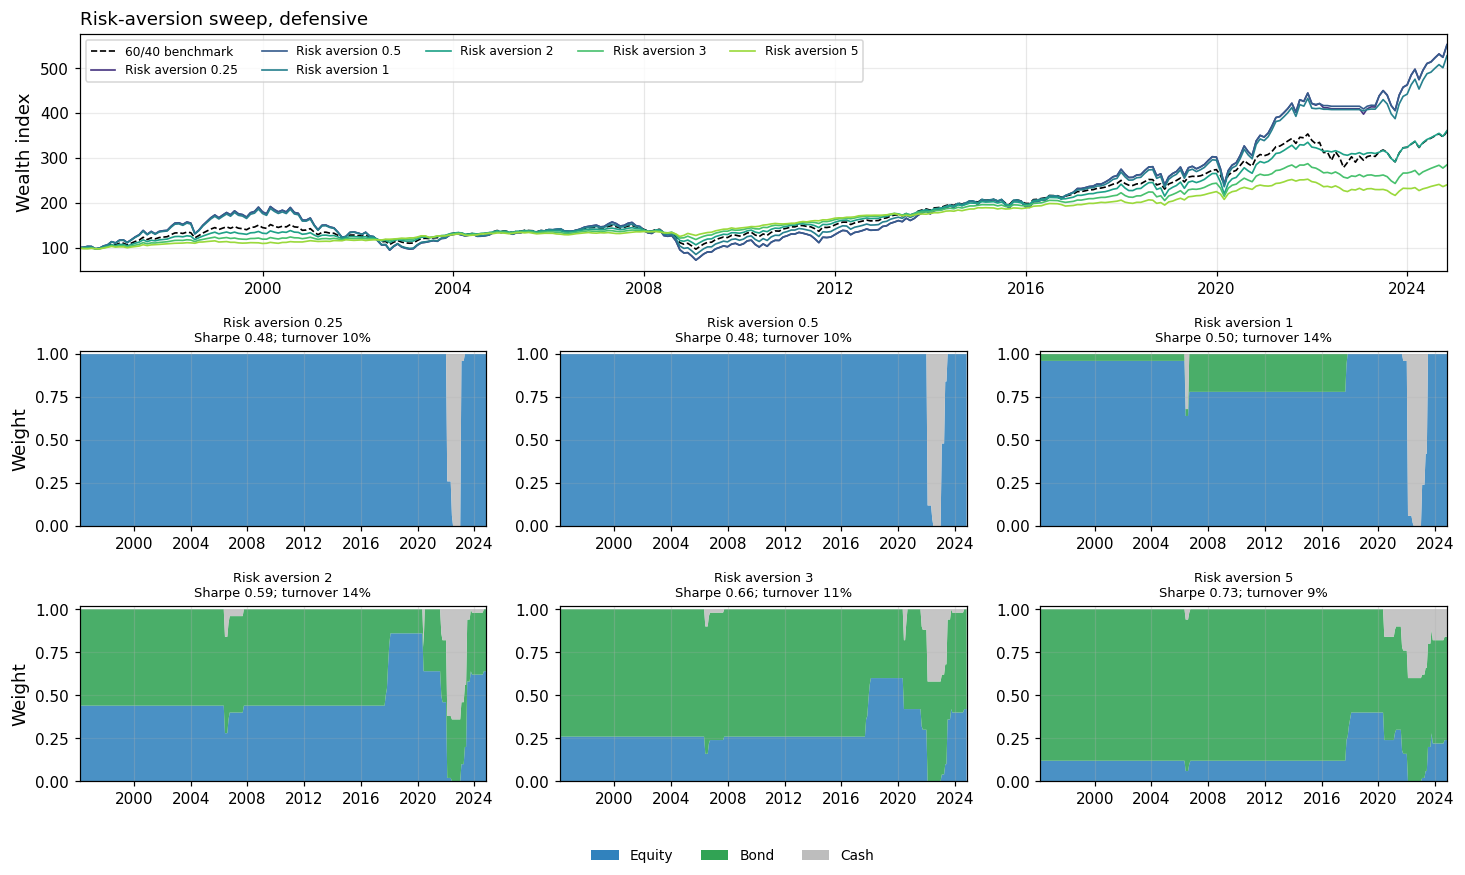

[saved] COUPLED__allocation_sweep_risk_aversion_low_turnover.csv / .tex


,Risk aversion,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.25,+6.4%,15.2%,0.42,-62.2%,-14.0%,447.42,7.5%
1,0.50,+6.4%,15.0%,0.43,-62.2%,-14.0%,455.88,9.0%
2,1.00,+6.2%,14.2%,0.43,-60.1%,-13.4%,438.49,9.5%
3,2.00,+3.9%,7.1%,0.56,-26.4%,-6.7%,287.77,6.4%
4,3.00,+3.2%,5.0%,0.63,-20.2%,-4.8%,238.67,5.3%
5,5.00,+2.6%,4.1%,0.63,-19.7%,-3.9%,205.41,4.3%


[saved] COUPLED__allocation_sweep_risk_aversion_low_turnover.png / .pdf


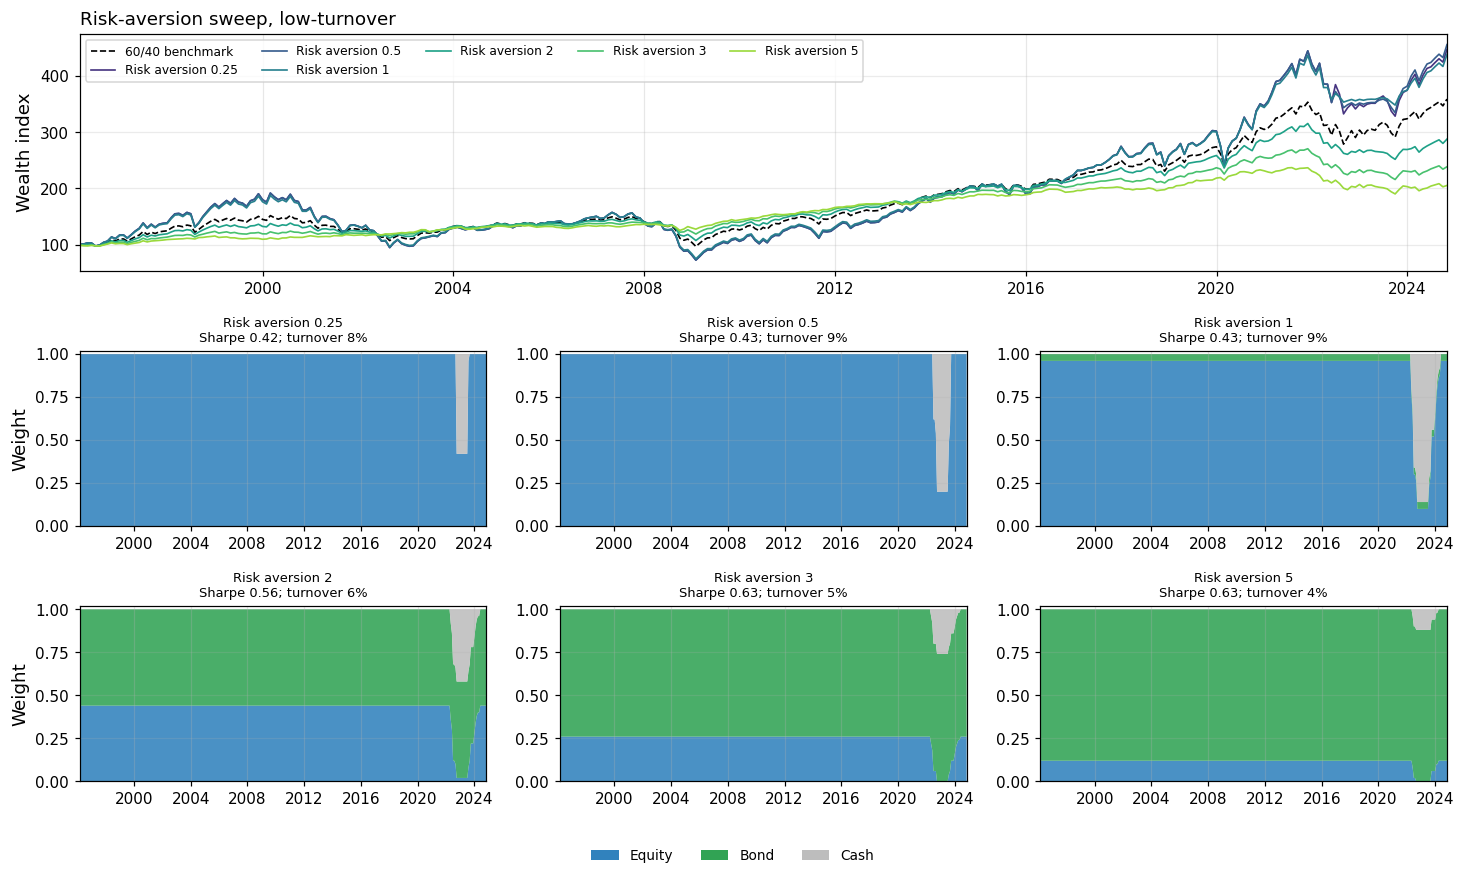

[saved] COUPLED__allocation_sweep_smoothing_high_return.csv / .tex


,Smoothing half-life,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0,+5.3%,11.0%,0.48,-34.8%,-10.6%,381.18,307.3%
1,3,+5.2%,11.2%,0.46,-41.6%,-11.4%,366.22,178.8%
2,6,+3.8%,11.9%,0.32,-53.1%,-11.9%,241.83,119.0%


[saved] COUPLED__allocation_sweep_smoothing_high_return.png / .pdf


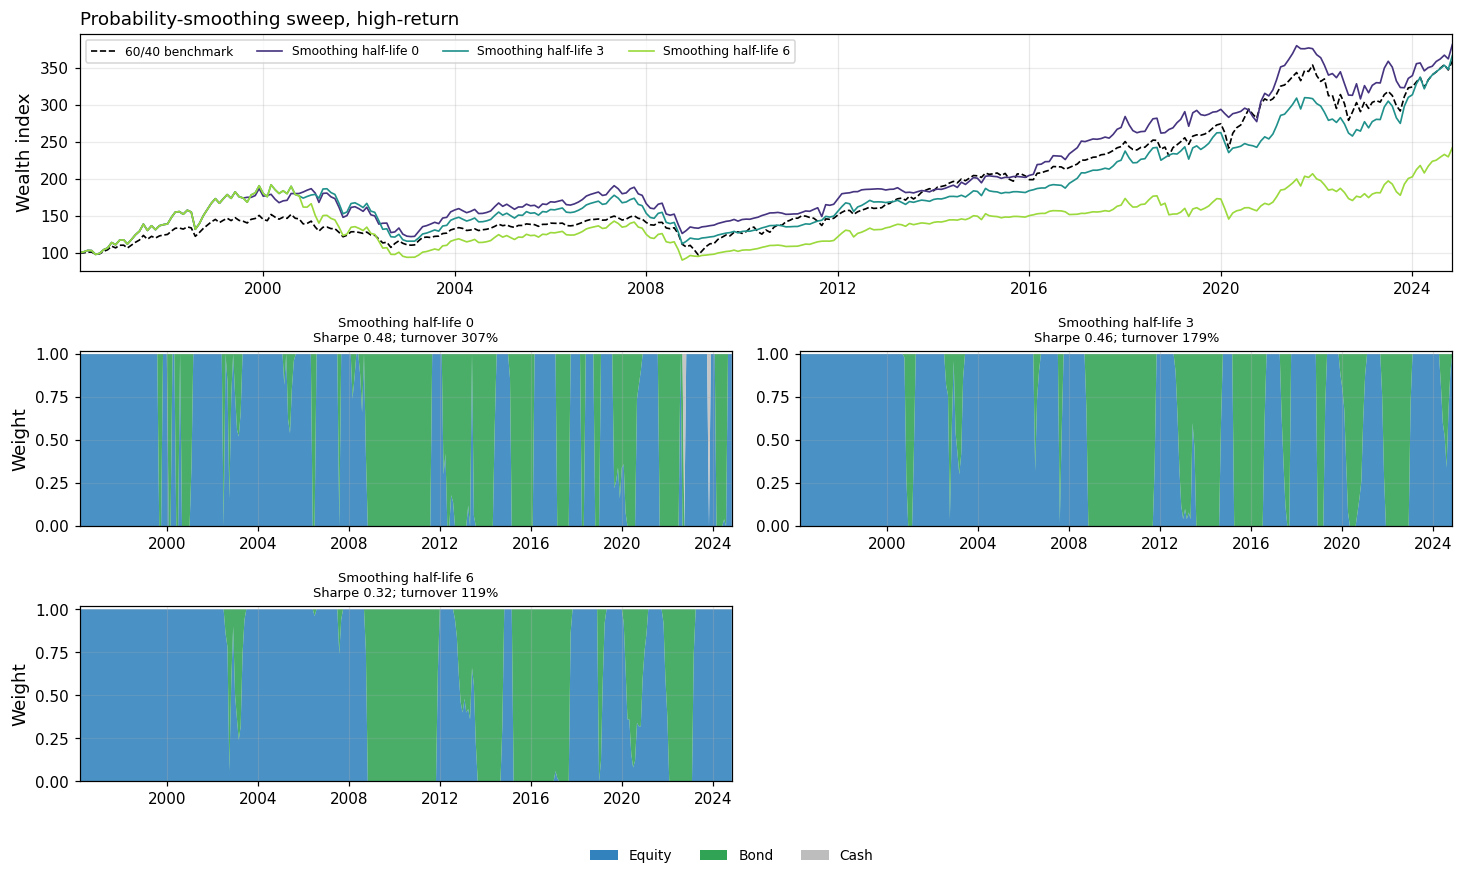

[saved] COUPLED__allocation_sweep_smoothing_defensive.csv / .tex


,Smoothing half-life,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0,+3.1%,4.3%,0.73,-14.3%,-4.0%,240.25,8.9%
1,3,+2.6%,4.1%,0.63,-19.7%,-3.9%,205.41,4.3%
2,6,+2.6%,4.2%,0.62,-19.7%,-4.2%,205.27,3.8%


[saved] COUPLED__allocation_sweep_smoothing_defensive.png / .pdf


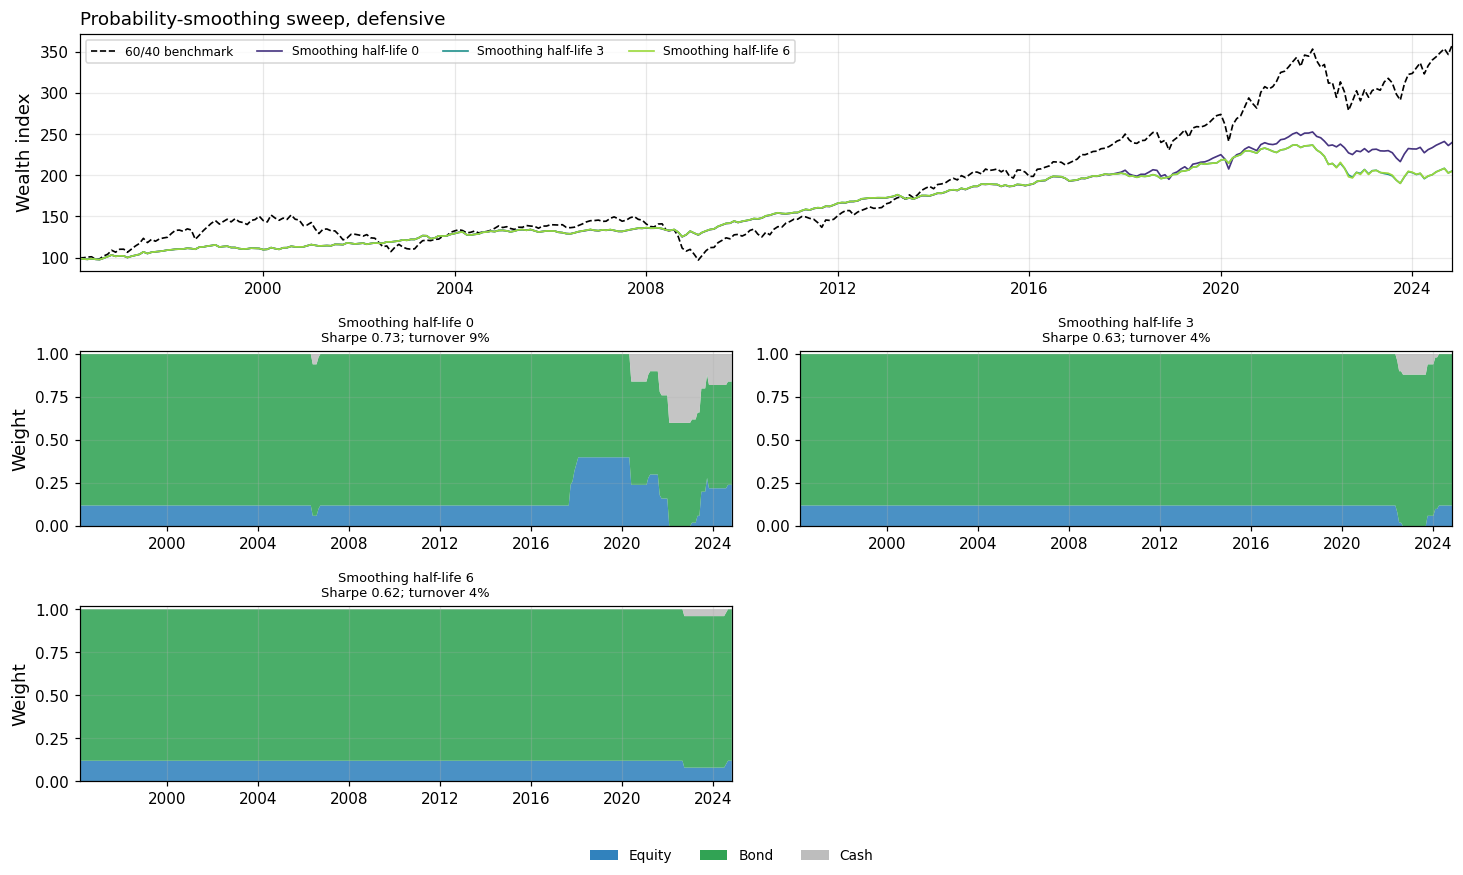

[saved] COUPLED__allocation_sweep_smoothing_low_turnover.csv / .tex


,Smoothing half-life,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0,+1.6%,2.5%,0.64,-9.7%,-2.4%,157.64,5.6%
1,3,+1.7%,2.7%,0.63,-10.5%,-2.5%,160.81,3.1%
2,6,+1.6%,2.6%,0.60,-11.5%,-2.7%,156.08,2.6%


[saved] COUPLED__allocation_sweep_smoothing_low_turnover.png / .pdf


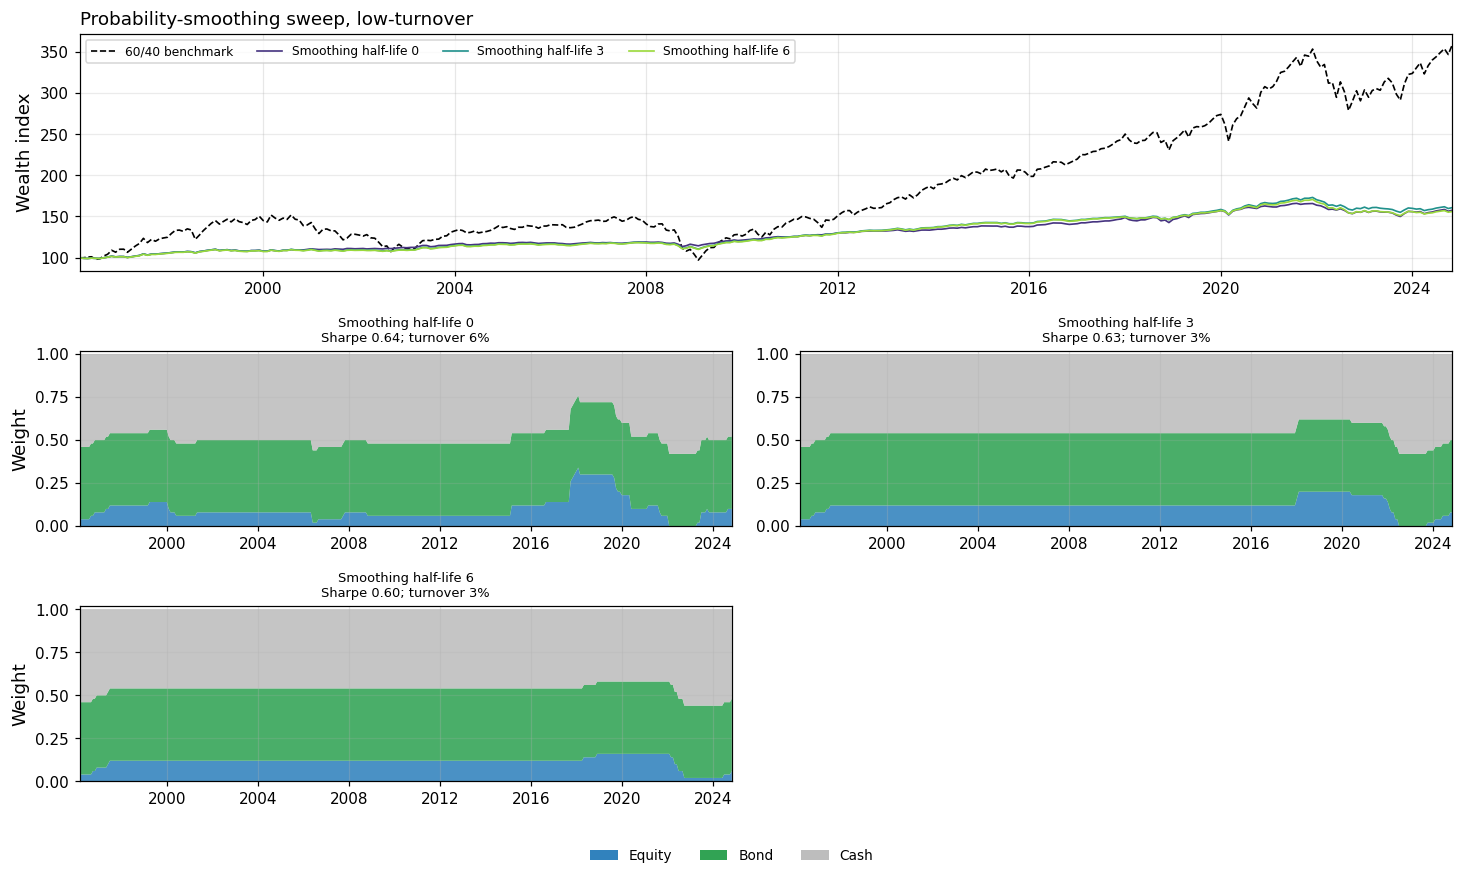

[saved] COUPLED__allocation_sweep_turnover_penalty_high_return.csv / .tex


,Turnover penalty,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.000,+5.3%,11.0%,0.48,-34.8%,-10.6%,381.18,307.3%
1,0.001,+5.2%,12.0%,0.44,-56.9%,-13.6%,362.79,135.8%
2,0.003,+4.1%,12.8%,0.32,-51.0%,-14.0%,257.39,46.1%
3,0.005,+4.0%,12.2%,0.33,-53.8%,-13.2%,252.68,29.9%


[saved] COUPLED__allocation_sweep_turnover_penalty_high_return.png / .pdf


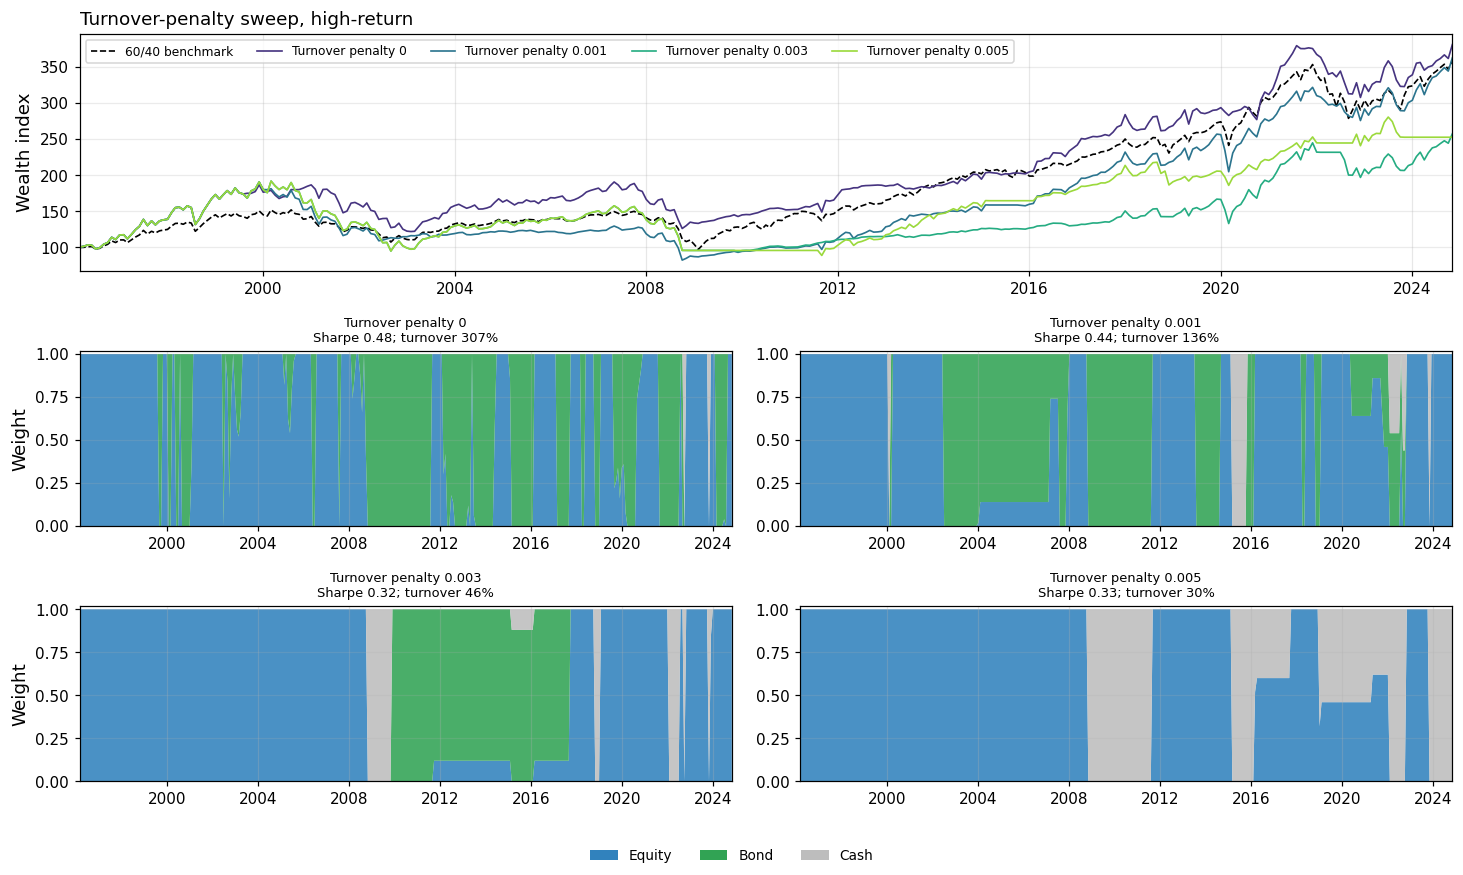

[saved] COUPLED__allocation_sweep_turnover_penalty_defensive.csv / .tex


,Turnover penalty,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.000,+3.1%,5.0%,0.62,-19.1%,-4.5%,234.96,113.0%
1,0.001,+2.8%,4.7%,0.59,-18.9%,-4.2%,214.13,29.2%
2,0.003,+3.1%,4.3%,0.73,-14.3%,-4.0%,240.25,8.9%
3,0.005,+2.1%,5.4%,0.39,-24.4%,-5.9%,175.72,4.9%


[saved] COUPLED__allocation_sweep_turnover_penalty_defensive.png / .pdf


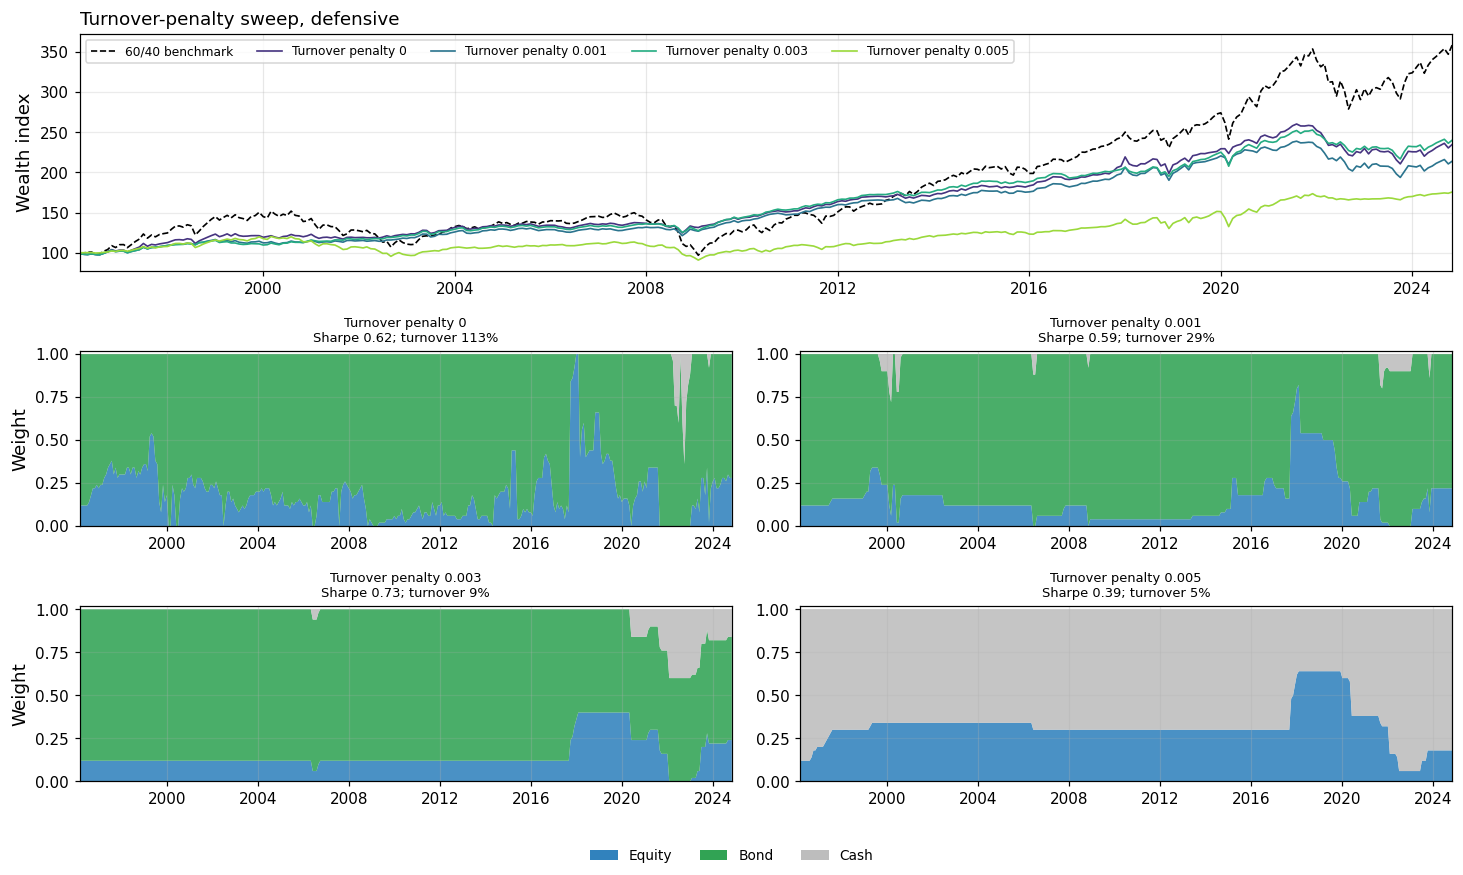

[saved] COUPLED__allocation_sweep_turnover_penalty_low_turnover.csv / .tex


,Turnover penalty,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.000,+2.5%,3.5%,0.70,-13.2%,-3.0%,199.44,31.2%
1,0.001,+2.4%,3.6%,0.68,-14.6%,-3.1%,197.02,9.5%
2,0.003,+1.7%,2.7%,0.63,-10.5%,-2.5%,160.81,3.1%
3,0.005,+0.7%,1.8%,0.40,-9.9%,-1.7%,122.86,0.8%


[saved] COUPLED__allocation_sweep_turnover_penalty_low_turnover.png / .pdf


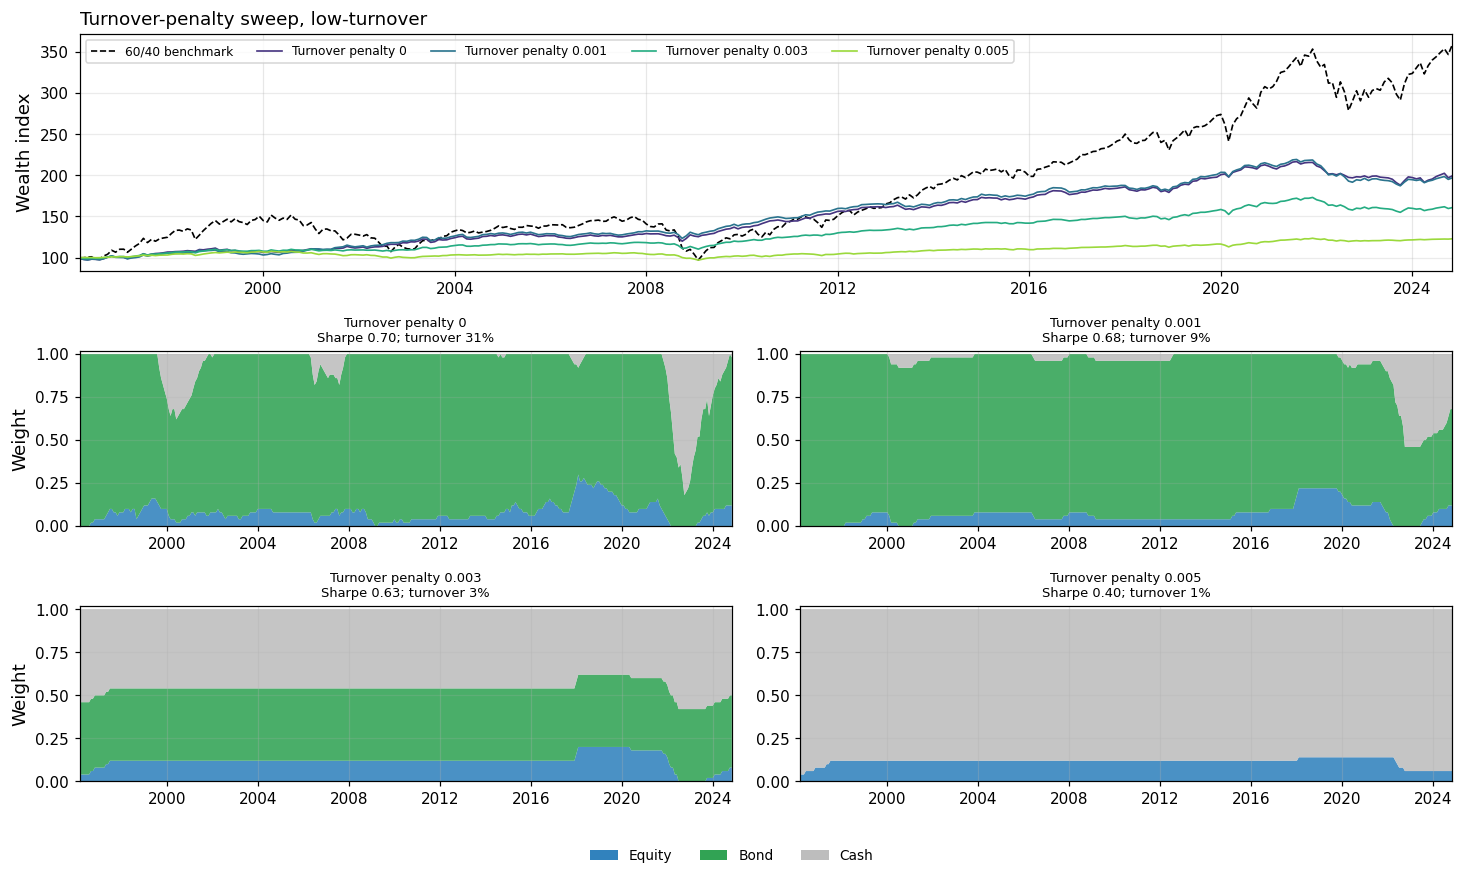

[saved] COUPLED__allocation_sweep_moment_shrinkage_high_return.csv / .tex


,Shrinkage K,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0,+2.8%,9.1%,0.31,-38.8%,-9.6%,200.17,263.4%
1,12,+4.7%,9.6%,0.49,-25.5%,-9.6%,340.98,301.8%
2,24,+5.4%,10.1%,0.53,-28.2%,-9.6%,406.06,338.8%
3,30,+5.4%,10.6%,0.51,-31.4%,-9.6%,401.57,319.9%
4,36,+5.3%,11.0%,0.48,-34.8%,-10.6%,381.18,307.3%
5,42,+5.2%,11.5%,0.45,-38.7%,-11.7%,363.86,294.3%
6,48,+5.5%,11.9%,0.46,-38.6%,-12.4%,392.89,293.1%
7,60,+6.0%,12.5%,0.48,-39.5%,-14.0%,440.13,269.8%
8,96,+6.7%,13.3%,0.51,-45.9%,-14.0%,533.04,207.4%


[saved] COUPLED__allocation_sweep_moment_shrinkage_high_return.png / .pdf


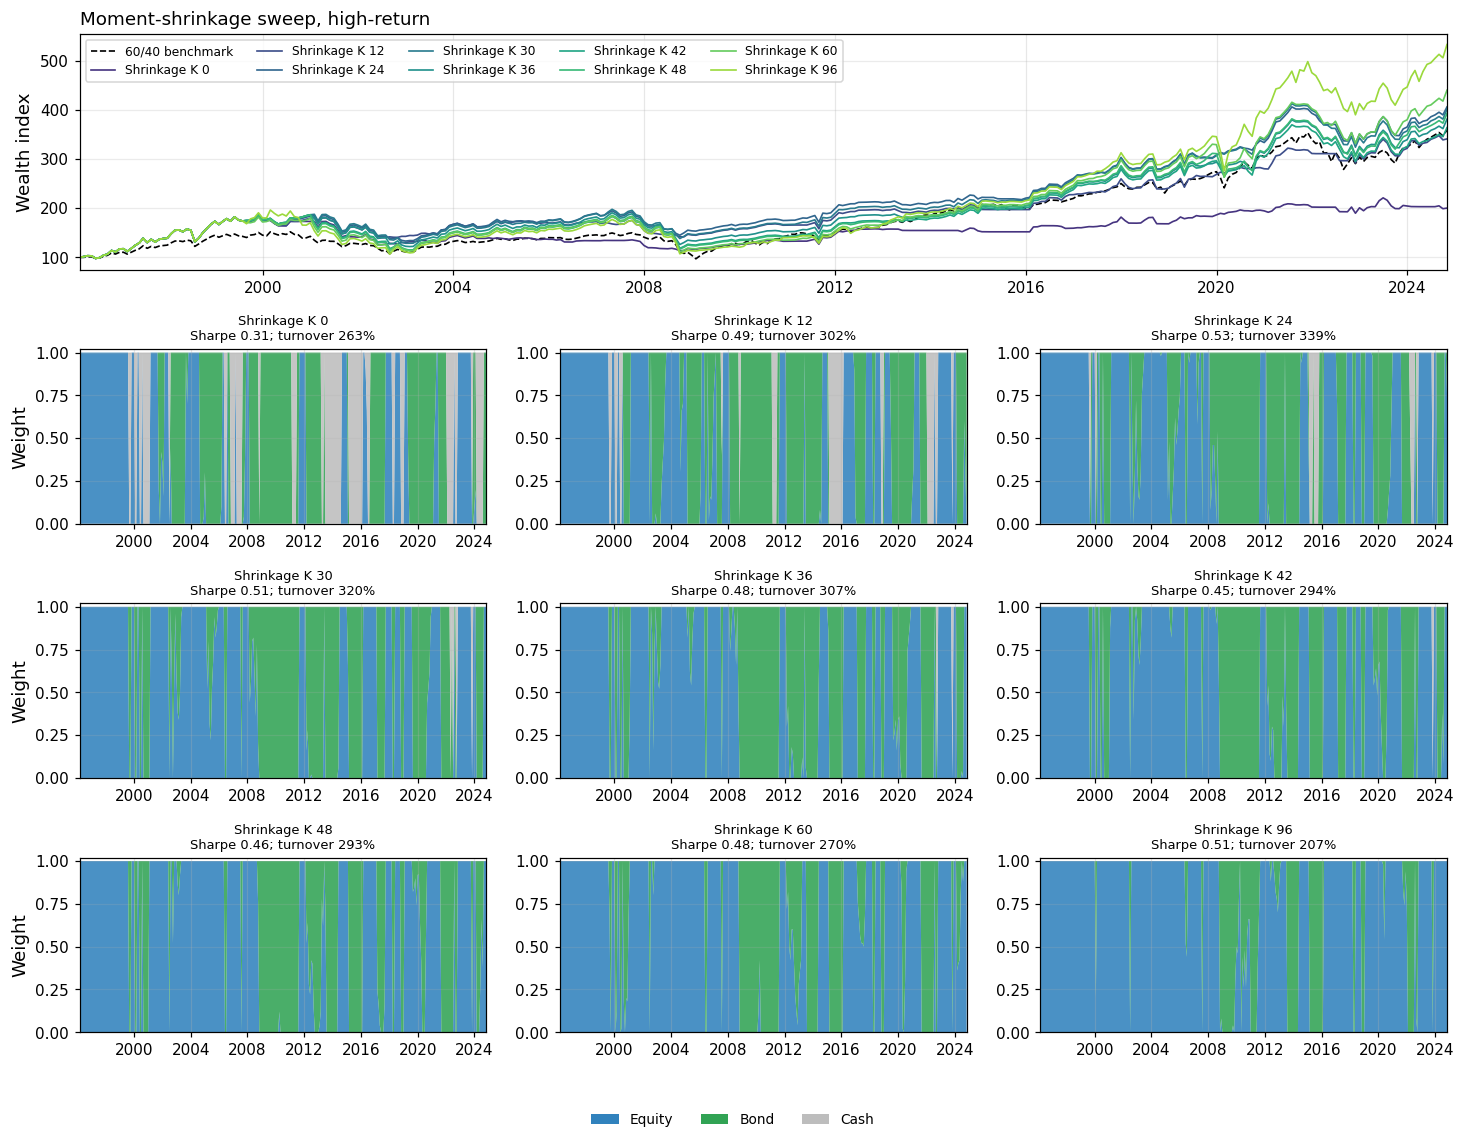

[saved] COUPLED__allocation_sweep_moment_shrinkage_defensive.csv / .tex


,Shrinkage K,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0,+2.0%,4.3%,0.47,-12.4%,-5.6%,174.55,33.9%
1,12,+3.1%,4.3%,0.73,-9.9%,-4.9%,237.89,17.5%
2,24,+3.1%,4.3%,0.72,-12.3%,-4.5%,235.19,12.7%
3,30,+3.1%,4.3%,0.72,-13.5%,-4.3%,236.67,10.4%
4,36,+3.1%,4.3%,0.73,-14.3%,-4.0%,240.25,8.9%
5,42,+3.1%,4.3%,0.73,-16.0%,-3.8%,239.03,7.4%
6,48,+3.1%,4.3%,0.72,-17.1%,-3.8%,238.11,6.9%
7,60,+3.1%,4.7%,0.66,-19.1%,-4.3%,236.44,5.0%
8,96,+3.3%,5.5%,0.59,-18.2%,-5.4%,245.65,4.0%


[saved] COUPLED__allocation_sweep_moment_shrinkage_defensive.png / .pdf


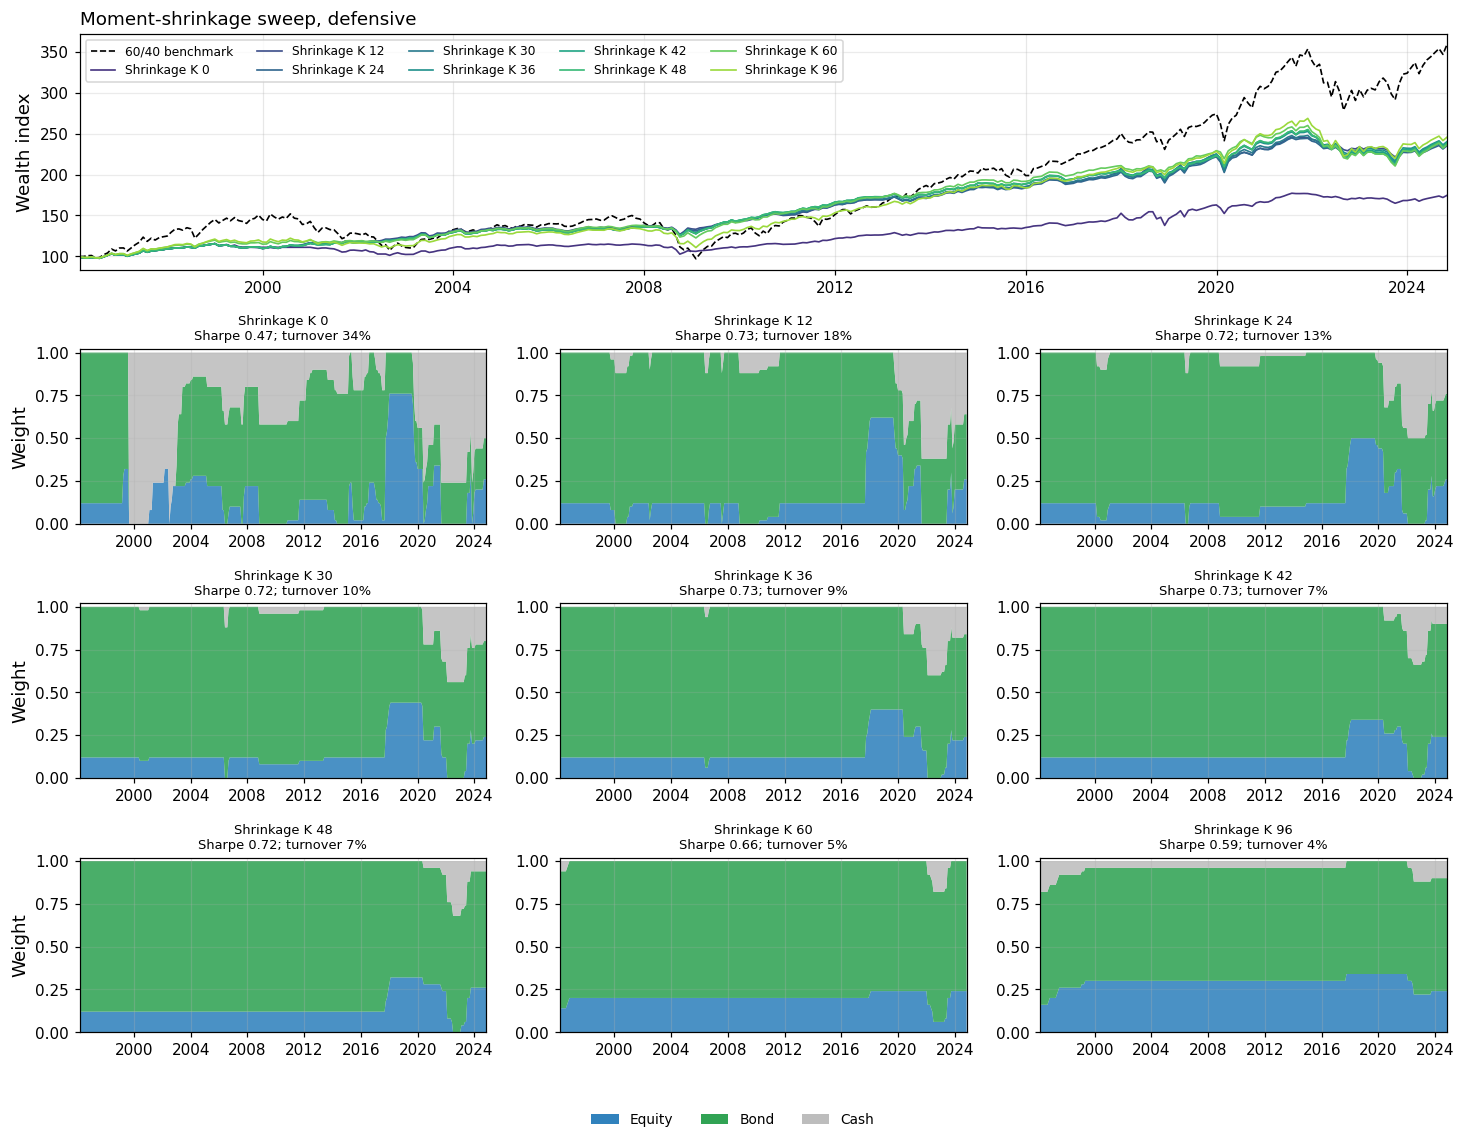

[saved] COUPLED__allocation_sweep_moment_shrinkage_low_turnover.csv / .tex


,Shrinkage K,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0,+1.3%,2.0%,0.64,-5.2%,-2.1%,144.48,7.1%
1,12,+1.8%,2.6%,0.68,-10.7%,-2.3%,164.62,4.5%
2,24,+1.7%,2.6%,0.65,-10.5%,-2.5%,162.03,3.5%
3,30,+1.7%,2.7%,0.64,-10.5%,-2.5%,162.99,3.3%
4,36,+1.7%,2.7%,0.63,-10.5%,-2.5%,160.81,3.1%
5,42,+1.5%,2.6%,0.58,-9.8%,-2.5%,152.16,2.9%
6,48,+1.6%,2.5%,0.62,-9.6%,-2.4%,155.24,2.6%
7,60,+1.5%,2.5%,0.61,-9.4%,-2.5%,153.63,2.3%
8,96,+1.4%,2.4%,0.58,-8.6%,-2.5%,147.00,1.7%


[saved] COUPLED__allocation_sweep_moment_shrinkage_low_turnover.png / .pdf


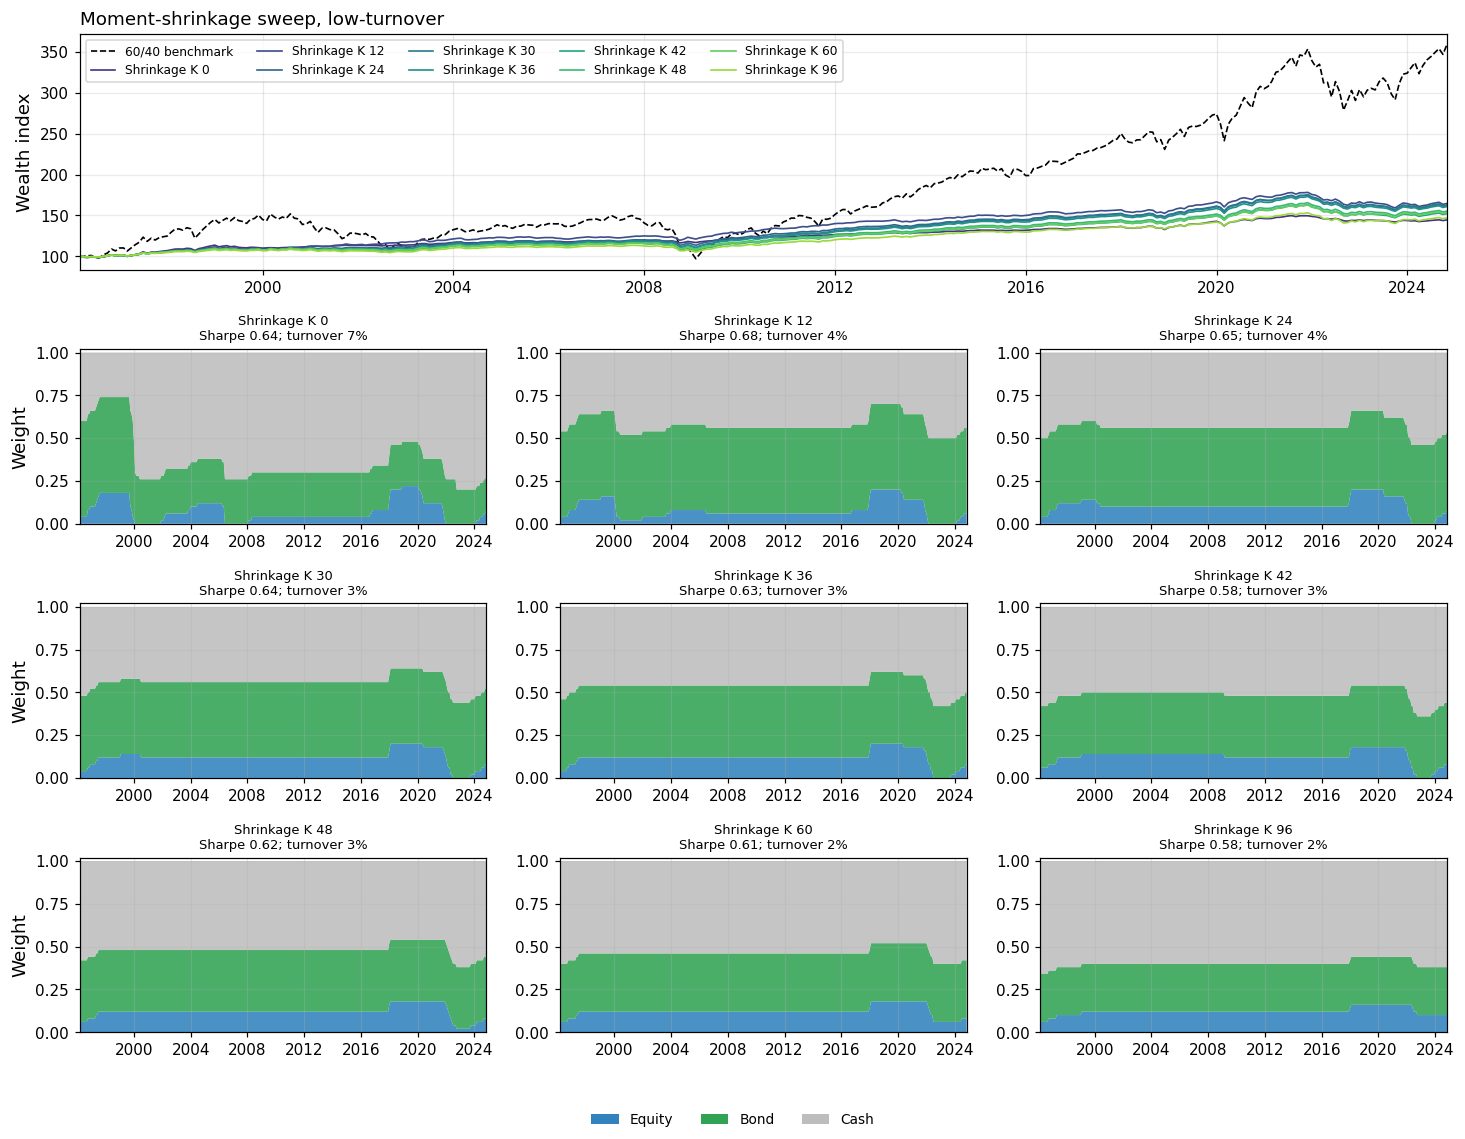

CELL 27d-g OK


In [33]:
# ============================================================================
# CELL 27d/e/f/g — one-parameter sweeps across the 3 mechanical roles
# ============================================================================
for spec in STRATS_SWEEP:   # 27d gamma
    sweep_strategy(spec,"gamma",GAMMA_SWEEP,"Risk aversion","risk_aversion",f"Risk-aversion sweep, {spec['role'].lower()}")
for spec in STRATS_SWEEP:   # 27e smoothing
    sweep_strategy(spec,"h",[0,3,6],"Smoothing half-life","smoothing",f"Probability-smoothing sweep, {spec['role'].lower()}")
for spec in STRATS_SWEEP:   # 27f turnover penalty
    sweep_tau(spec,f"Turnover-penalty sweep, {spec['role'].lower()}")
for spec in STRATS_SWEEP:   # 27g shrinkage K
    sweep_strategy(spec,"K",[0,12,24,30,36,42,48,60,96],"Shrinkage K","moment_shrinkage",f"Moment-shrinkage sweep, {spec['role'].lower()}")
print("CELL 27d-g OK")

In [34]:
# ============================================================================
# CELL 28 — TABLE: COUPLED__alloc_summary
# ============================================================================
rows=[]
for role in ("Defensive","Low-turnover","High-return"):
    nm=ROLES[role]; m=metrics(sims[nm])
    rows.append({"Role":role,"Strategy":nm,"Ann. exc.":f"{m['ann_excess']:+.2%}","Vol.":f"{m['vol']:.2%}",
        "Sharpe":round(m["sharpe"],3),"Max DD":f"{m['max_dd']:.1%}","CVaR1%":f"{m['cvar1']:.2%}",
        "Final":round(m["final"],1),"Turn.":f"{m['turnover']:.1%}"})
rows.append({"Role":"Benchmark","Strategy":"60/40","Ann. exc.":f"{mb['ann_excess']:+.2%}","Vol.":f"{mb['vol']:.2%}",
    "Sharpe":round(mb["sharpe"],3),"Max DD":f"{mb['max_dd']:.1%}","CVaR1%":f"{mb['cvar1']:.2%}",
    "Final":round(mb["final"],1),"Turn.":f"{mb['turnover']:.1%}"})
save_tbl(pd.DataFrame(rows),"alloc_summary",ff="%.3f")

[saved] COUPLED__alloc_summary.csv / .tex


,Role,Strategy,Ann. exc.,Vol.,Sharpe,Max DD,CVaR1%,Final,Turn.
0,Defensive,RF__g5__tau3__c10bps__phl0,+3.15%,4.33%,0.727,-14.3%,-3.99%,240.2,8.9%
1,Low-turnover,RF__g12__tau3__c10bps__phl3,+1.69%,2.66%,0.635,-10.5%,-2.52%,160.8,3.1%
2,High-return,Logit__g0.25__tau0__c10bps__phl0,+5.28%,11.04%,0.478,-34.8%,-10.56%,381.2,307.3%
3,Benchmark,60/40,+4.92%,9.63%,0.511,-36.2%,-8.78%,359.0,23.2%


In [35]:
# ============================================================================
# CELL 29 — TABLE: COUPLED__dynamic_benchmark
# ============================================================================
def static_path(target_fn, cost=HEADLINE_COST):
    pe=pb=0.0; rec=[]
    for i in range(NOBS):
        we,wb=target_fn(i); we=max(0.0,we); wb=max(0.0,wb); g=we+wb
        if g>MAX_TOTAL_RISKY and g>0: we*=MAX_TOTAL_RISKY/g; wb*=MAX_TOTAL_RISKY/g
        st=abs(we-pe)+abs(wb-pb); ex=we*EQX[i]+wb*BDX[i]-cost*st
        rec.append((Ws["date"].iloc[i],we,wb,1.0-we-wb,st,ex)); pe,pb=we,wb
    d=pd.DataFrame(rec,columns=["date","w_eq","w_bd","w_cash","turnover","ex"]); d["wealth"]=(1.0+d["ex"]).cumprod(); return d

_eqx_hist=hist_all.dropna(subset=["eqx"]).set_index("date")["eqx"]
def _voltgt(i):
    past=_eqx_hist[_eqx_hist.index<=Ws["date"].iloc[i]].tail(36)
    rv=past.std(ddof=0)*np.sqrt(12) if len(past)>=12 else 0.10
    lev=min(1.0,0.10/rv) if rv>1e-6 else 1.0
    return 0.60*lev,0.40*lev
def _minvar(i):
    _,_,c00,c01,c11=moment_inputs("Logit",0)
    S=np.array([[c00[i],c01[i]],[c01[i],c11[i]]])
    try: iv=np.linalg.solve(S,np.ones(2))
    except np.linalg.LinAlgError: iv=np.array([0.0,1.0])
    w=np.clip(iv,0,None); s=w.sum(); w=w/s if s>0 else np.array([0.0,1.0])
    return float(w[0]),float(w[1])
BM={"60/40":bench_6040(HEADLINE_COST),"50/50":static_path(lambda i:(0.5,0.5)),
    "Equity-only":static_path(lambda i:(1.0,0.0)),"Bond-only":static_path(lambda i:(0.0,1.0)),
    "Min-variance (uncond.)":static_path(_minvar),"Vol-targeted 60/40":static_path(_voltgt)}
rows=[]
for name,d in BM.items():
    m=metrics(d); rows.append({"Benchmark":name,"Ann. exc.":f"{m['ann_excess']:+.2%}","Vol.":f"{m['vol']:.2%}",
        "Sharpe":round(m["sharpe"],3),"Max DD":f"{m['max_dd']:.1%}","Final":round(m["final"],1),"Turn.":f"{m['turnover']:.1%}"})
save_tbl(pd.DataFrame(rows),"dynamic_benchmarks",ff="%.3f")

[saved] COUPLED__dynamic_benchmarks.csv / .tex


,Benchmark,Ann. exc.,Vol.,Sharpe,Max DD,Final,Turn.
0,60/40,+4.92%,9.63%,0.511,-36.2%,359.0,23.2%
1,50/50,+4.46%,8.26%,0.540,-29.9%,326.2,3.5%
2,Equity-only,+6.85%,15.43%,0.444,-62.2%,505.0,3.5%
3,Bond-only,+2.07%,4.07%,0.509,-21.3%,177.1,3.5%
4,Min-variance (uncond.),+2.22%,4.08%,0.544,-20.3%,184.8,8.4%
5,Vol-targeted 60/40,+3.26%,6.92%,0.471,-31.3%,238.0,17.1%


[saved] COUPLED__alloc_wealth_drawdown.png / .pdf


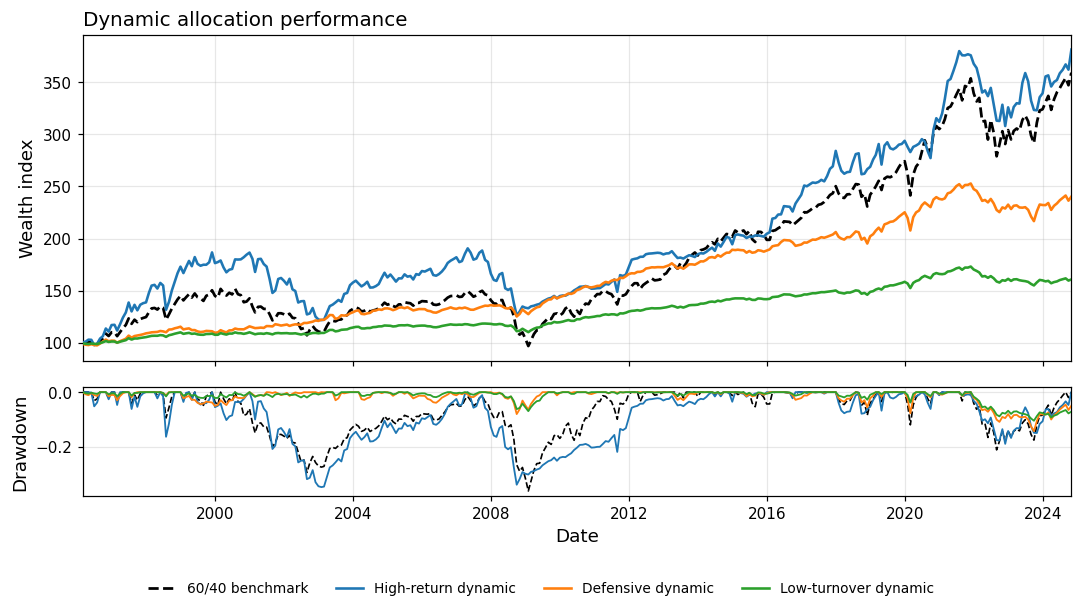

In [ ]:
# ============================================================================
# CELL 30 — FIGURE: COUPLED__alloc_wealth_drawdown
# ============================================================================
_plotted = [sims["60_40"]] + [sims[ROLES[r]] for r in ("High-return","Defensive","Low-turnover")]
FIG_T0 = min(d.date.min() for d in _plotted)
FIG_T1 = max(d.date.max() for d in _plotted)
def _align(ax):
    ax.set_xlim(FIG_T0, FIG_T1)
    ax.margins(x=0)

SLINE = {"High-return":"#1f77b4","Defensive":"#ff7f0e","Low-turnover":"#2ca02c"}
BENCH = "#000000"

fig,axes = plt.subplots(2,1,figsize=(10,5.5),sharex=True,
                        gridspec_kw={"height_ratios":[3,1]})

axes[0].plot(sims["60_40"].date,100*sims["60_40"].wealth,color=BENCH,ls="--",lw=1.8,
             label="60/40 benchmark",zorder=5)
for role in ("High-return","Defensive","Low-turnover"):
    d=sims[ROLES[role]]
    axes[0].plot(d.date,100*d.wealth,color=SLINE[role],lw=1.7,label=f"{role} dynamic",zorder=5)
axes[0].set_ylabel("Wealth index")
axes[0].set_title("Dynamic allocation performance",loc="left")
_align(axes[0])

def _dd(c): w=sims[c].wealth.values; return w/np.maximum.accumulate(w)-1
axes[1].plot(sims["60_40"].date,_dd("60_40"),color=BENCH,ls="--",lw=1.1,zorder=5)
for role in ("High-return","Defensive","Low-turnover"):
    axes[1].plot(sims[ROLES[role]].date,_dd(ROLES[role]),color=SLINE[role],lw=1.2,zorder=5)
axes[1].set_ylabel("Drawdown")
year_axis(axes[1],base=4); axes[1].set_xlabel("Date"); _align(axes[1])

h,l = axes[0].get_legend_handles_labels()
fig.legend(h,l,loc="lower center",bbox_to_anchor=(0.5,-0.02),ncol=4,frameon=False,fontsize=9)

fig.tight_layout(rect=[0,0.05,1,1])
save_fig(fig,"alloc_wealth_drawdown")

[saved] COUPLED__alloc_mechanics.png / .pdf


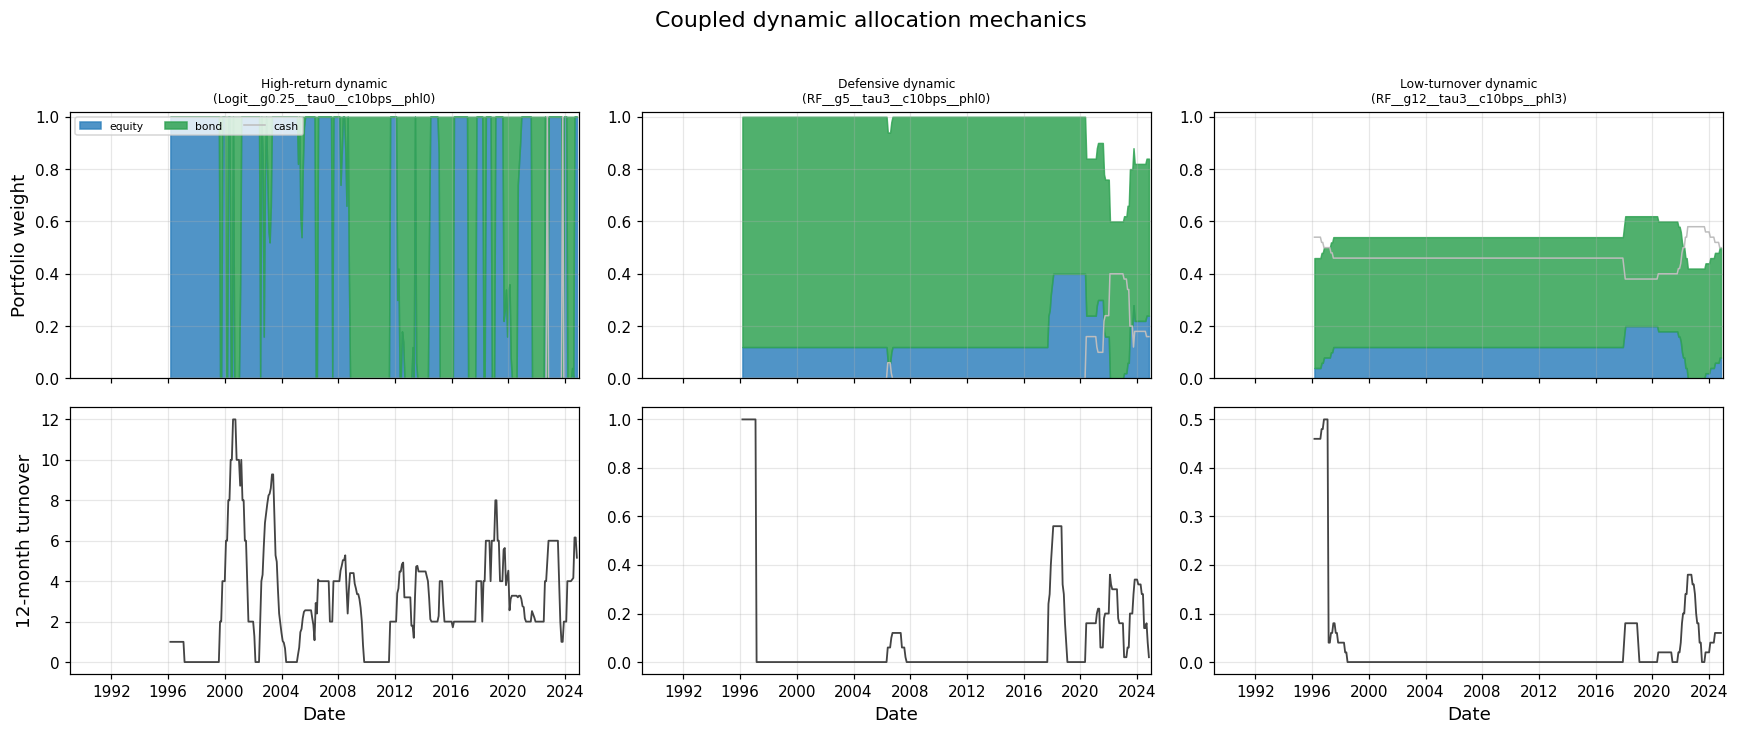

In [37]:
# ============================================================================
# CELL 31 — FIGURE: COUPLED__alloc_mechanics  (weights + 12m turnover)
# ============================================================================
FIG_T0 = globals().get("LABEL_START", Ws["date"].min())
FIG_T1 = globals().get("LABEL_END",   Ws["date"].max())
def _align(ax): ax.set_xlim(FIG_T0, FIG_T1)
fig,axes=plt.subplots(2,3,figsize=(16,6.6),sharex=True)
for c,role in enumerate(("High-return","Defensive","Low-turnover")):
    d=sims[ROLES[role]]; ax=axes[0,c]
    ax.fill_between(d.date,0,d.w_eq,color=WC["eq"],alpha=0.85,label="equity")
    ax.fill_between(d.date,d.w_eq,d.w_eq+d.w_bd,color=WC["bd"],alpha=0.85,label="bond")
    ax.plot(d.date,d.w_cash,color=WC["cash"],lw=1.0,label="cash")
    ax.set_ylim(0,1.02); _align(ax); ax.set_title(f"{role} dynamic\n({ROLES[role]})",fontsize=8)
    if c==0: ax.set_ylabel("Portfolio weight"); ax.legend(fontsize=7,loc="upper left",ncol=3)
    roll=d.set_index("date")["turnover"].rolling(12,min_periods=1).sum()
    axes[1,c].plot(roll.index,roll.values,color="#444",lw=1.2); year_axis(axes[1,c],base=4); axes[1,c].set_xlabel("Date"); _align(axes[1,c])
    if c==0: axes[1,c].set_ylabel("12-month turnover")
fig.suptitle("Coupled dynamic allocation mechanics",y=1.01); fig.tight_layout(); save_fig(fig,"alloc_mechanics")

[saved] COUPLED__alloc_mechanics_appendix.png / .pdf


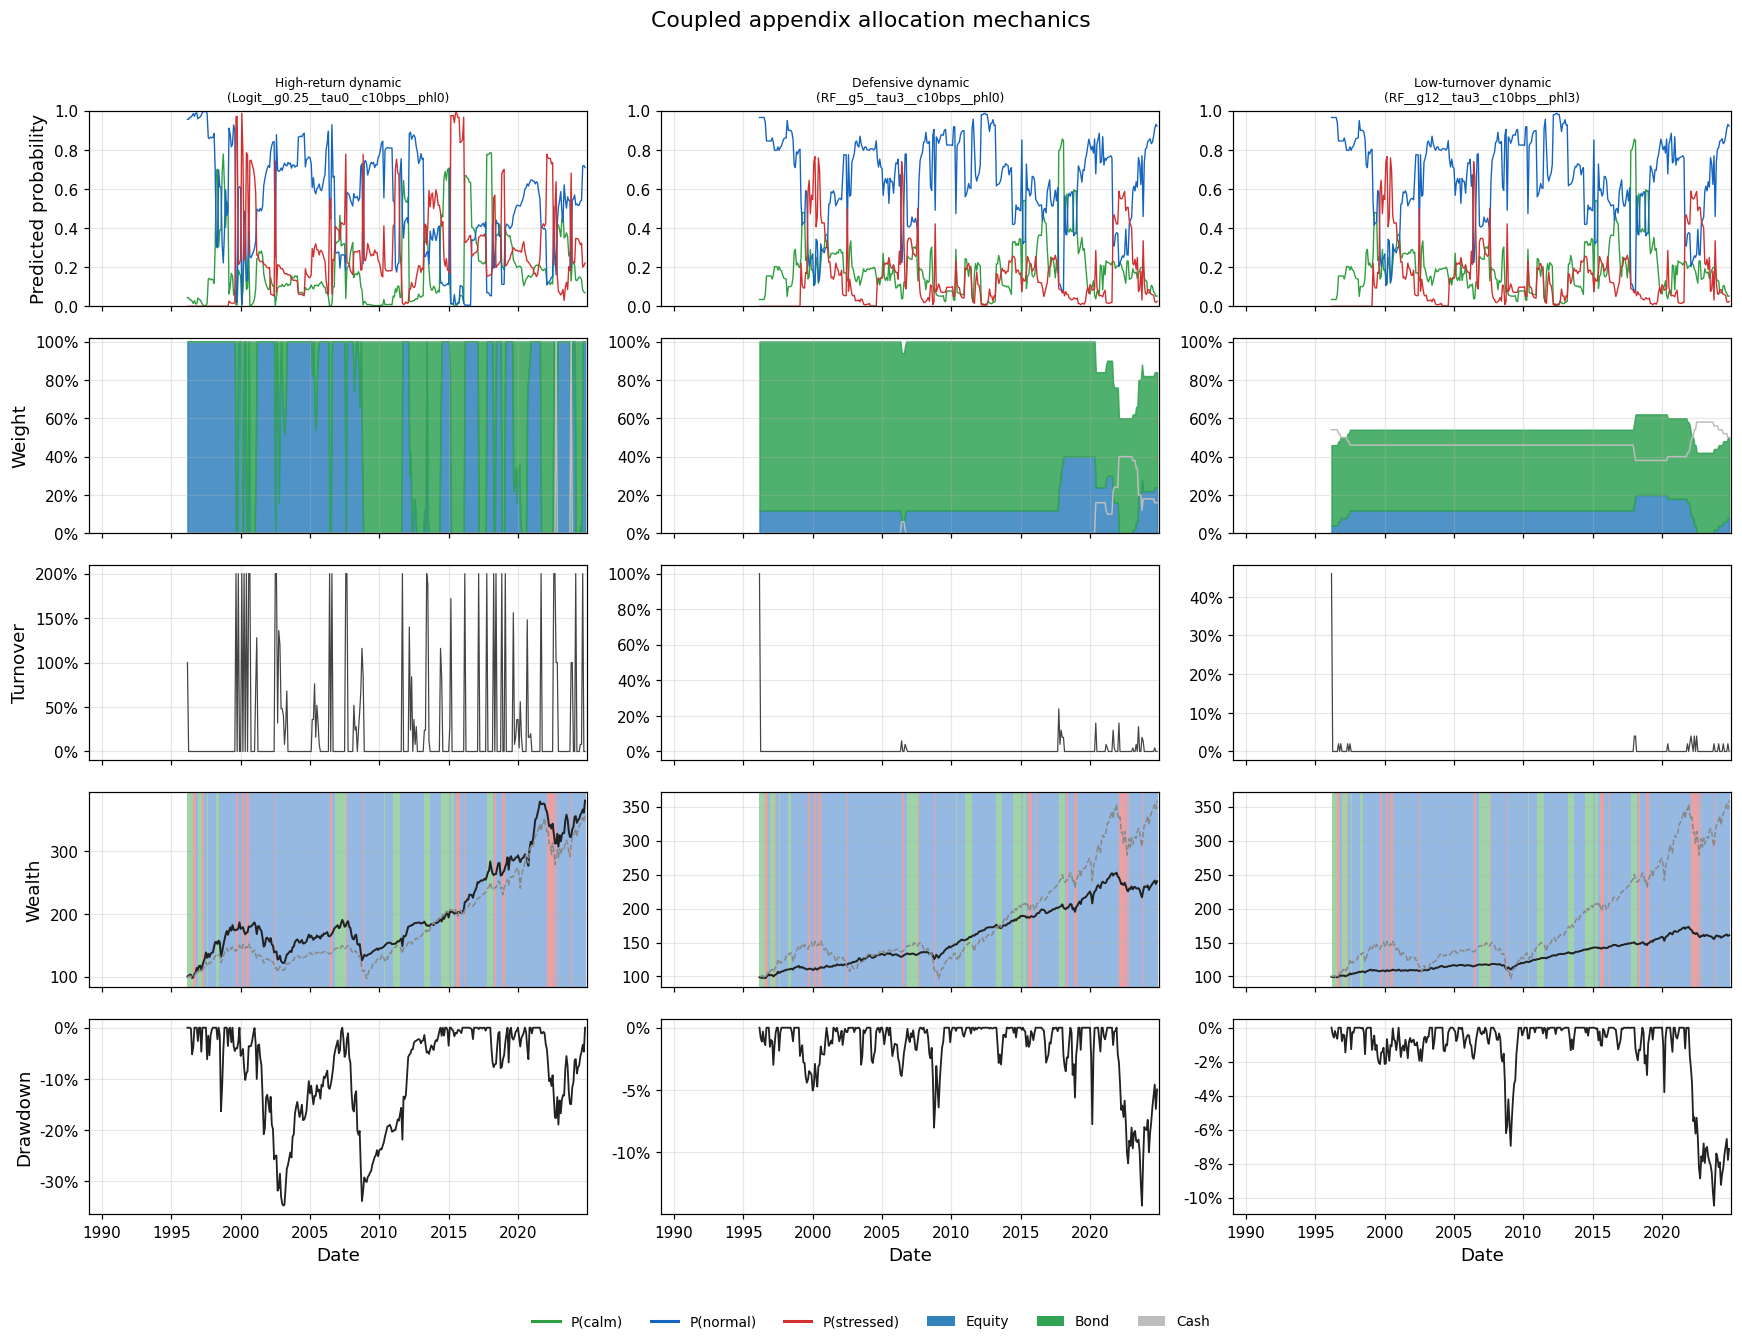

In [ ]:
# ============================================================================
# CELL 32 — FIGURE: COUPLED__alloc_mechanics_appendix
# ============================================================================
FIG_T0 = globals().get("LABEL_START", Ws["date"].min())
FIG_T1 = globals().get("LABEL_END",   Ws["date"].max())
def _align(ax): ax.set_xlim(FIG_T0, FIG_T1)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
rlab=["Predicted probability","Weight","Turnover","Wealth","Drawdown"]
fig,axes=plt.subplots(5,3,figsize=(16,12),sharex=True)
for c,role in enumerate(("High-return","Defensive","Low-turnover")):
    nm=ROLES[role]; mk=role_model(nm); d=sims[nm]
    for cls in LABEL_CLASSES: axes[0,c].plot(Wa.date,Wa[f"p_{mk}_{cls}"],lw=0.9,color=LINE_COLORS[cls])
    axes[0,c].set_ylim(0,1); _align(axes[0,c]); axes[0,c].set_title(f"{role} dynamic\n({nm})",fontsize=8)
    axes[1,c].fill_between(d.date,0,d.w_eq,color=WC["eq"],alpha=0.85)
    axes[1,c].fill_between(d.date,d.w_eq,d.w_eq+d.w_bd,color=WC["bd"],alpha=0.85)
    axes[1,c].plot(d.date,d.w_cash,color=WC["cash"],lw=1.0); axes[1,c].set_ylim(0,1.02); yfmt_pct(axes[1,c]); _align(axes[1,c])
    axes[2,c].plot(d.date,d.turnover,color="#444",lw=0.8); yfmt_pct(axes[2,c]); _align(axes[2,c])
    shade(axes[3,c],Wa["date"],Wa["regime"],alpha=0.45)
    axes[3,c].plot(d.date,100*d.wealth,color="#222222",lw=1.3,zorder=5); axes[3,c].plot(sims["60_40"].date,100*sims["60_40"].wealth,color="#888",ls="--",lw=1.0,zorder=5); _align(axes[3,c])
    w=d.wealth.values; axes[4,c].plot(d.date,w/np.maximum.accumulate(w)-1,color="#222222",lw=1.2); yfmt_pct(axes[4,c])
    year_axis(axes[4,c],base=5); axes[4,c].set_xlabel("Date"); _align(axes[4,c])
for r,l in enumerate(rlab): axes[r,0].set_ylabel(l)
_handles=[Line2D([0],[0],color=LINE_COLORS[c],lw=2,label=f"P({c})") for c in LABEL_CLASSES] + \
         [Patch(facecolor=WC["eq"],label="Equity"),Patch(facecolor=WC["bd"],label="Bond"),Patch(facecolor=WC["cash"],label="Cash")]
fig.legend(handles=_handles,loc="lower center",ncol=6,frameon=False,fontsize=9)
fig.suptitle("Coupled appendix allocation mechanics",y=1.005); fig.tight_layout(rect=[0,0.04,1,1]); save_fig(fig,"alloc_mechanics_appendix")

In [39]:
# ============================================================================
# CELL 33 — TABLE: COUPLED__cost_turnover_controlled
# ============================================================================
rows=[]
for tm in TAU_GRID:
    row={"Turnover penalty (tau)":tm}
    for tc in COST_GRID:
        row[f"{int(round(tc*1e4))} bps"]=round(metrics(alloc_path(REF_MODEL,REF_GAMMA,tm,tc,REF_HL))["sharpe"],3)
    rows.append(row)
save_tbl(pd.DataFrame(rows),"cost_turnover_controlled",ff="%.3f")

[saved] COUPLED__cost_turnover_controlled.csv / .tex


,Turnover penalty (tau),5 bps,10 bps,25 bps
0,0.0,0.647,0.634,0.593
1,1.0,0.602,0.615,0.645
2,3.0,0.626,0.599,0.180
3,5.0,0.655,0.225,NaN


[saved] COUPLED__sweep_gamma_logit.png / .pdf


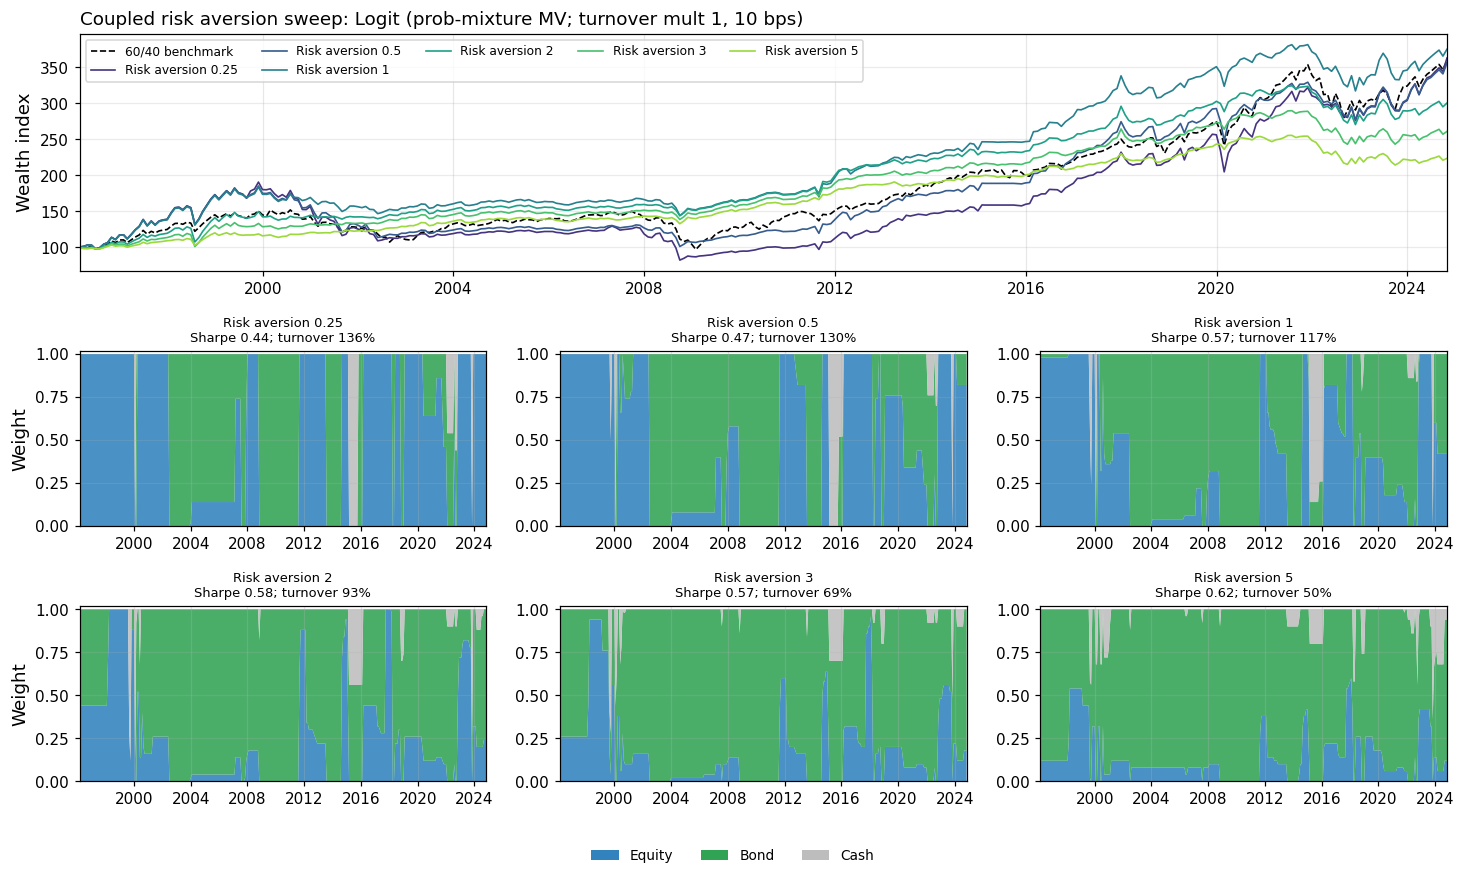

[saved] COUPLED__sweep_gamma_logit.csv / .tex


,Risk aversion,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.25,+5.2%,12.0%,0.436,-56.9%,-13.6%,362.8,135.8%
1,0.50,+5.0%,10.6%,0.471,-45.4%,-11.0%,356.1,129.7%
2,1.00,+5.0%,8.8%,0.569,-21.7%,-8.9%,375.1,117.3%
3,2.00,+4.1%,7.1%,0.576,-16.6%,-7.5%,300.3,92.7%
4,3.00,+3.5%,6.2%,0.573,-16.1%,-6.7%,260.9,68.6%
5,5.00,+2.9%,4.7%,0.615,-16.1%,-4.7%,223.5,49.9%


[saved] COUPLED__sweep_gamma_rf.png / .pdf


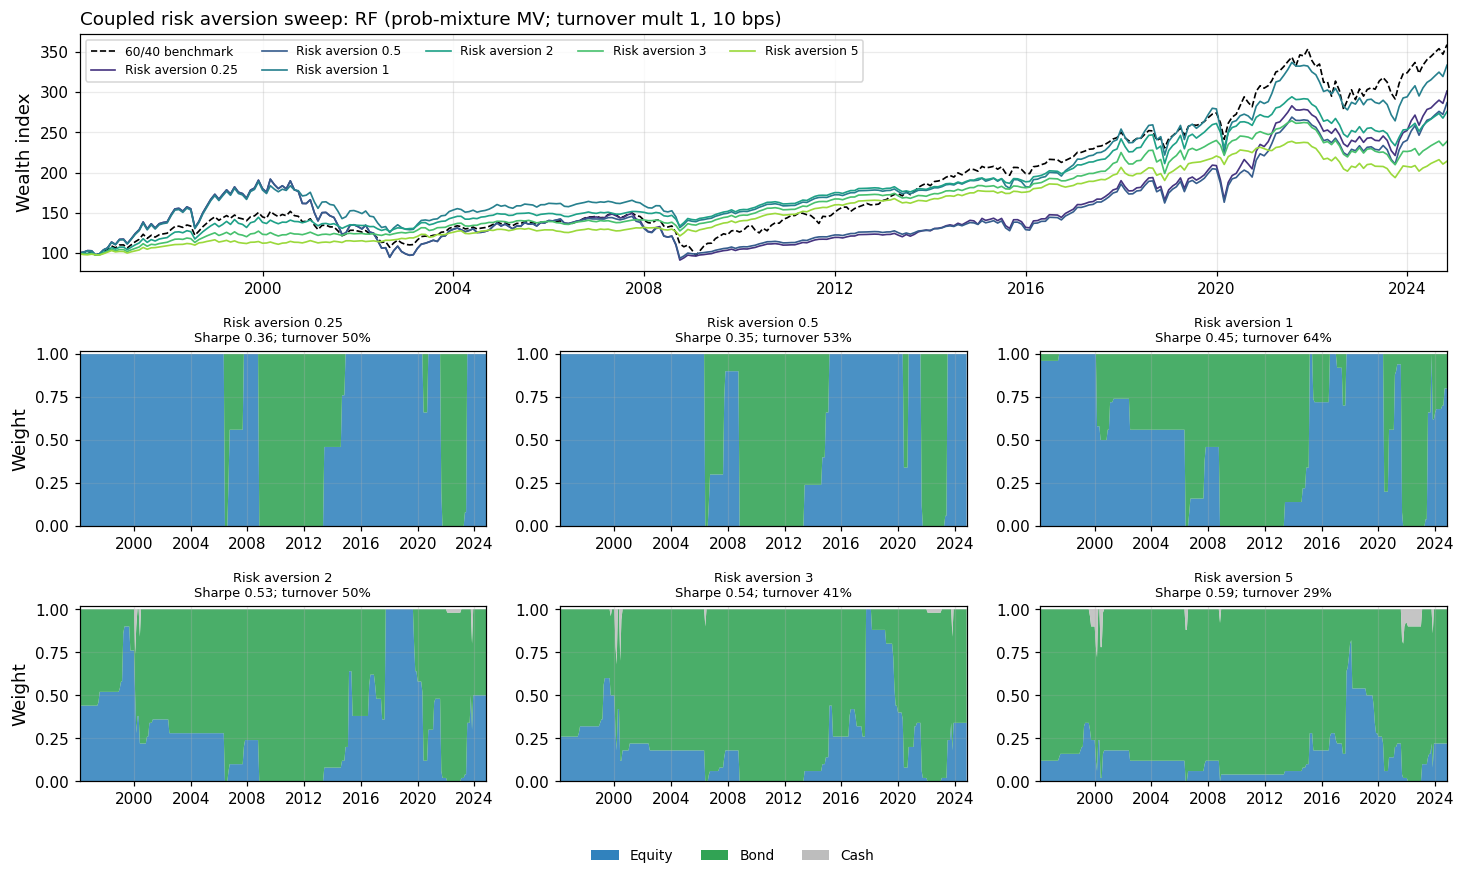

[saved] COUPLED__sweep_gamma_rf.csv / .tex


,Risk aversion,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.25,+4.7%,13.0%,0.362,-52.4%,-14.0%,301.3,49.9%
1,0.50,+4.5%,12.7%,0.353,-51.2%,-13.6%,286.8,53.0%
2,1.00,+4.7%,10.4%,0.454,-33.5%,-11.5%,333.4,63.6%
3,2.00,+3.8%,7.2%,0.527,-20.7%,-7.8%,275.7,49.8%
4,3.00,+3.2%,5.9%,0.541,-20.6%,-6.3%,238.7,40.8%
5,5.00,+2.8%,4.7%,0.590,-18.9%,-4.2%,214.1,29.2%


[saved] COUPLED__sweep_tp_logit.png / .pdf


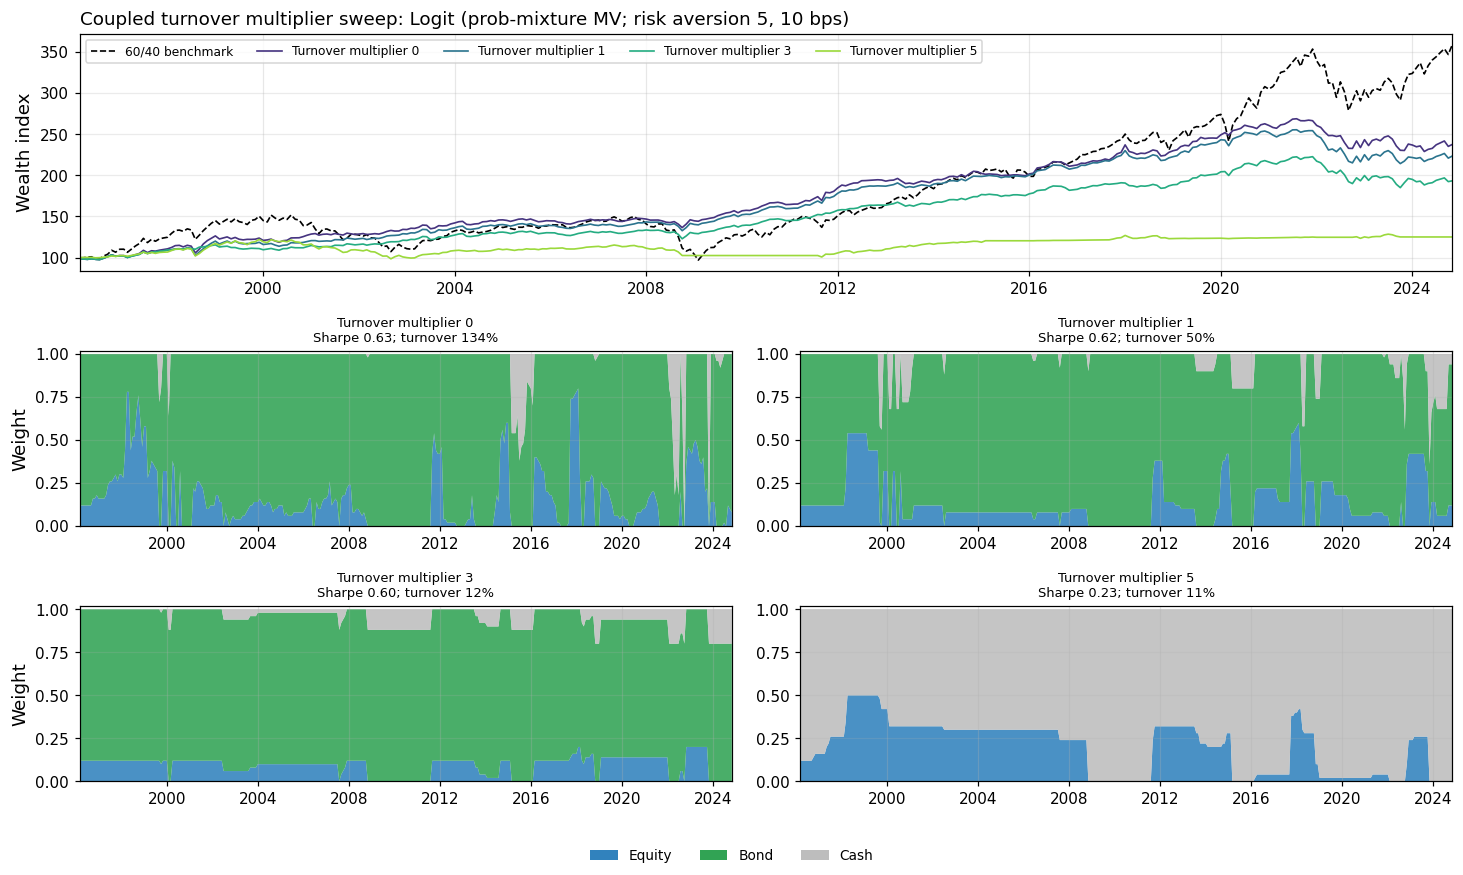

[saved] COUPLED__sweep_tp_logit.csv / .tex


,Turnover multiplier,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.0,+3.1%,5.0%,0.634,-14.8%,-4.4%,237.6,133.7%
1,1.0,+2.9%,4.7%,0.615,-16.1%,-4.7%,223.5,49.9%
2,3.0,+2.4%,4.0%,0.599,-16.9%,-3.7%,193.4,12.4%
3,5.0,+0.8%,3.8%,0.225,-19.3%,-4.5%,125.1,11.1%


[saved] COUPLED__sweep_tp_rf.png / .pdf


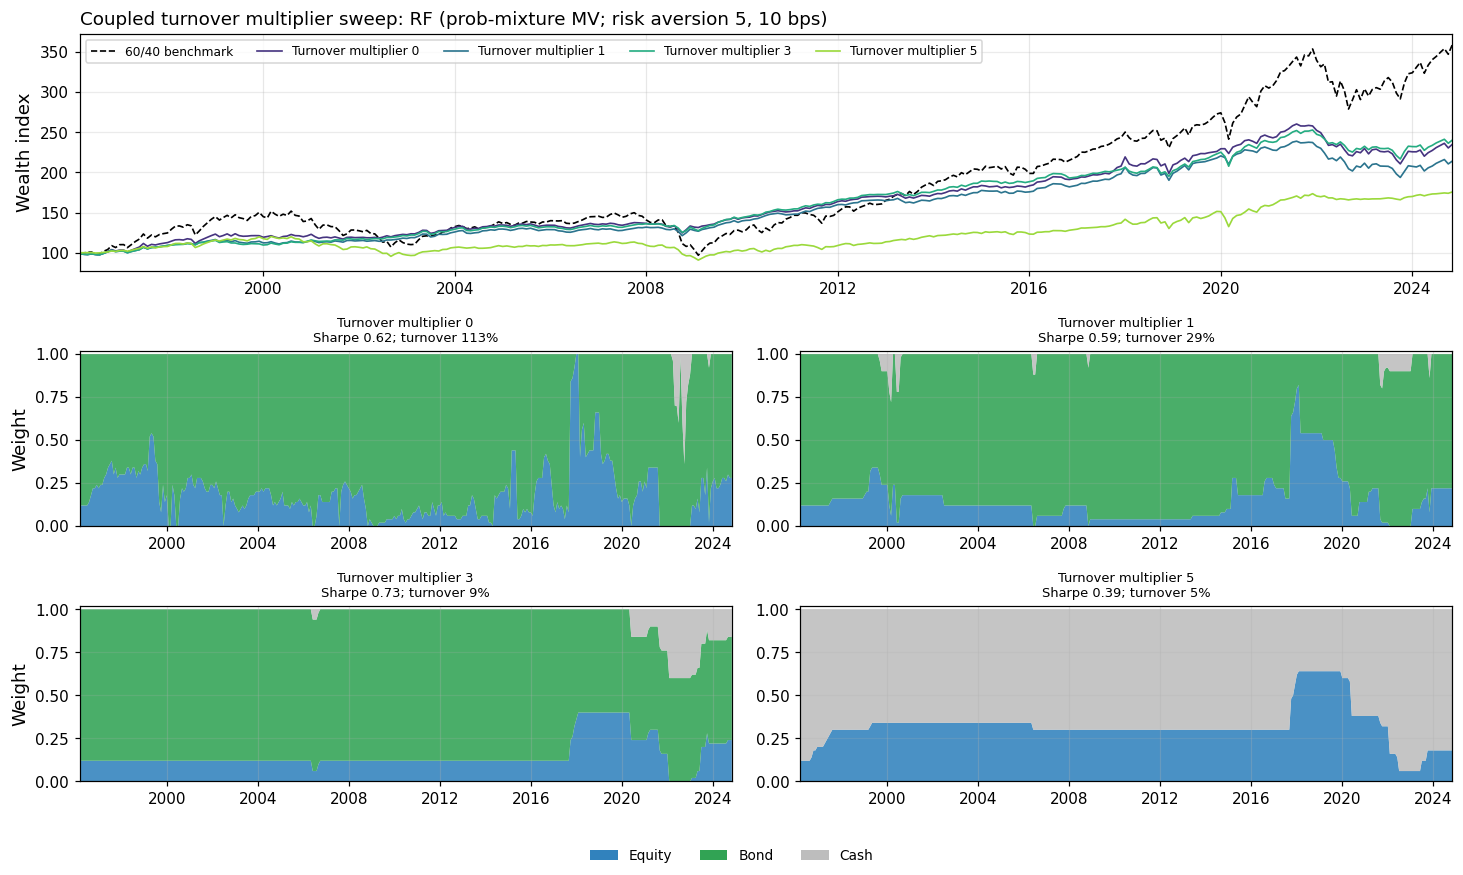

[saved] COUPLED__sweep_tp_rf.csv / .tex


,Turnover multiplier,Ann. return,Ann. vol.,Sharpe,Max. drawdown,Monthly CVaR 1%,Final wealth,Ann. turnover
0,0.0,+3.1%,5.0%,0.622,-19.1%,-4.5%,235.0,113.0%
1,1.0,+2.8%,4.7%,0.590,-18.9%,-4.2%,214.1,29.2%
2,3.0,+3.1%,4.3%,0.727,-14.3%,-4.0%,240.2,8.9%
3,5.0,+2.1%,5.4%,0.389,-24.4%,-5.9%,175.7,4.9%


CELL 28-37 OK.


In [40]:
# ============================================================================
# CELL 34-37 — FIGURE+TABLE: gamma & turnover sweeps, per modeL
# ============================================================================
def sweep_fig(model,vals,param,pname,fixed,tag):
    sd={}
    for v in vals:
        if param=="gamma": sd[v]=alloc_path(model,v,1.0,HEADLINE_COST,0)
        else:              sd[v]=alloc_path(model,TP_SWEEP_FIXED_GAMMA,v,HEADLINE_COST,0)
    n=len(vals); ncol=3 if n>4 else 2; nrow=int(np.ceil(n/ncol))
    fig=plt.figure(figsize=(13.5,3.2+2.4*nrow)); gs=fig.add_gridspec(nrow+1,ncol,height_ratios=[1.35]+[1.0]*nrow)
    axT=fig.add_subplot(gs[0,:])
    axT.plot(sims["60_40"].date,100*sims["60_40"].wealth,color="black",ls="--",lw=1.1,label="60/40 benchmark")
    cmap=plt.cm.viridis(np.linspace(0.15,0.85,n))
    for col,v in zip(cmap,vals): axT.plot(sd[v].date,100*sd[v].wealth,color=col,lw=1.1,label=f"{pname} {v:g}")
    axT.set_title(f"Coupled {pname.lower()} sweep: {model} (prob-mixture MV; {fixed})",loc="left",fontsize=12)
    axT.set_ylabel("Wealth index"); axT.grid(axis="y",alpha=0.25)
    axT.legend(loc="upper left",ncol=min(n+1,5),fontsize=8,frameon=True); axT.set_xlim(_SX0,_SX1)
    mrows=[]
    for k,v in enumerate(vals):
        ax=fig.add_subplot(gs[1+k//ncol,k%ncol]); d=sd[v]; m=metrics(d)
        ax.stackplot(d["date"],d["w_eq"].clip(0,1),d["w_bd"].clip(0,1),d["w_cash"].clip(0,1),
                     colors=[WC["eq"],WC["bd"],WC["cash"]],alpha=0.88,linewidth=0)
        ax.set_ylim(0,1.02); ax.set_xlim(_SX0,_SX1)
        ax.set_title(f"{pname} {v:g}\nSharpe {m['sharpe']:.2f}; turnover {m['turnover']:.0%}",fontsize=8.5)
        ax.grid(axis="y",alpha=0.20)
        if k%ncol==0: ax.set_ylabel("Weight")
        mrows.append({pname:v,"Ann. return":f"{m['ann_excess']:+.1%}","Ann. vol.":f"{m['vol']:.1%}","Sharpe":round(m['sharpe'],3),
            "Max. drawdown":f"{m['max_dd']:.1%}","Monthly CVaR 1%":f"{m['cvar1']:.1%}","Final wealth":round(m['final'],1),"Ann. turnover":f"{m['turnover']:.1%}"})
    for k in range(n,nrow*ncol): fig.add_subplot(gs[1+k//ncol,k%ncol]).axis("off")
    handles=[Patch(facecolor=WC["eq"],label="Equity"),Patch(facecolor=WC["bd"],label="Bond"),Patch(facecolor=WC["cash"],label="Cash")]
    fig.legend(handles=handles,loc="lower center",ncol=3,frameon=False,fontsize=9)
    fig.tight_layout(rect=[0,0.05,1,1])
    save_fig(fig,tag); save_tbl(pd.DataFrame(mrows),tag)
sweep_fig("Logit",GAMMA_SWEEP,"gamma","Risk aversion","turnover mult 1, 10 bps","sweep_gamma_logit")
sweep_fig("RF",   GAMMA_SWEEP,"gamma","Risk aversion","turnover mult 1, 10 bps","sweep_gamma_rf")
sweep_fig("Logit",TAU_GRID,   "tau","Turnover multiplier","risk aversion 5, 10 bps","sweep_tp_logit")
sweep_fig("RF",   TAU_GRID,   "tau","Turnover multiplier","risk aversion 5, 10 bps","sweep_tp_rf")
print("CELL 28-37 OK.")